In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import pandas as pd
import seaborn as sns
sns.set_context('talk')
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde, norm
import tqdm
import textwrap
import warnings
warnings.filterwarnings('ignore')

import time_normalization_helpers

# How does activity distribution change over time?

In [10]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/trebl_experiment_activities_per_barcode.csv", index_col = 0)
activities

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [11]:
activities_rep2 = activities[activities["rep"] == 2]
activities_rep3 = activities[activities["rep"] == 3]
activities_rep4 = activities[activities["rep"] == 4]

100%|██████████| 10/10 [00:00<00:00, 18.00it/s]


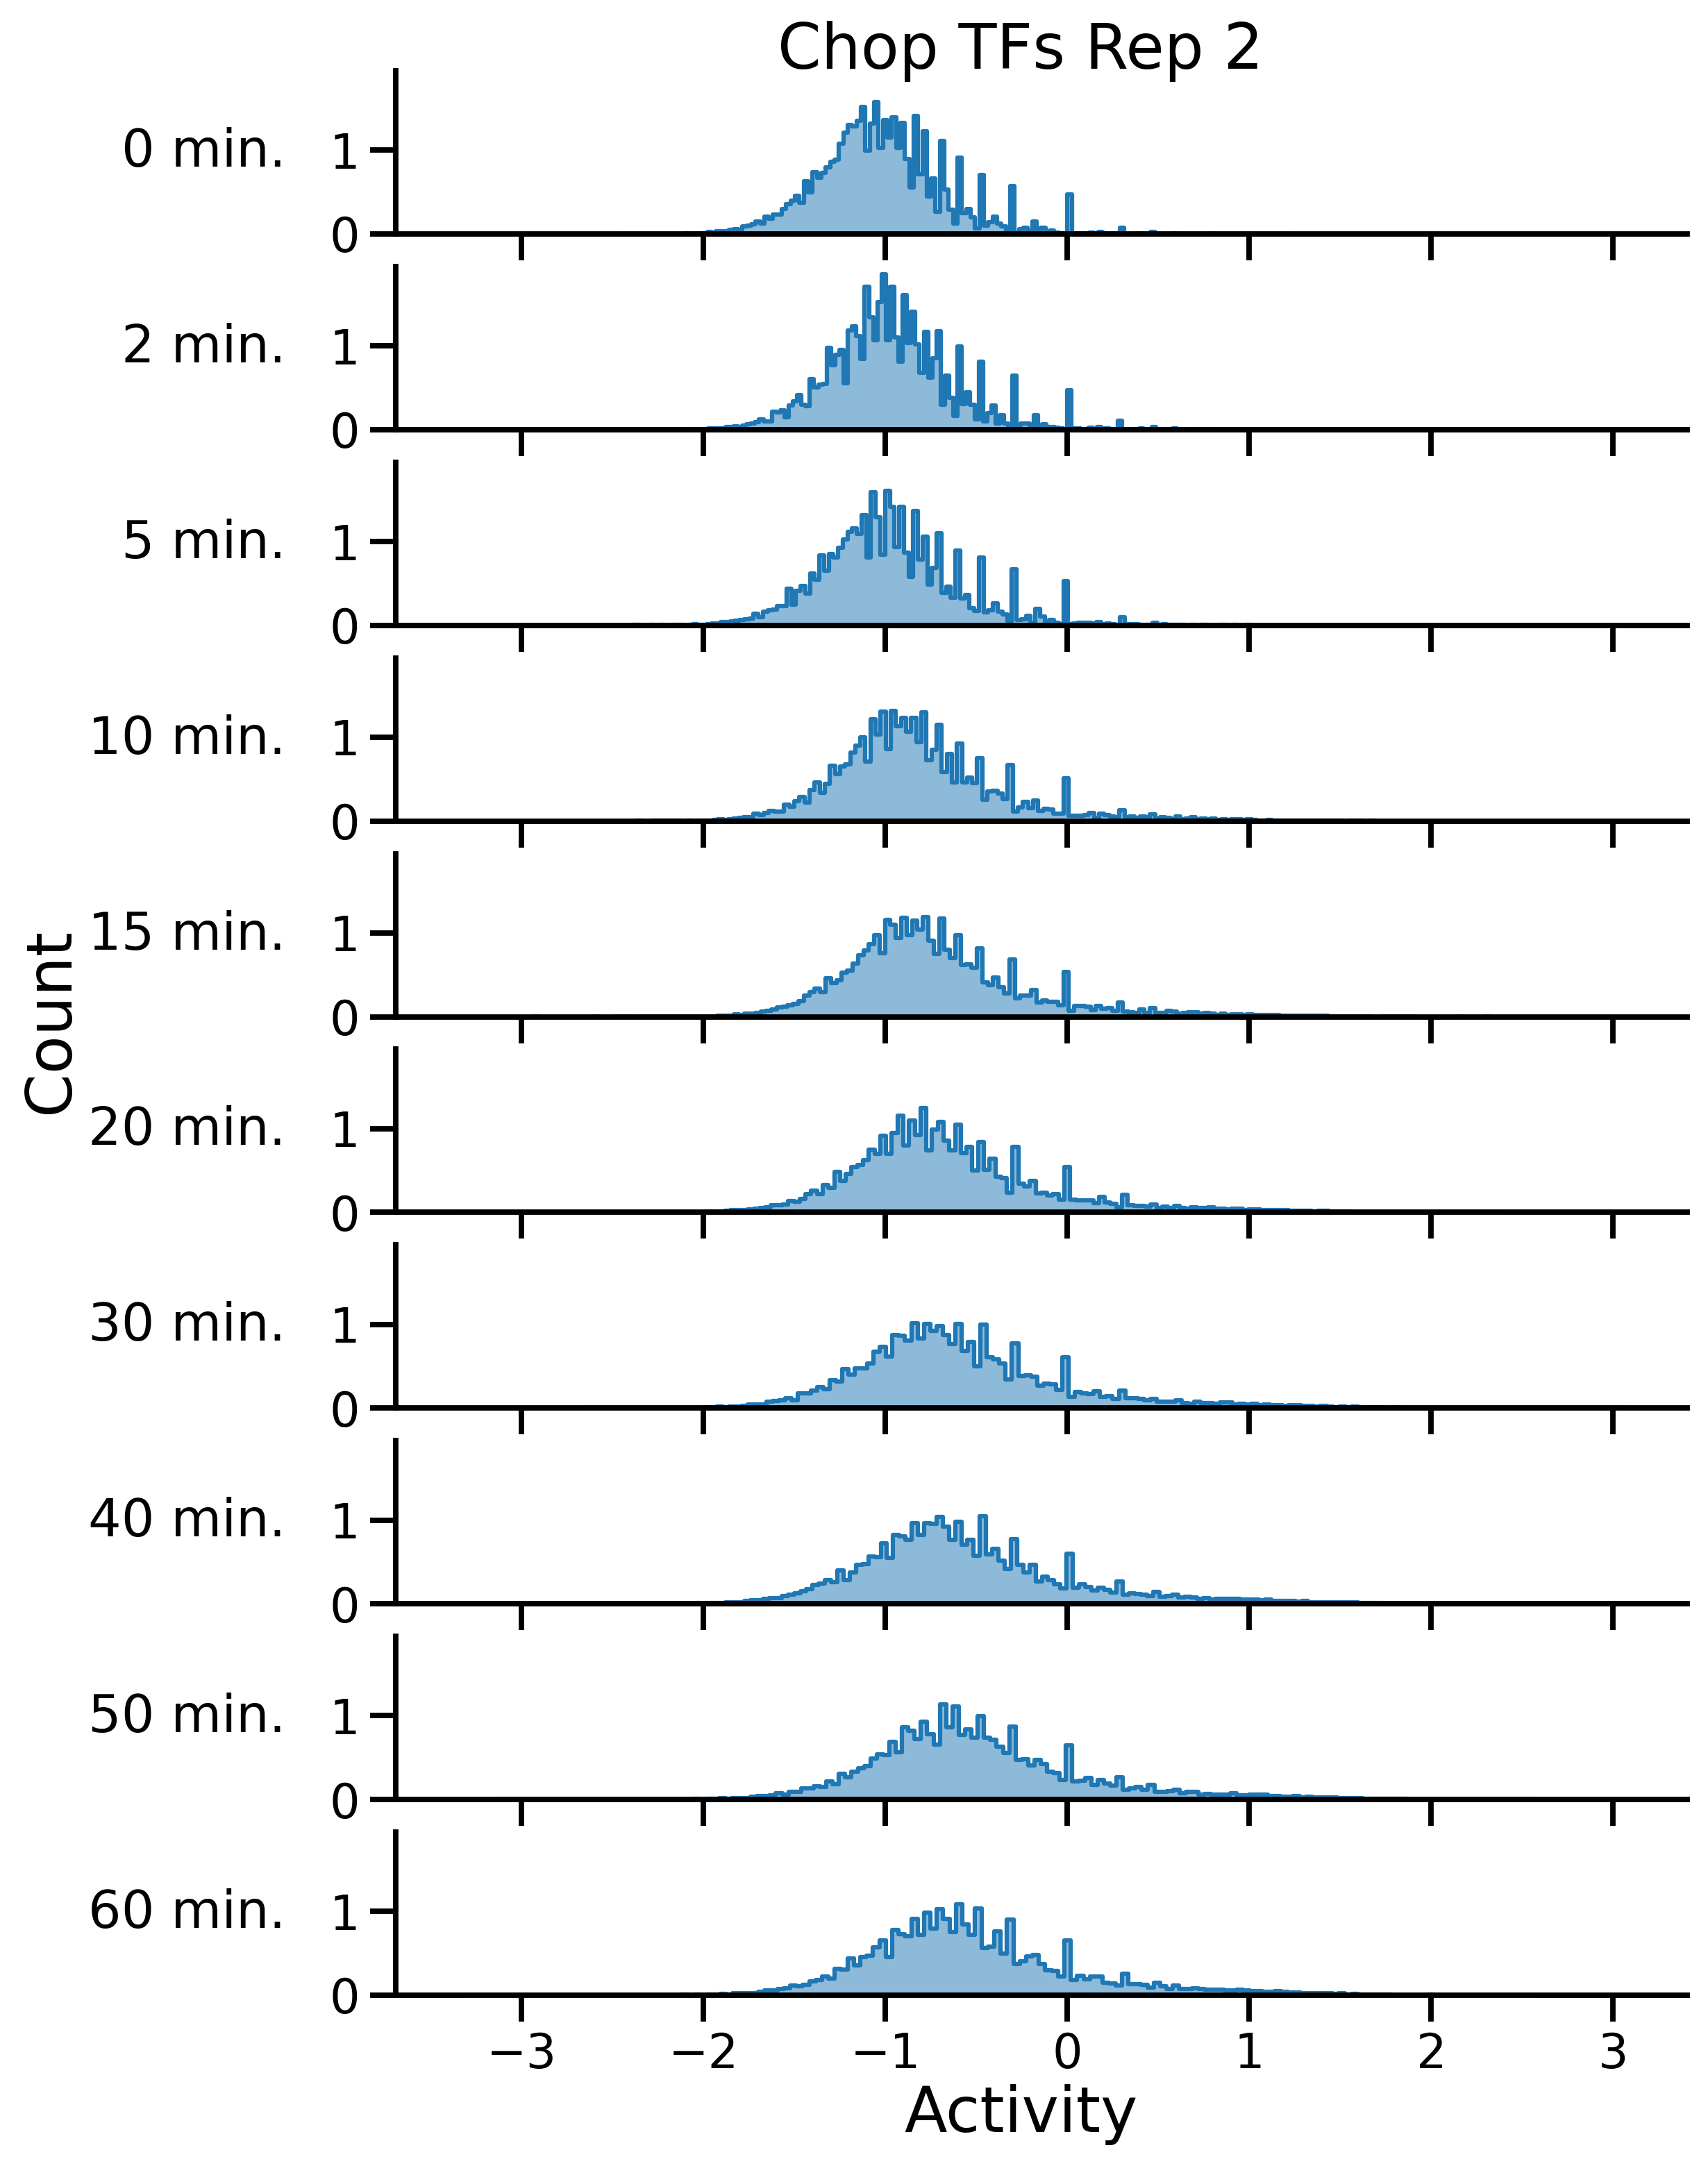

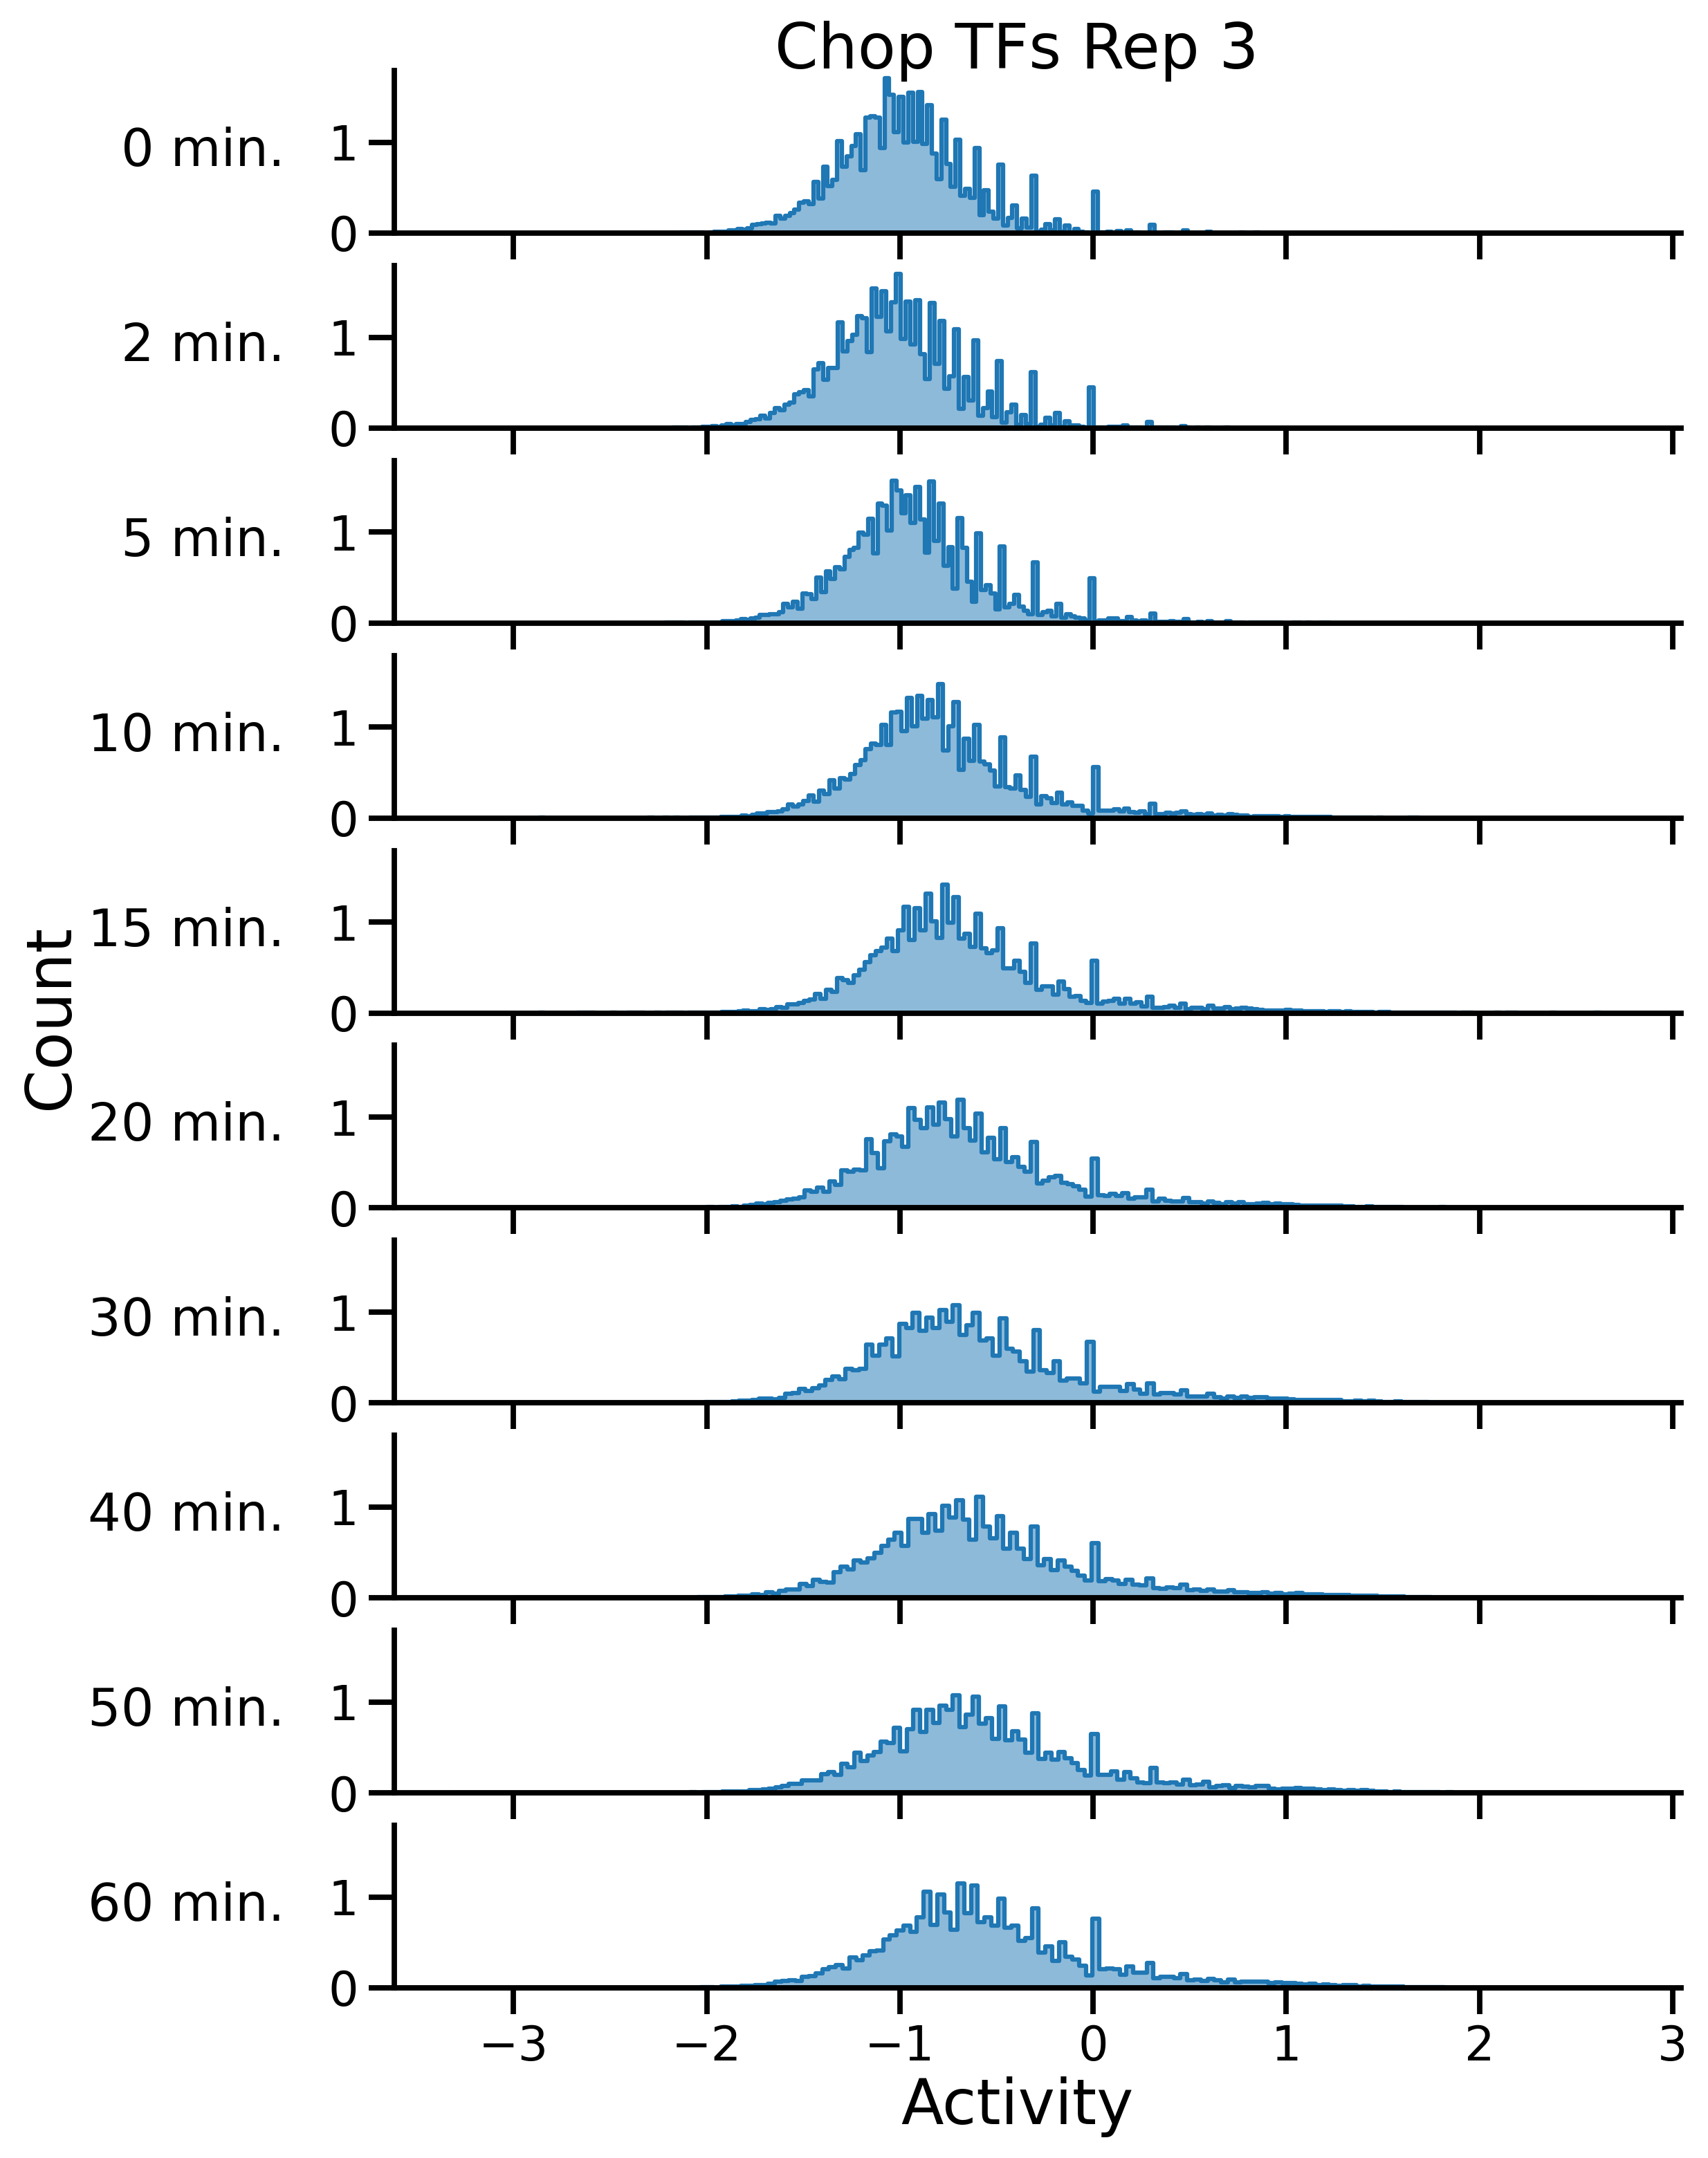

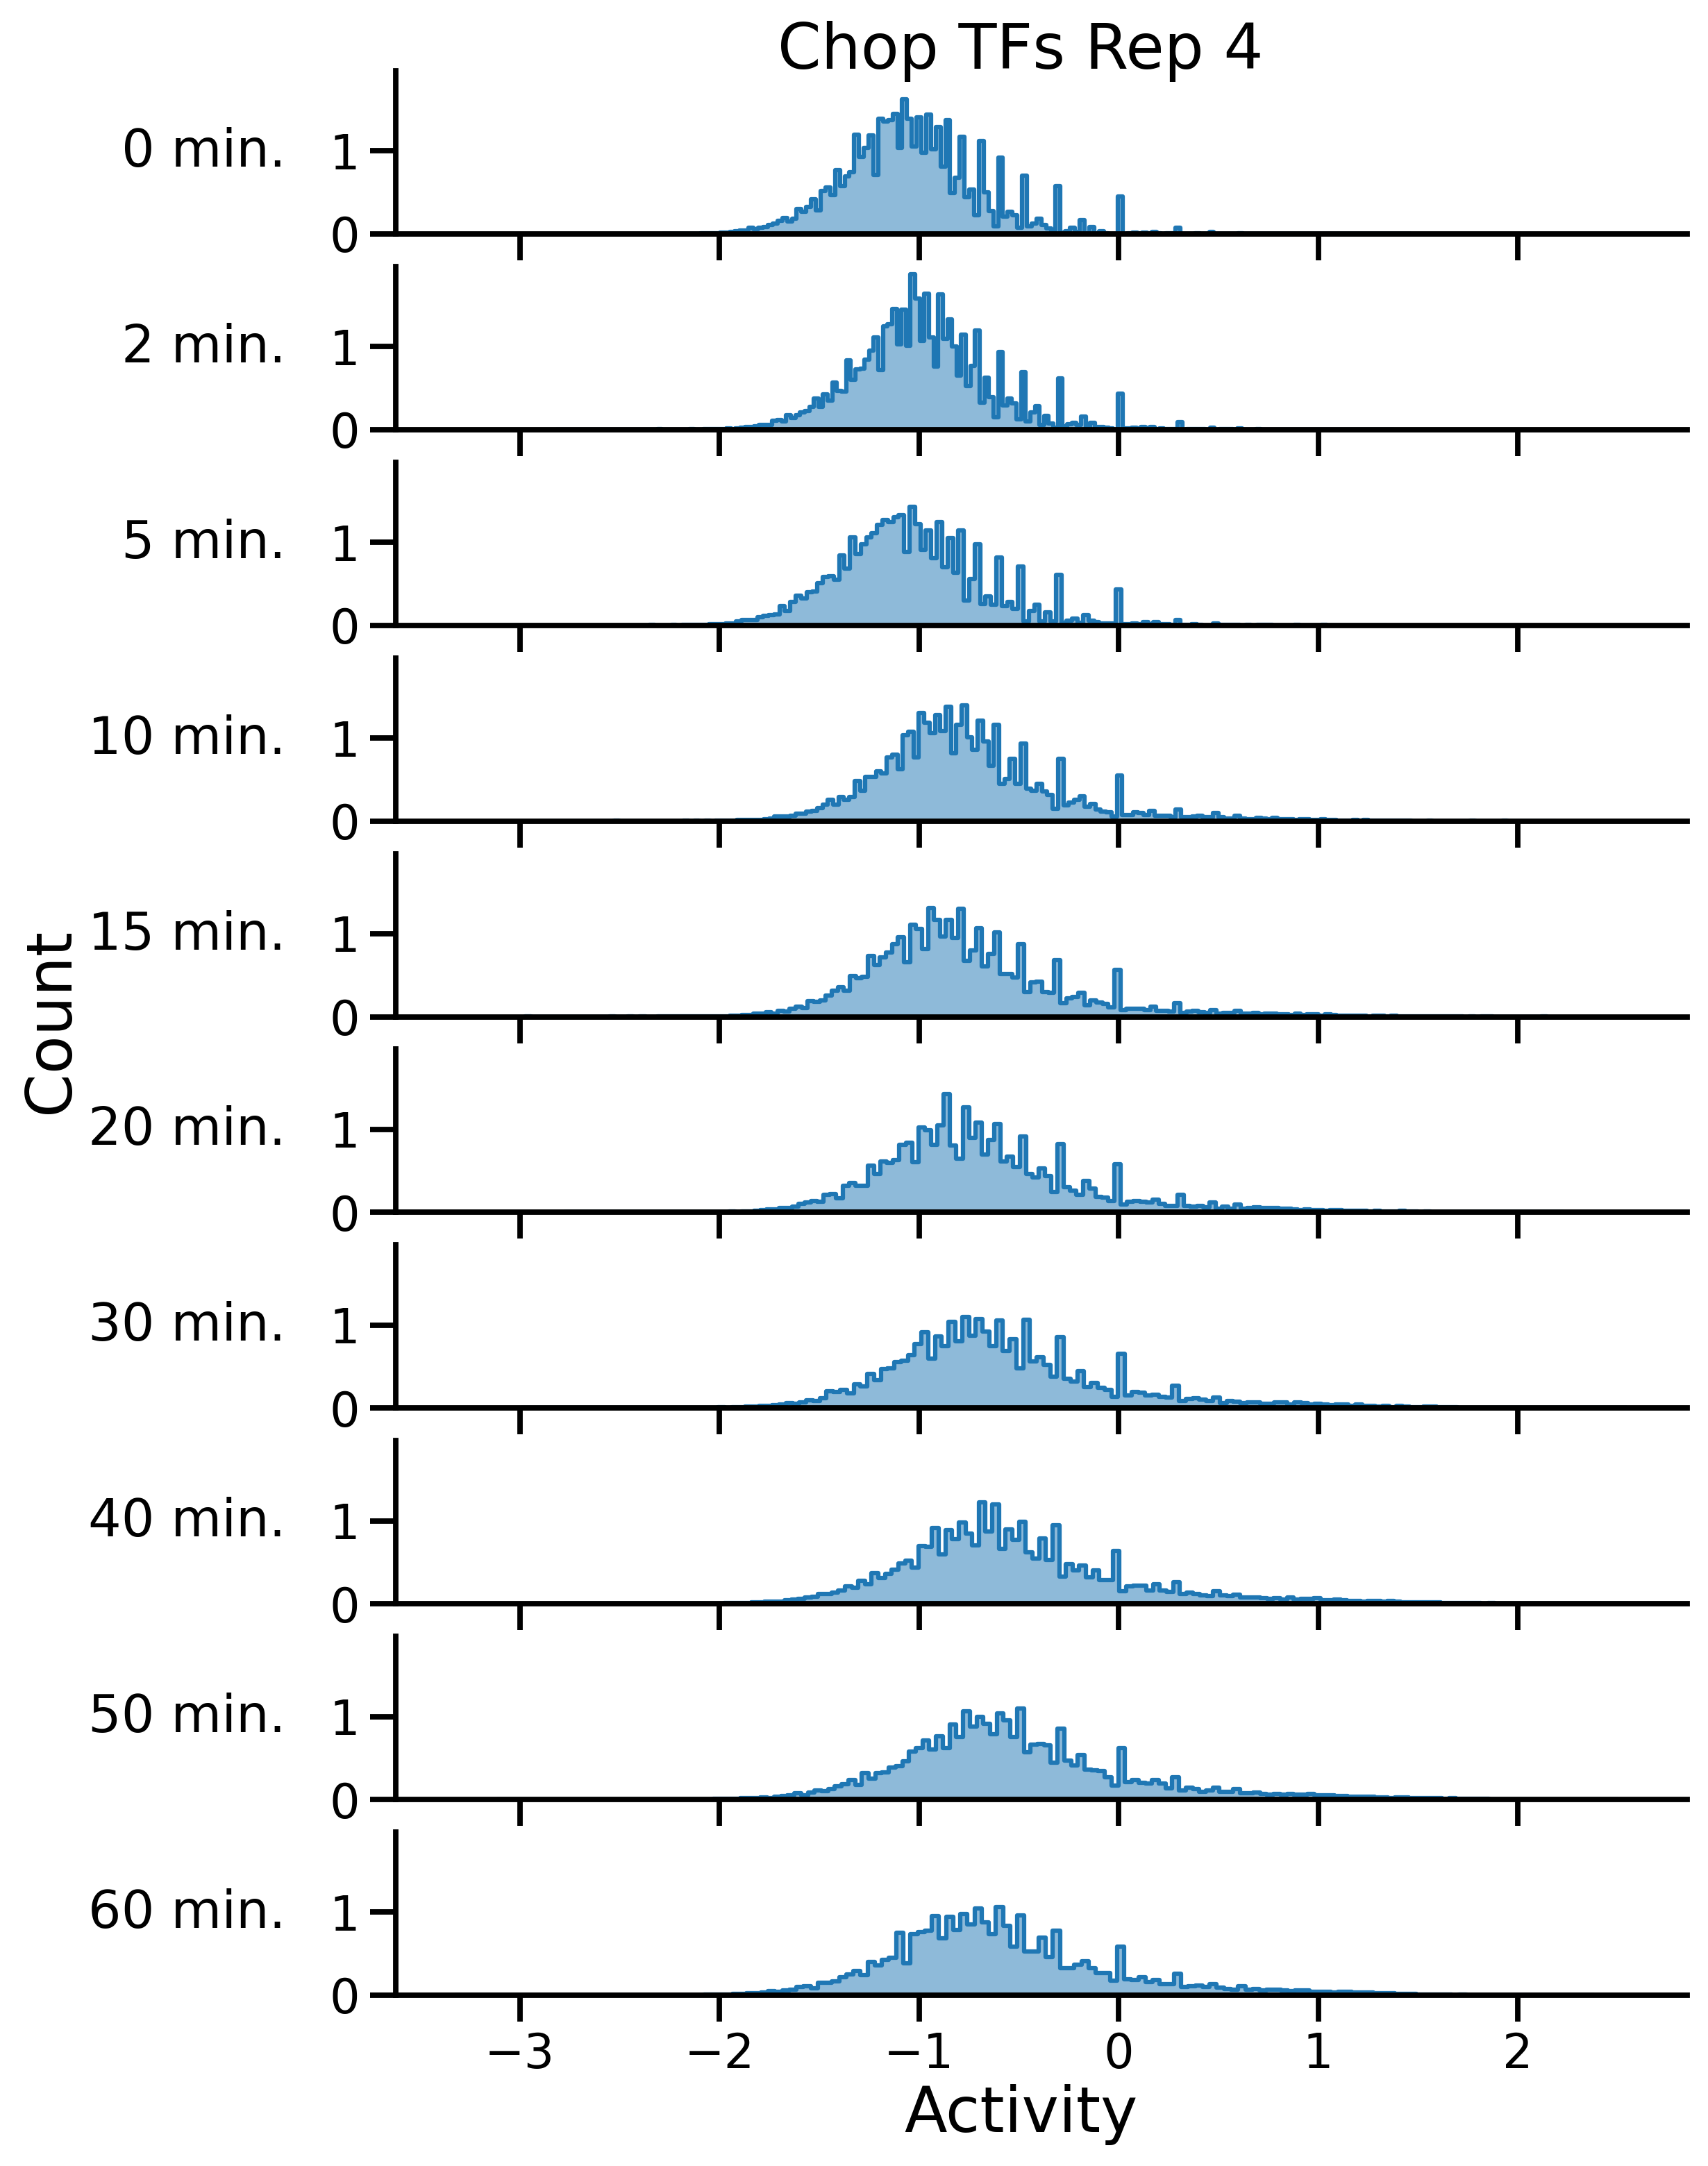

In [12]:
for rep in [2,3,4]:
    fig,axs = time_normalization_helpers.plot_hists_over_time(activities[activities["rep"] == rep])
    fig.suptitle(f"Chop TFs Rep {rep}", y = 0.9)
    if rep == 2:
        plt.savefig("../../../output/lab_meeting_figs_032426/full_data_distribution_no_norm.png", bbox_inches = 'tight')

100%|██████████| 10/10 [00:00<00:00, 32.06it/s]


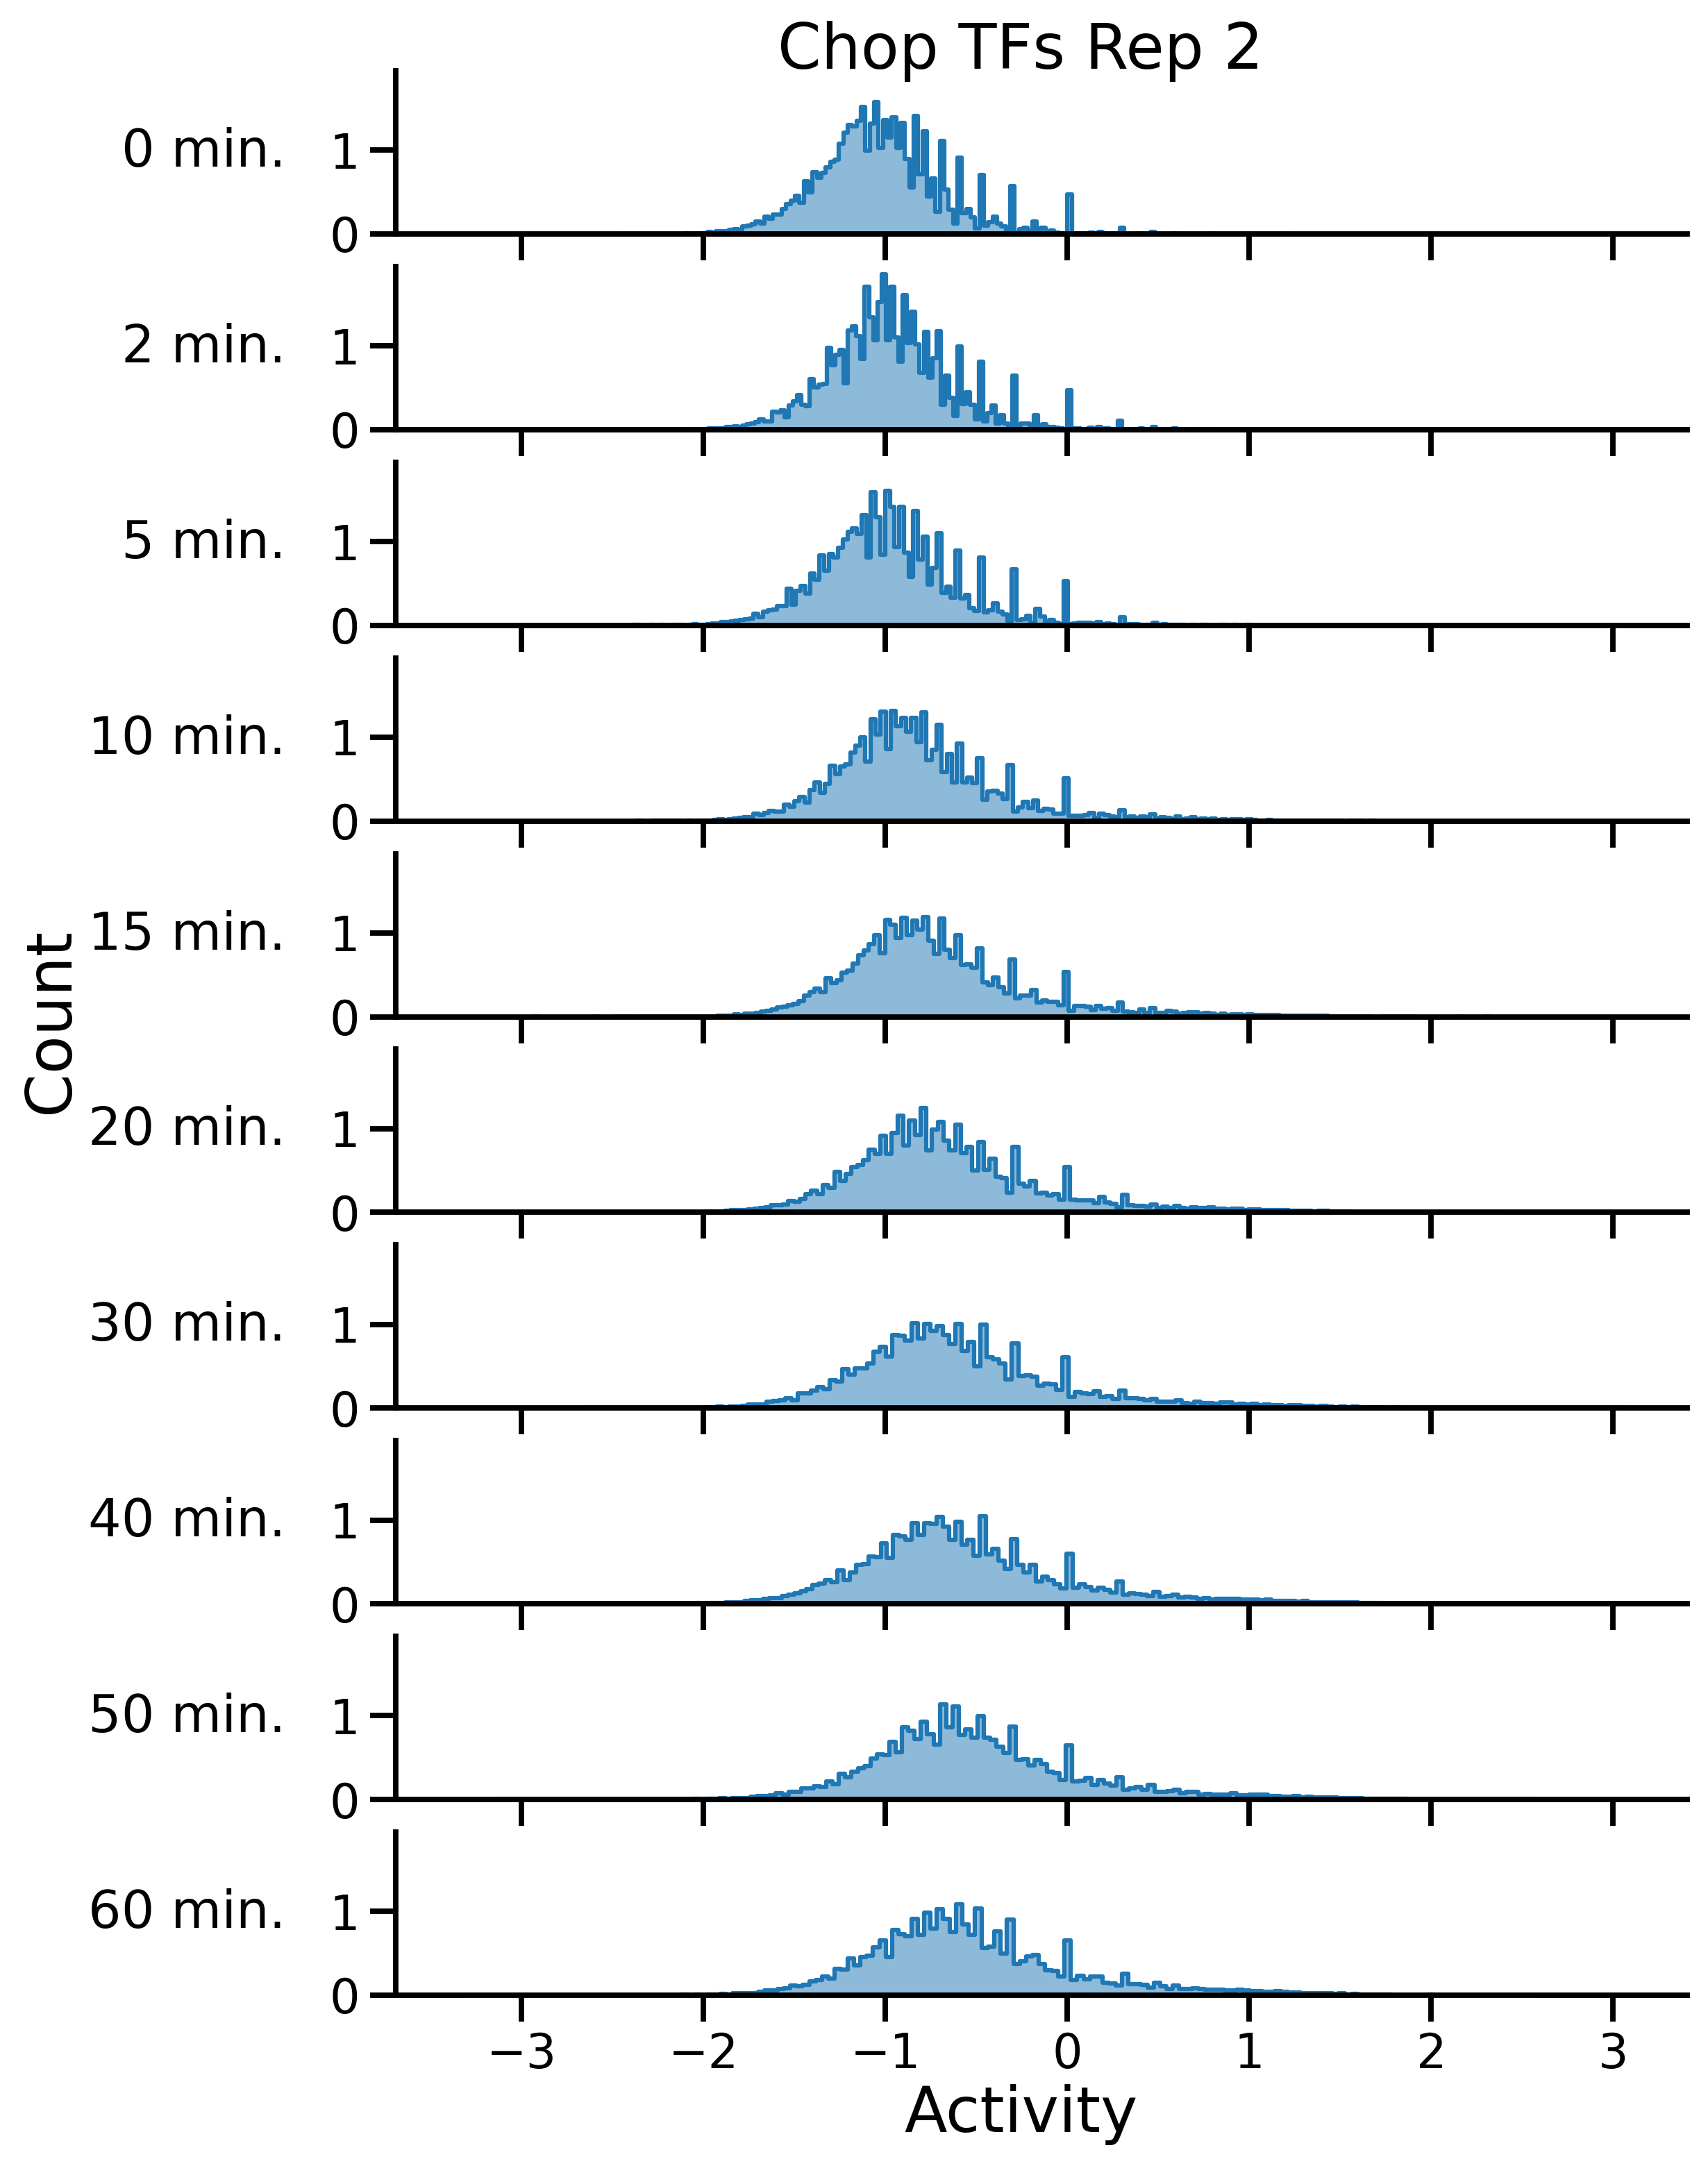

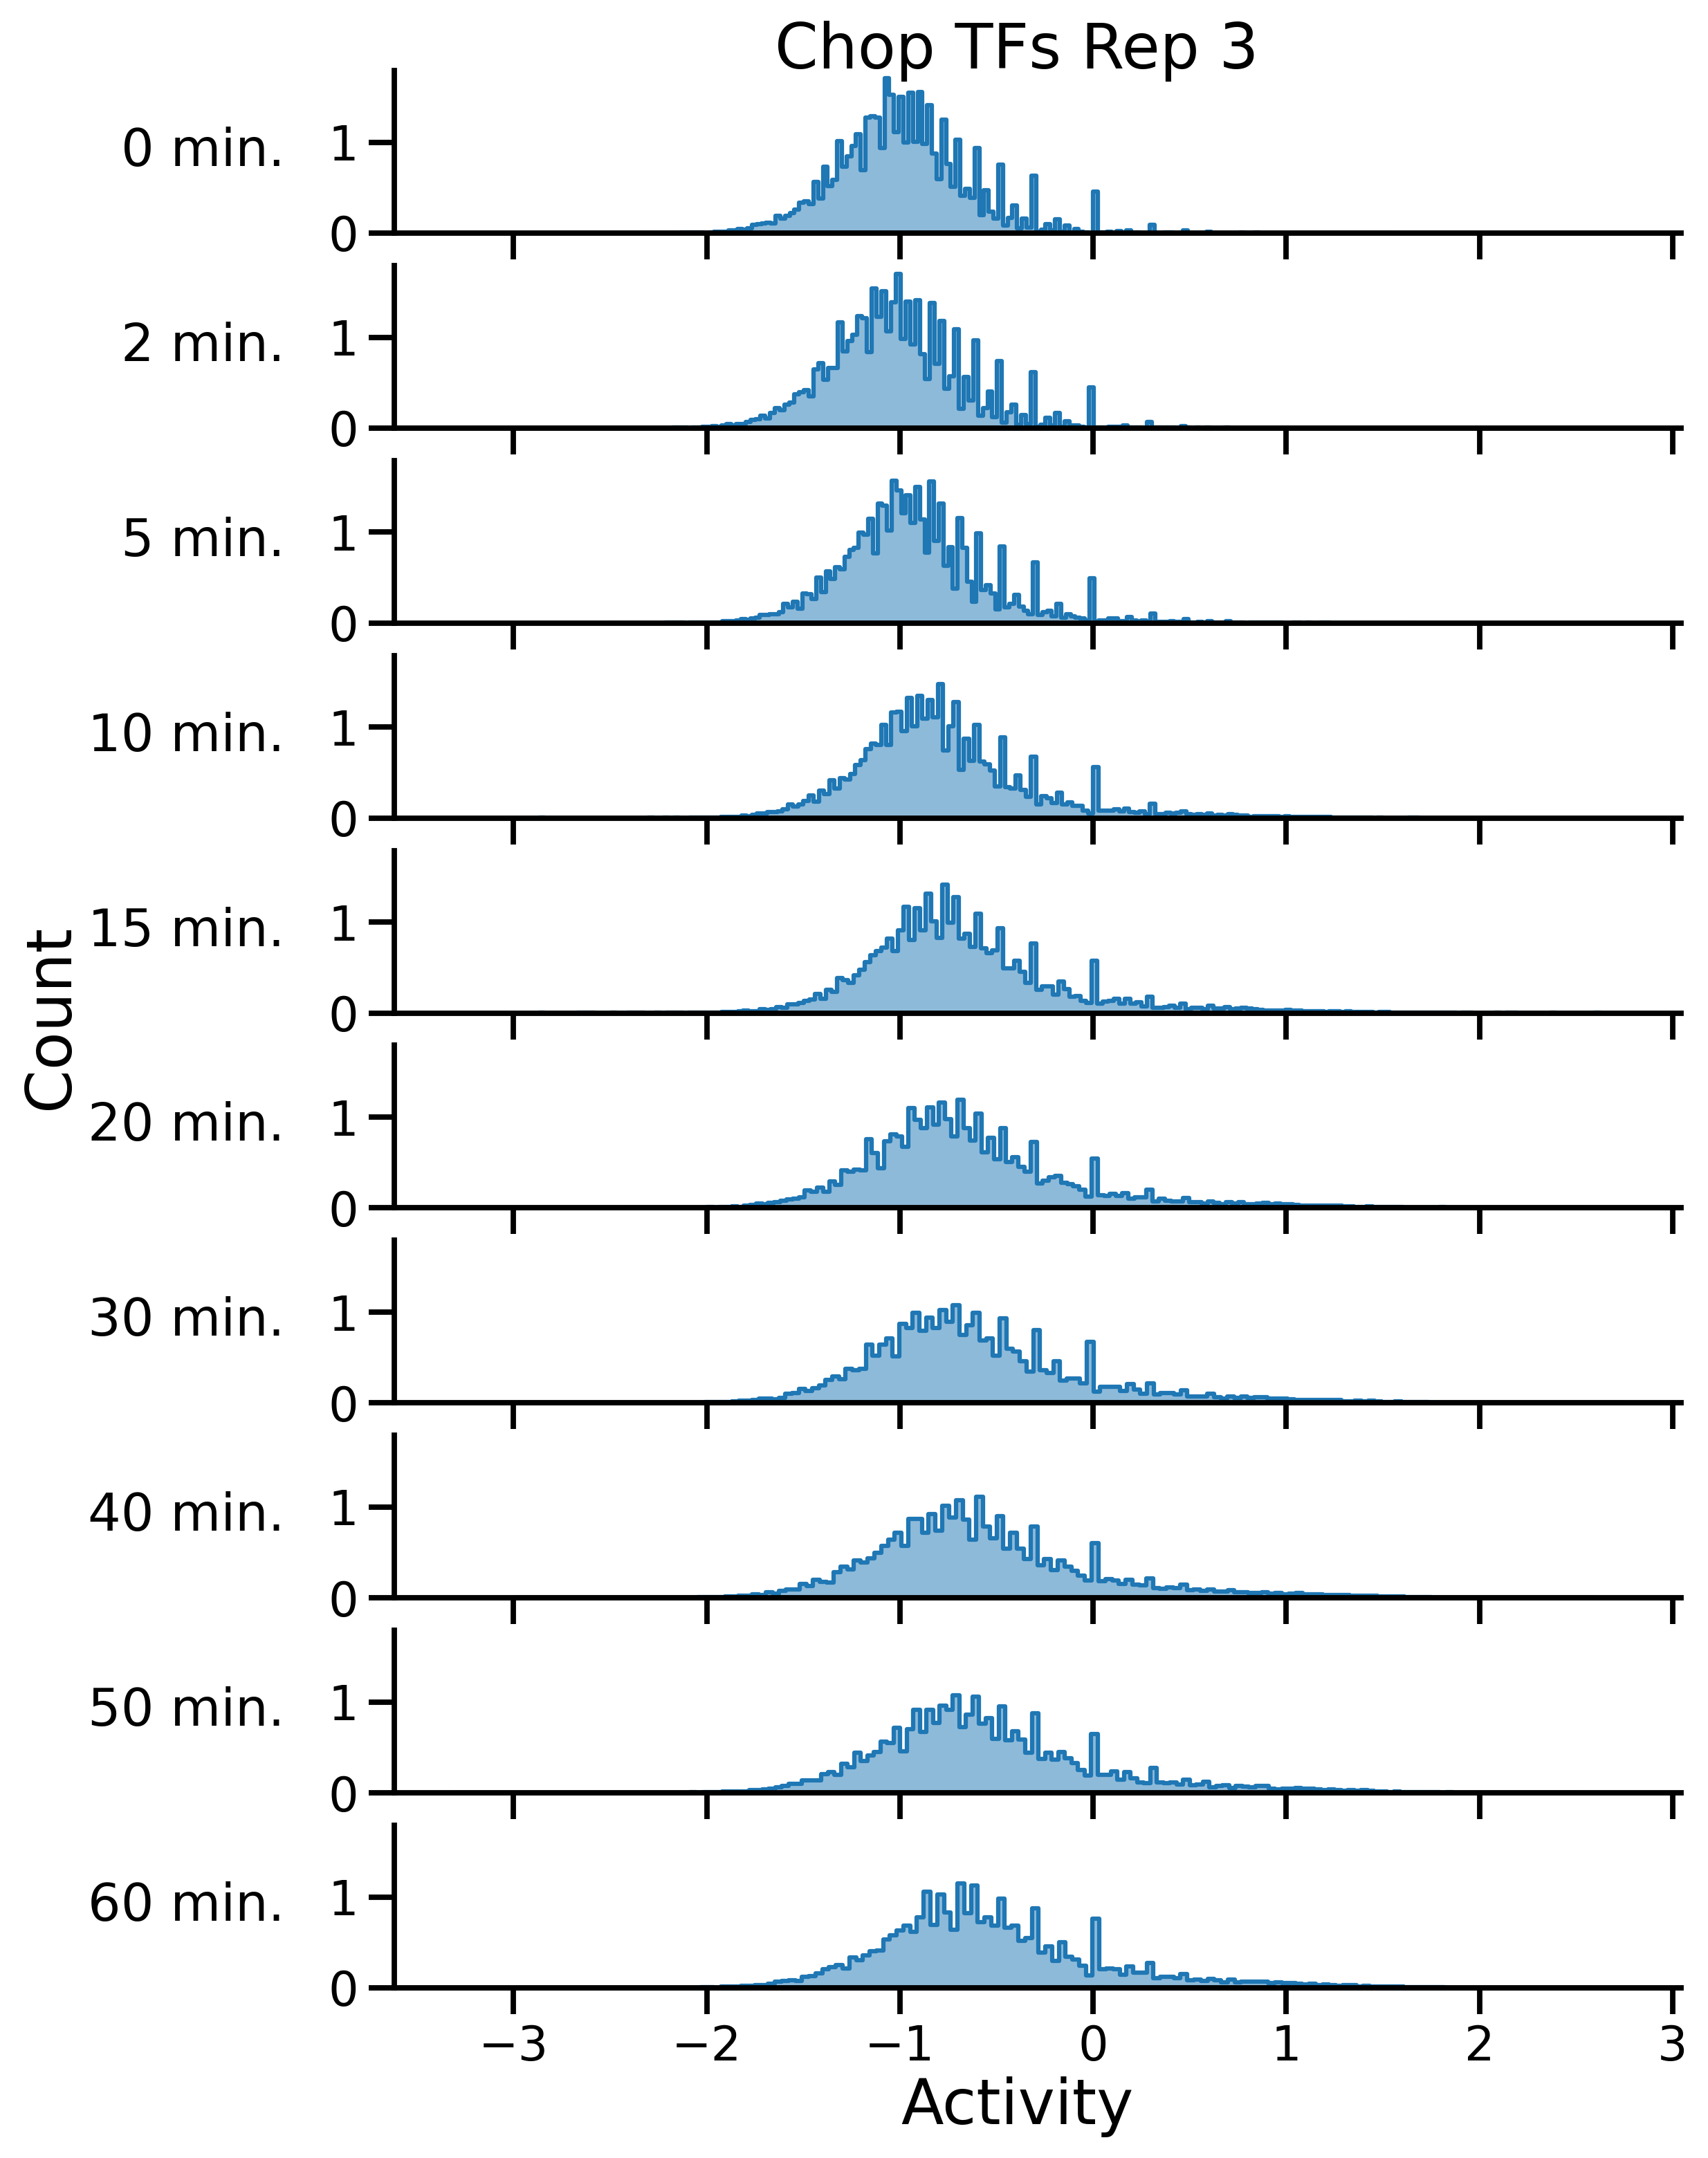

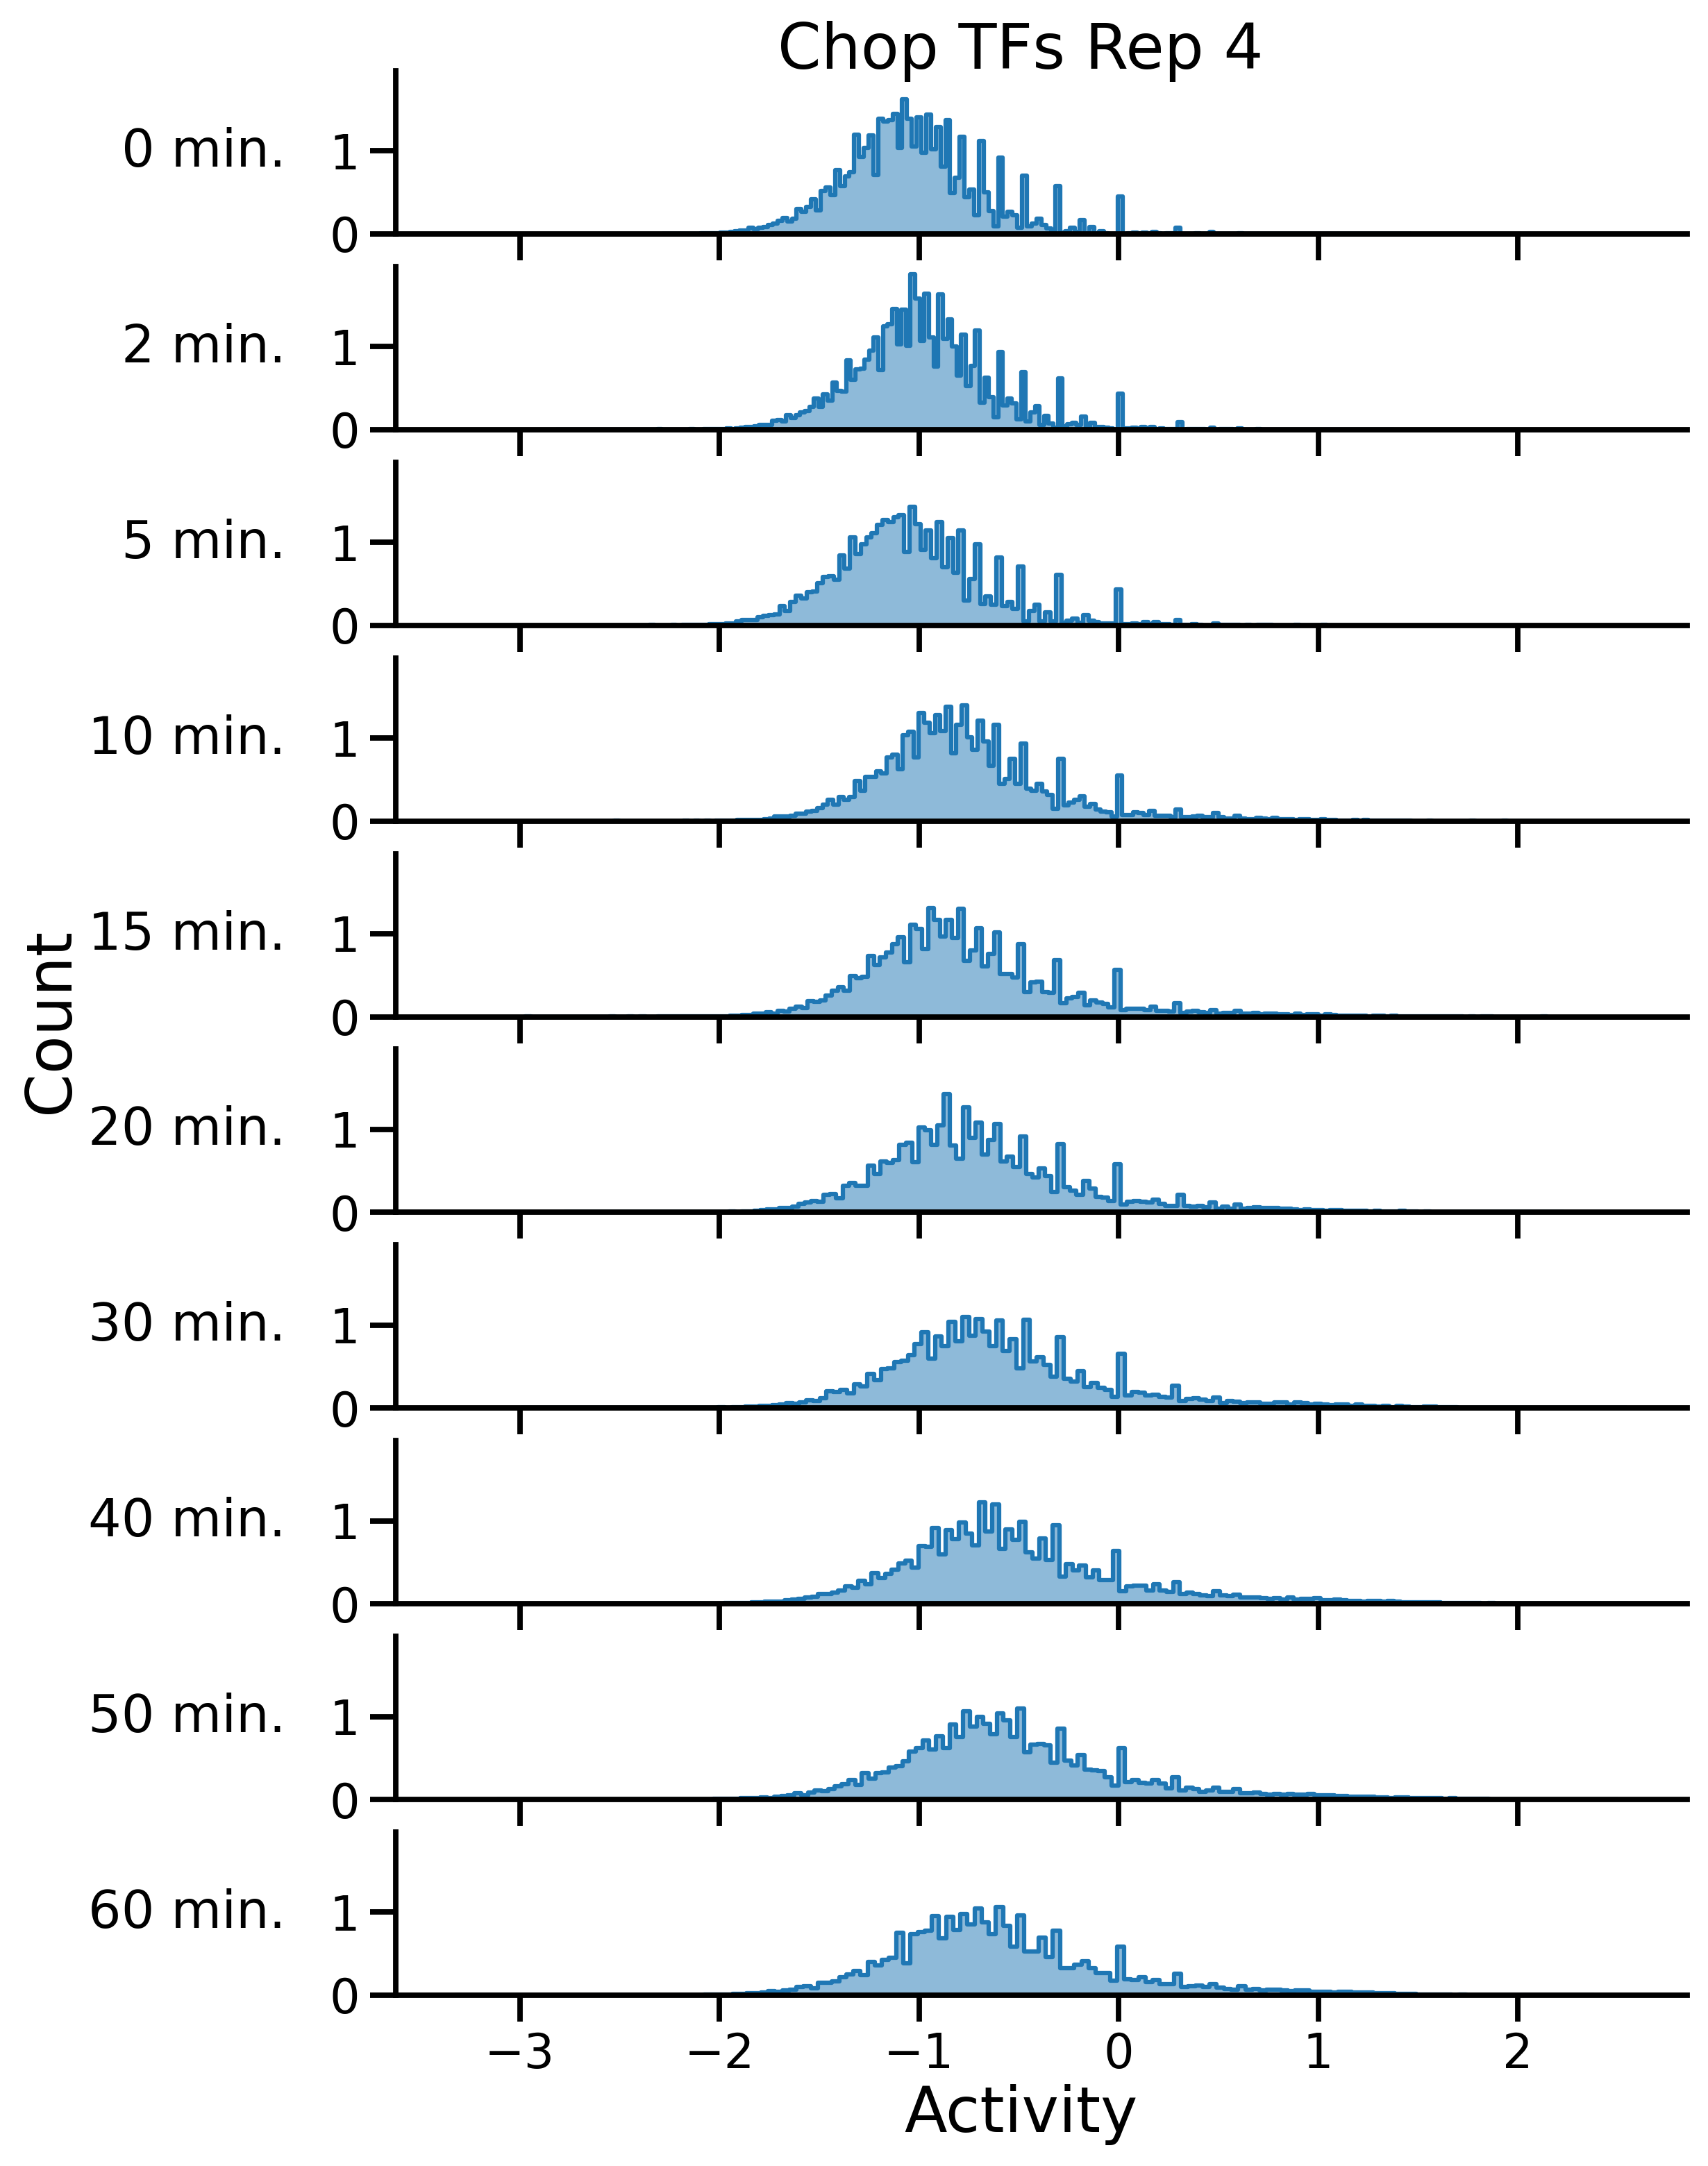

In [13]:
for rep in [2,3,4]:
    fig,axs = time_normalization_helpers.plot_hists_over_time(activities[activities["rep"] == rep], xlims = (0,100))
    fig.suptitle(f"Chop TFs Rep {rep}", y = 0.9)
    if rep == 2:
        plt.savefig("../../../output/lab_meeting_figs_032426/full_data_distribution_no_norm_no_xlims.png", bbox_inches = 'tight')

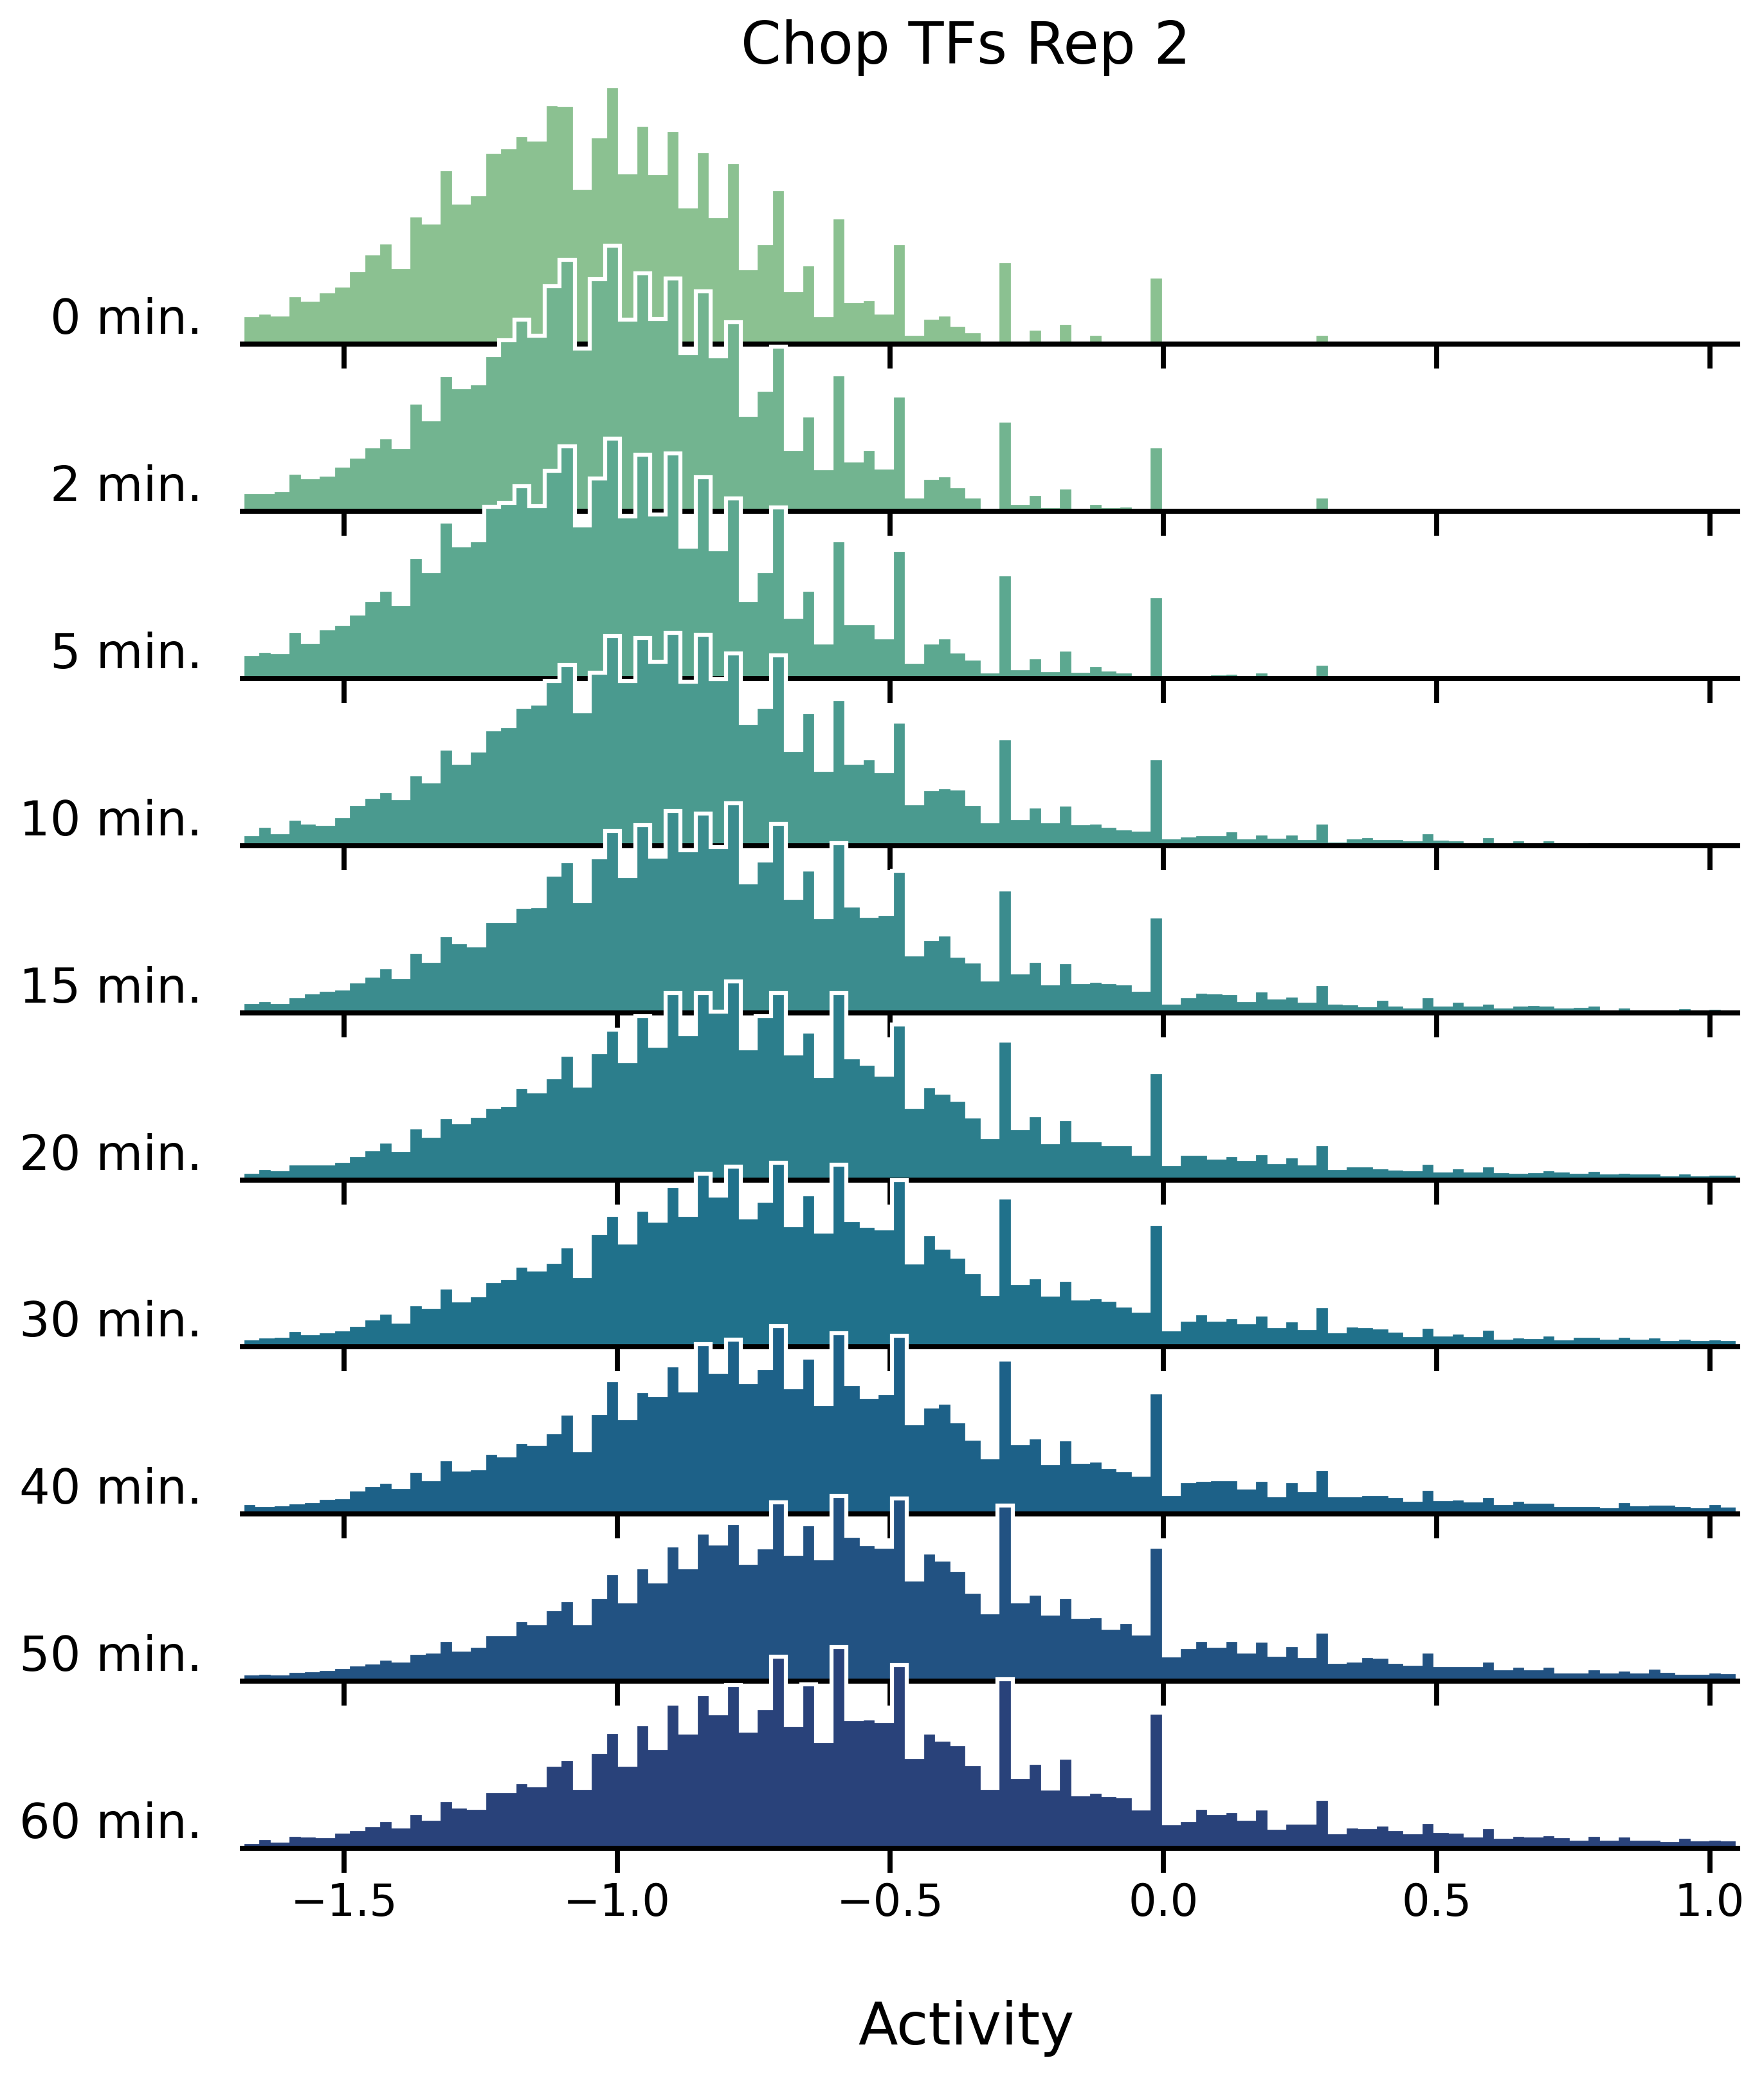

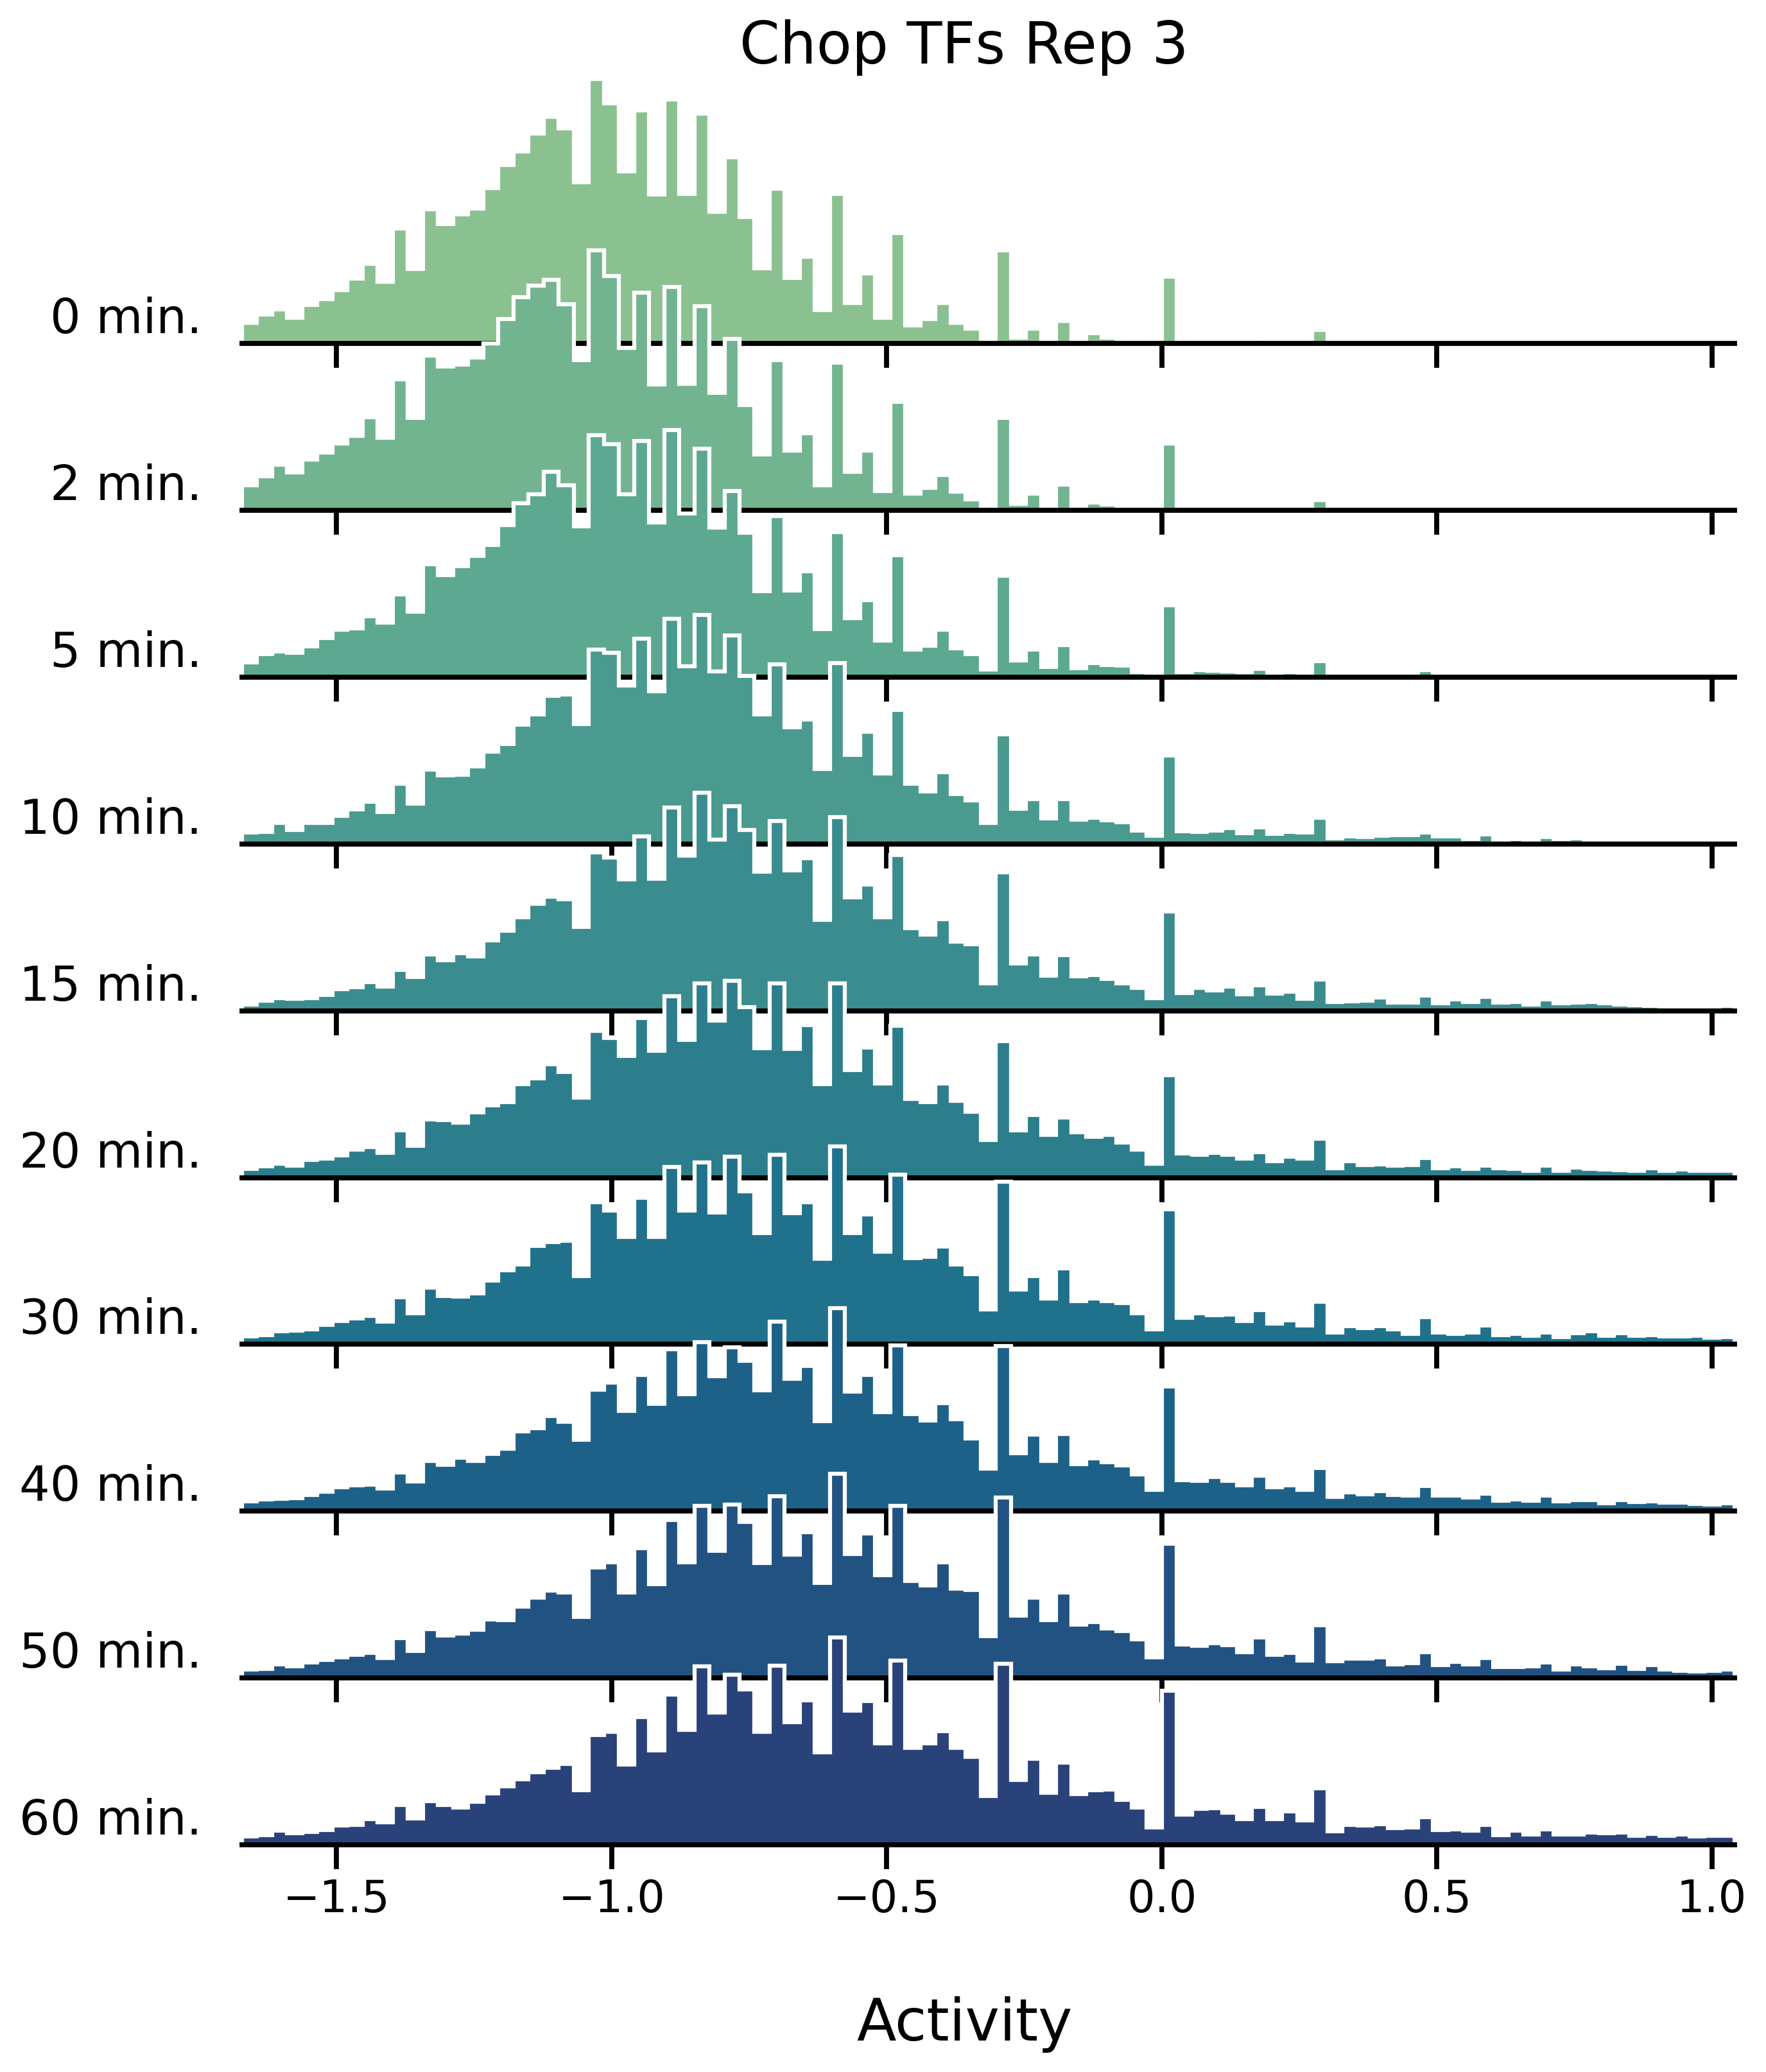

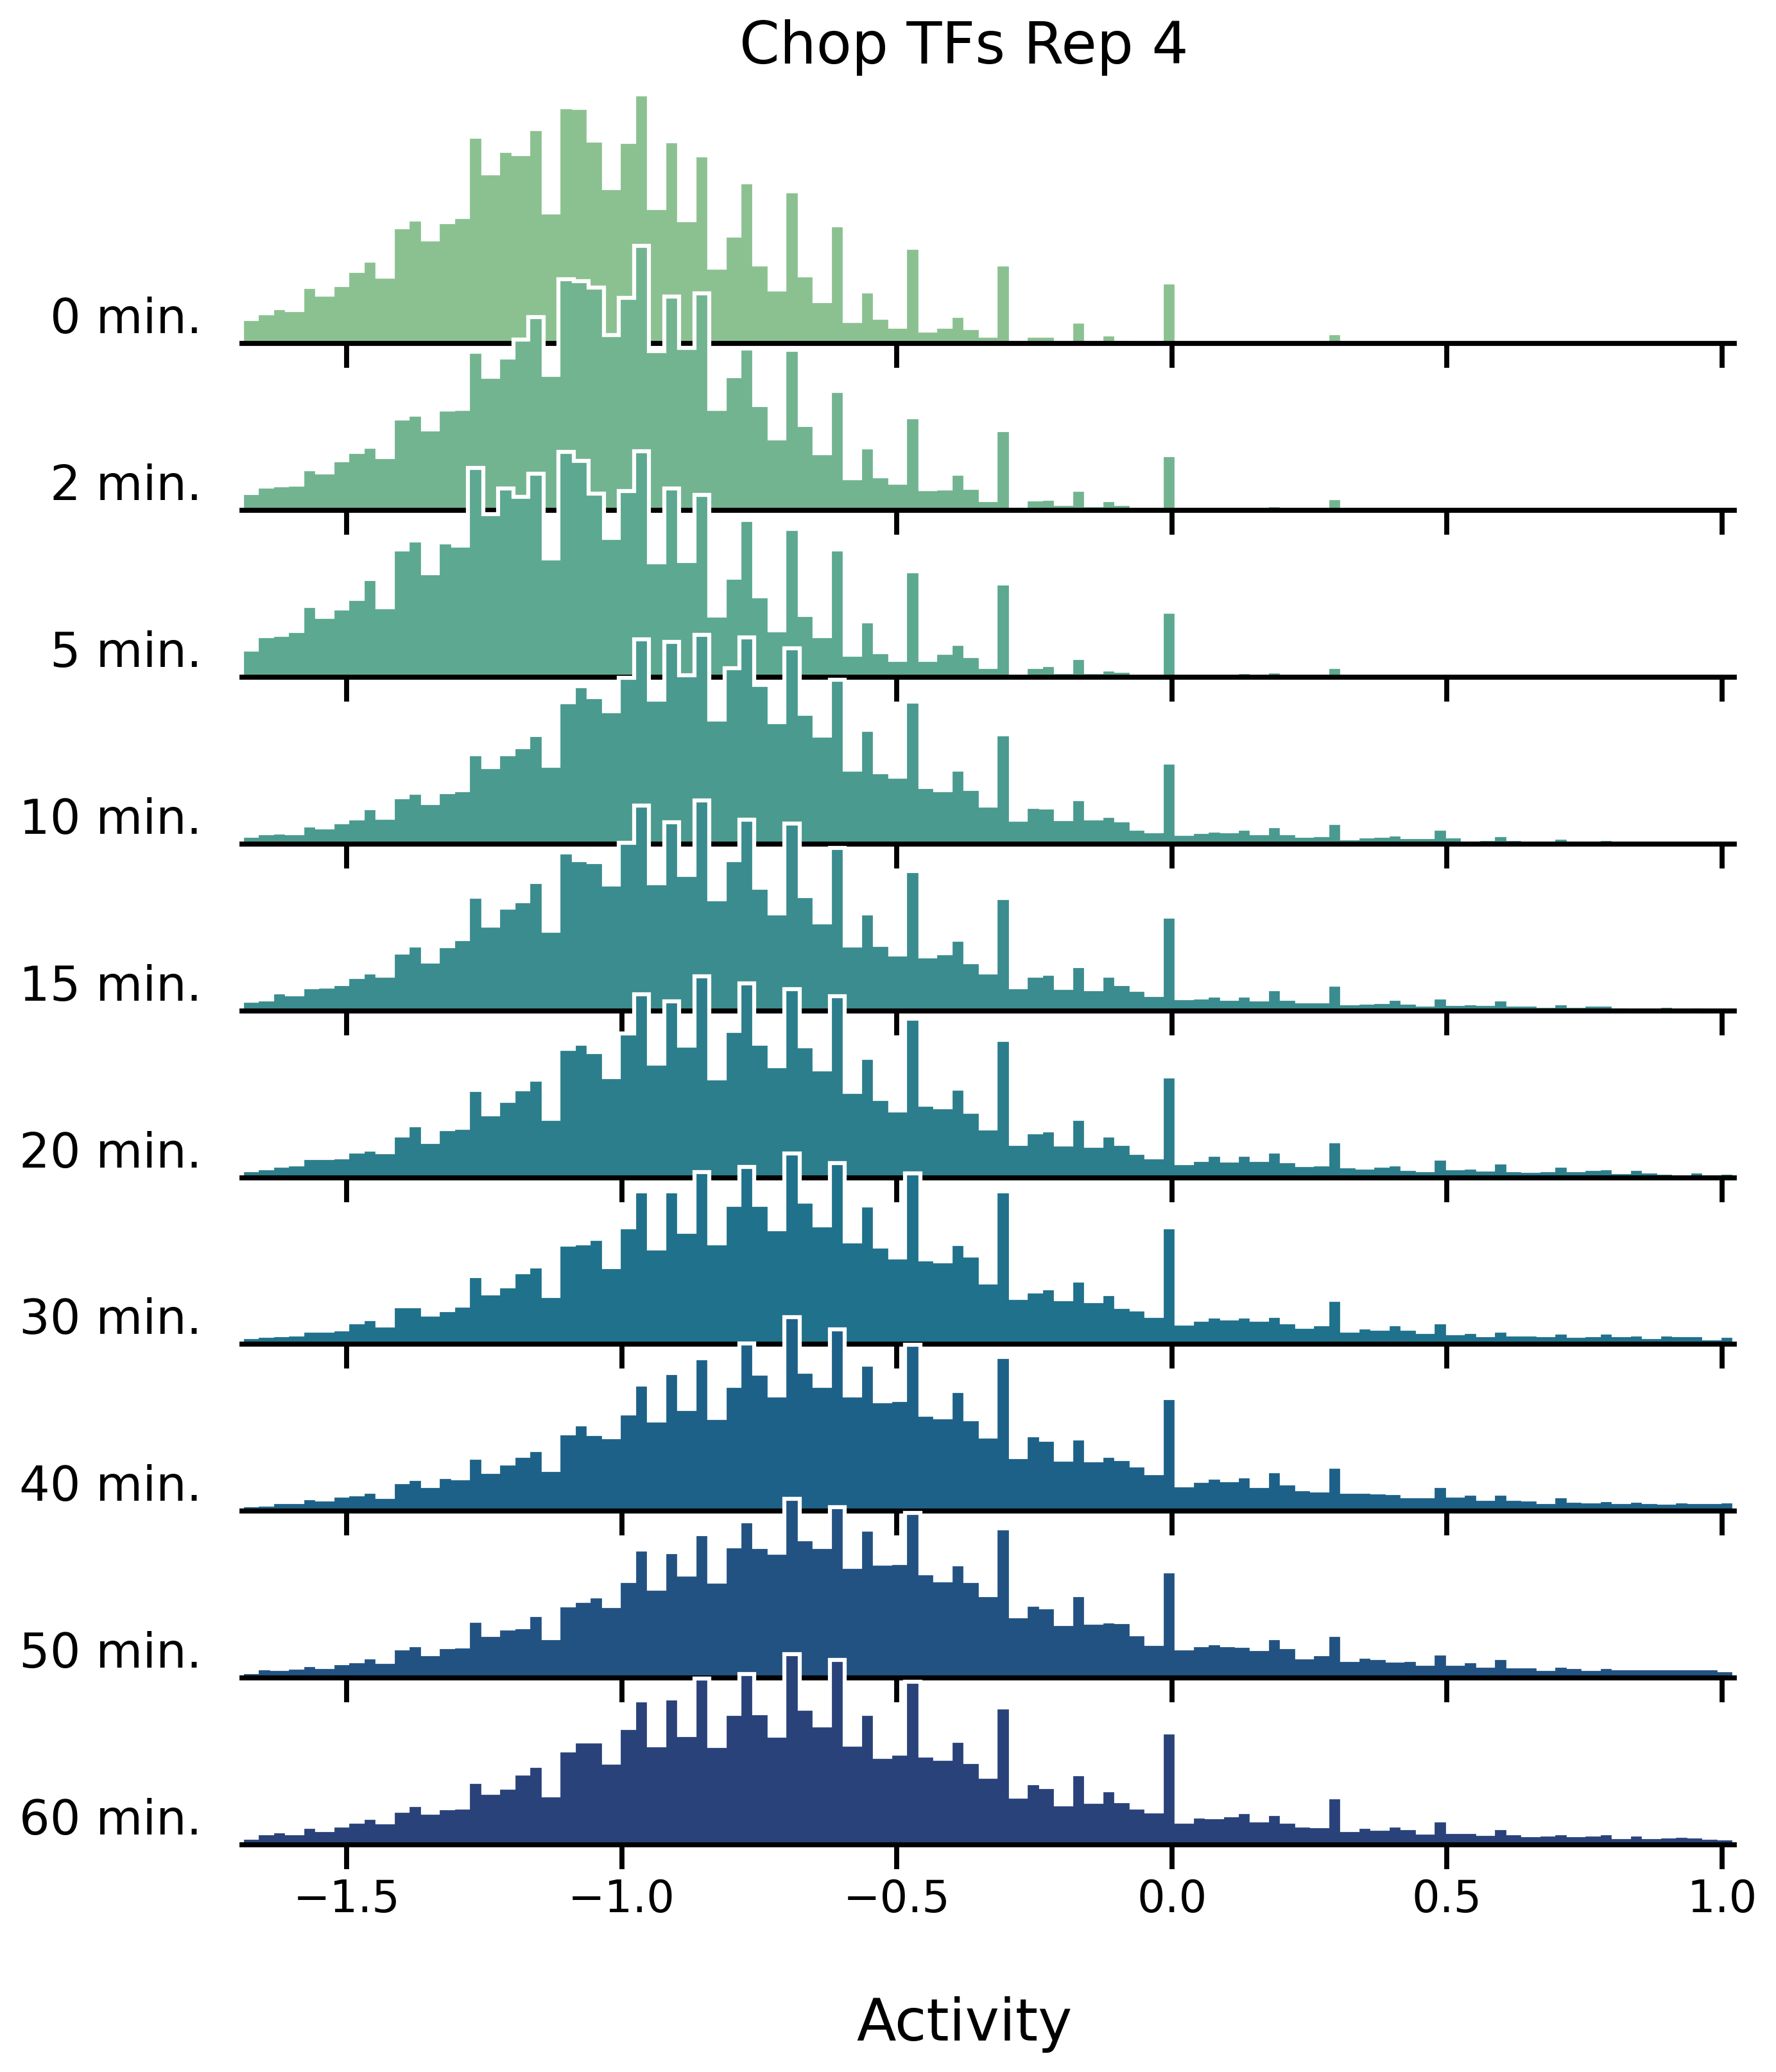

In [14]:
for rep in [2,3,4]:
    fig,axs = time_normalization_helpers.plot_ridge(activities[activities["rep"] == rep])
    fig.suptitle(f"Chop TFs Rep {rep}", y = 0.9)

# Where do negatives lie

In [15]:
activities

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [16]:
negative_controls = pd.read_csv("../../../data/NegControls_Design_AA.csv")
negative_controls

,DNAseq,AAseq
0,GATGCTTTGTCTTCTTCTTCTTTGCCATCTACTGCTGTTGCTCAAG...,DALSSSSLPSTAVAQGDIQTTSTADTETKNPAQSDIAEAA
1,TCTTCTTTGCCATCTACTGCTGTTGCTCAAGGTGATATTCAAACTA...,SSLPSTAVAQGDIQTTSTADTETKNPAQSDIAEAARQLLE
2,TTGAATGCTTATAGAGAAAAAGGTGGTTGTGTTTTGTTGATTCATA...,LNAYREKGGCVLLIHRDTKQVVEYLLQDKTRPAYREDIED
3,GCTTTGCATAATACTTTGTTTCAATTGACTGGTTTGCCACATTCTT...,ALHNTLFQLTGLPHSYSAVETDQAEPTVRELTRRADFGGA
4,GCTCCAGCTCCACAACCATCTCCAGTTCAAAAACCAGTTGAAACTG...,APAPQPSPVQKPVETEVAVTTTSSSSRRKSGGSPASGRHS
...,...,...
198,GAATTGGCTGCTCCAACTCAACAACAACAATCTCCAGCTGCTGGTT...,ELAAPTQQQQSPAAGSEDLEAAPSPAPRRKSGNSPTSSTG
199,GCTGCTTTGGATGTTGCTTTGGCTTTGTCTCAACCAGAAACTAAAC...,AALDVALALSQPETKPAKEVSVPPSPAIRNSASPAPSPAP
200,GATGATGCTGTTGTTGAATCTGCTGCTTCTTCTTCTACTGATTCTA...,DDAVVESAASSSTDSTPAAEAENAEDNSKEATSAADNDIP
201,GATGATGCTGTTGTTGAATCTGCTGCTTCTTCTTCTACTGATTCTA...,DDAVVESAASSSTDSTPMAEAENLEDNSKEATSLADNDIP


In [17]:
activities["neg_ctrl"] = activities["AD_protein"].isin(negative_controls["AAseq"])
activities

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein,neg_ctrl
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,False
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,False
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,False
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,False


In [18]:
neg_ctrl_ads = activities[activities["neg_ctrl"]]["AD_protein"].unique()
neg_ctrl_ads

array(['PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP',
       'DDAVVESAASSSTDSTPMAEAENLEDNSKEATSLADNDIP',
       'DDAVVESAASSSTDSTPAAEAENAEDNSKEATSAADNDIP',
       'DVTPASPMIRTTSSRATSPSARSVTKPSHVAGVNARQRKP'], dtype=object)

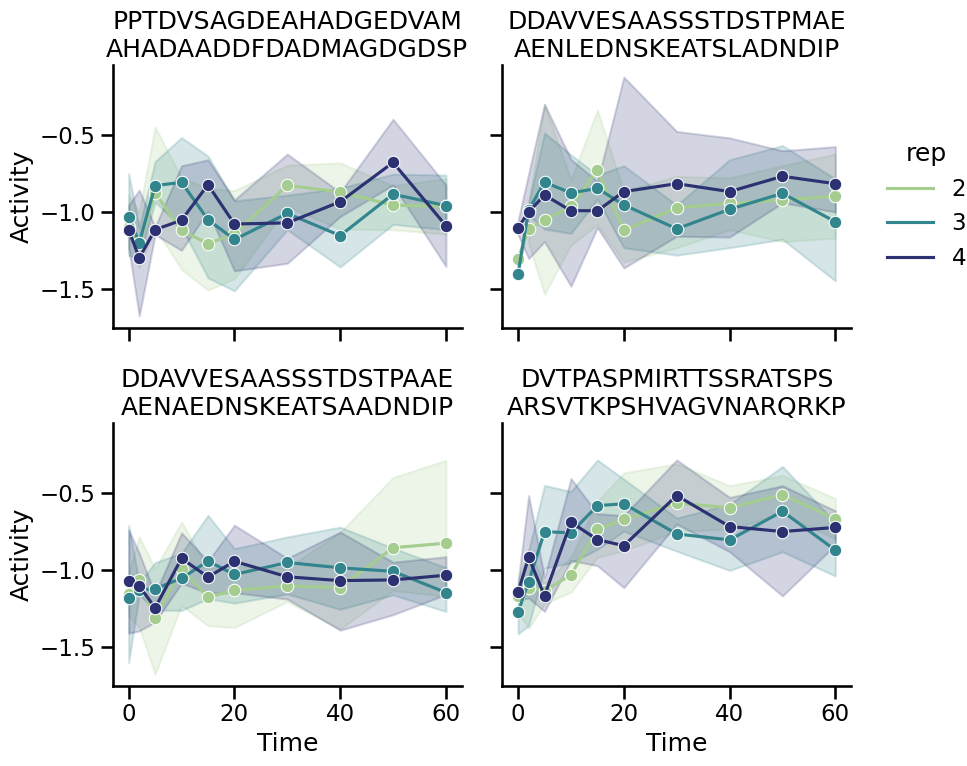

In [19]:
sns.set_context('talk')

neg_ctrl_ads = [
    "PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP",
    "DDAVVESAASSSTDSTPMAEAENLEDNSKEATSLADNDIP",
    "DDAVVESAASSSTDSTPAAEAENAEDNSKEATSAADNDIP",
    "DVTPASPMIRTTSSRATSPSARSVTKPSHVAGVNARQRKP"
]

df = activities[activities["AD_protein"].isin(neg_ctrl_ads)]


g = sns.relplot(
    data=df,
    x="time",
    y="activity_directional",
    hue="rep",
    col="AD_protein",
    kind="line",
    marker="o",
    col_wrap=2,
    height=4,
    palette = 'crest'
)

for ax in g.axes.flat:
    title = ax.get_title().replace("AD_protein = ", "")
    ax.set_title("\n".join(textwrap.wrap(title, 20)))

plt.tight_layout()
g._legend.set_bbox_to_anchor((1.1, 0.7))

g.set_axis_labels("Time", "Activity")
sns.despine()

# Z-score normalization

In [20]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/trebl_experiment_activities_per_barcode.csv", index_col = 0)
activities

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [21]:
activities = activities.rename(columns = {"AD_protein" : "seq", "activity_directional" : "score"})
activities = activities[["seq", "AD_BC", "score", "rep", "time"]]
activities

,seq,AD_BC,score,rep,time
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.201645,2,0
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.113943,2,2
2,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.311754,2,5
3,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-0.845098,2,10
4,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-0.569104,2,15
...,...,...,...,...,...
1827292,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,TACAACTTTAT,-0.909080,4,20
1827293,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,TACAACTTTAT,-0.788370,4,30
1827294,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,TACAACTTTAT,-0.773604,4,40
1827295,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,TACAACTTTAT,-0.602060,4,50


In [22]:
# Create a dictionary to hold the split dataframes
activities_by_time_rep = {}

# Group by 'time' and 'rep'
for (rep, time), group in activities.groupby(['rep', 'time']):
    activities_by_time_rep[(rep, time)] = group.reset_index(drop=True)

In [23]:
cached_fits = {}

for (rep, time), group in tqdm.tqdm(activities.groupby(['rep', 'time'])):
    mu, sigma, truncated, df_out = time_normalization_helpers.fit_inactive_gaussian_progressive_fast(group, plot_steps = False)
    cached_fits[(rep, time)] = (mu, sigma, truncated, df_out)

100%|██████████| 30/30 [00:15<00:00,  1.93it/s]


In [24]:
# for target_rep in activities["rep"].unique():
#     rep_keys = [(rep, time) for (rep, time) in cached_fits.keys() if rep == target_rep]
#     rep_keys = sorted(rep_keys, key=lambda x: x[1])

#     nrows = len(rep_keys)
#     fig, axes = plt.subplots(nrows, 1, figsize=(6, nrows * 1), dpi=300, sharex=True, sharey=True)
#     axes = np.atleast_1d(axes)

#     fig.suptitle(f"Rep {target_rep}", fontsize='large', y=1.01, x=0.6)

#     for ax, (rep, time) in zip(axes, rep_keys):
#         mu, sigma, truncated, df = cached_fits[(rep, time)]

#         sns.histplot(truncated, ax=ax, stat='density', bins=80, kde=True)
#         ax.axvline(mu, color='red', linestyle='dashed', lw=2)

#         x = np.linspace(min(truncated), max(truncated), 200)
#         ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)

#         ax.set_ylabel(f"{time} min.", fontsize='medium', rotation=0, labelpad=60)
#         ax.set_xlabel("")

#     plt.tight_layout(pad=0)
#     sns.despine()
#     plt.show()

100%|██████████| 10/10 [00:00<00:00, 37.85it/s]


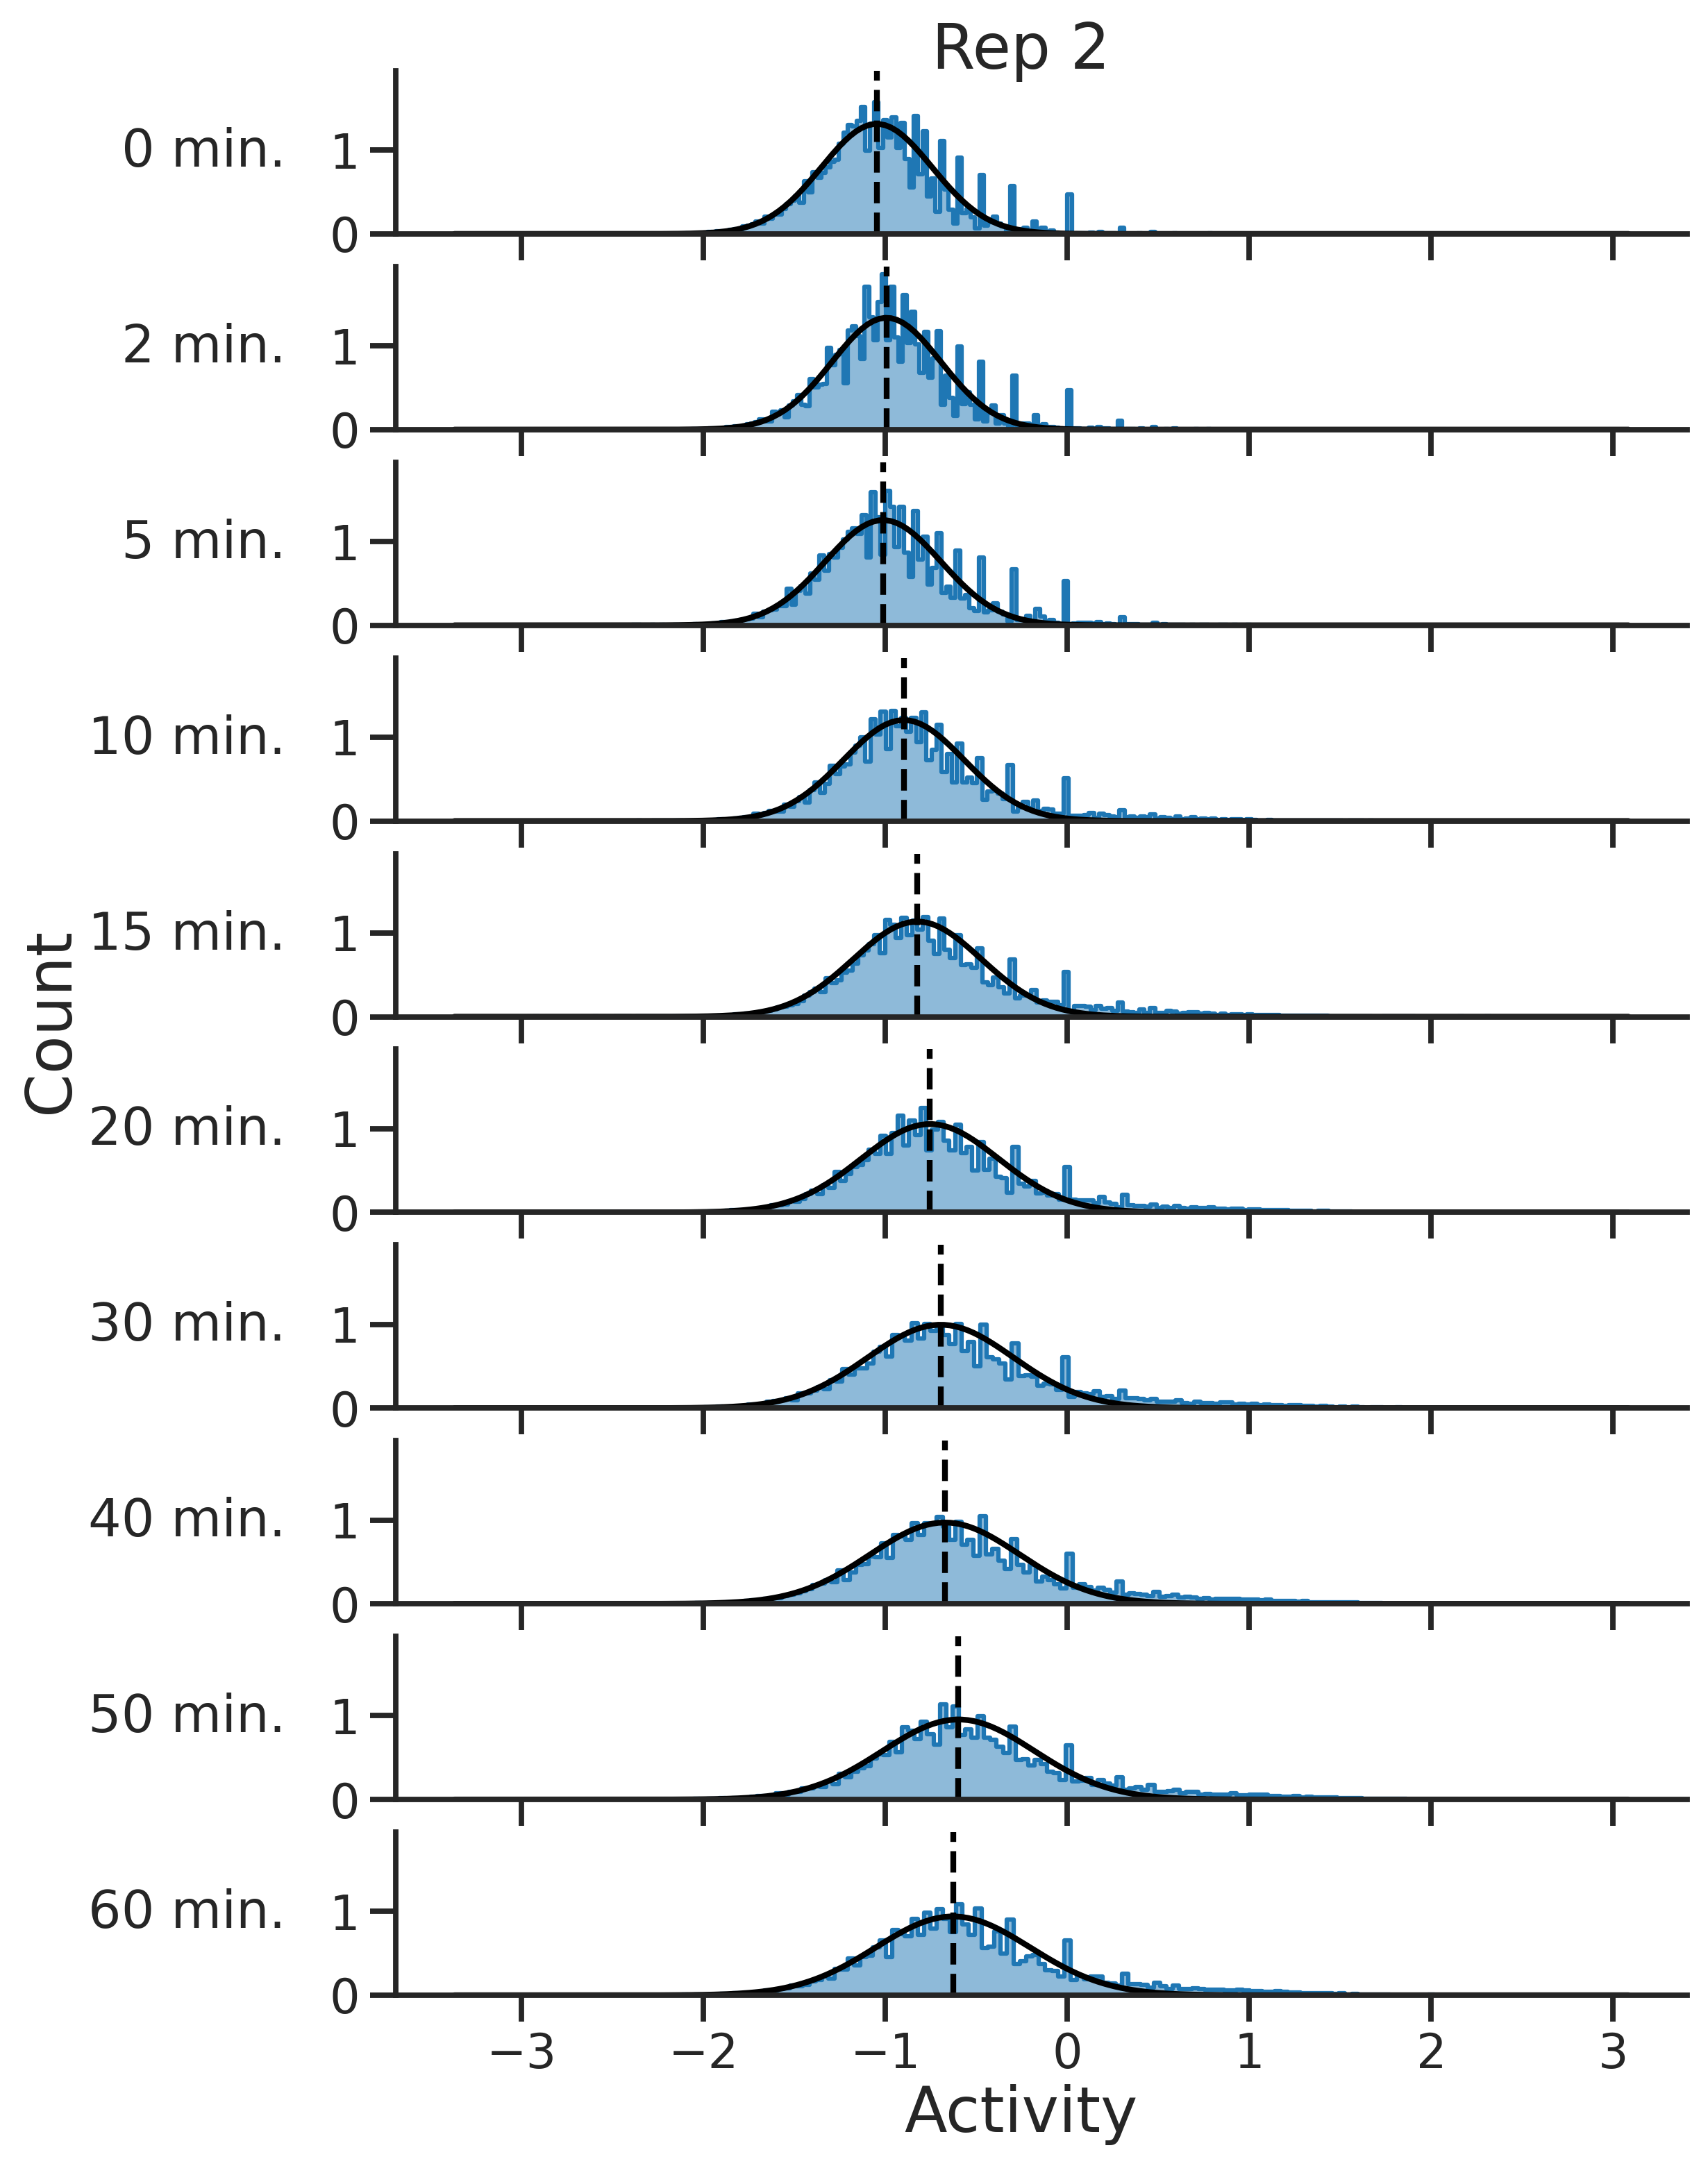

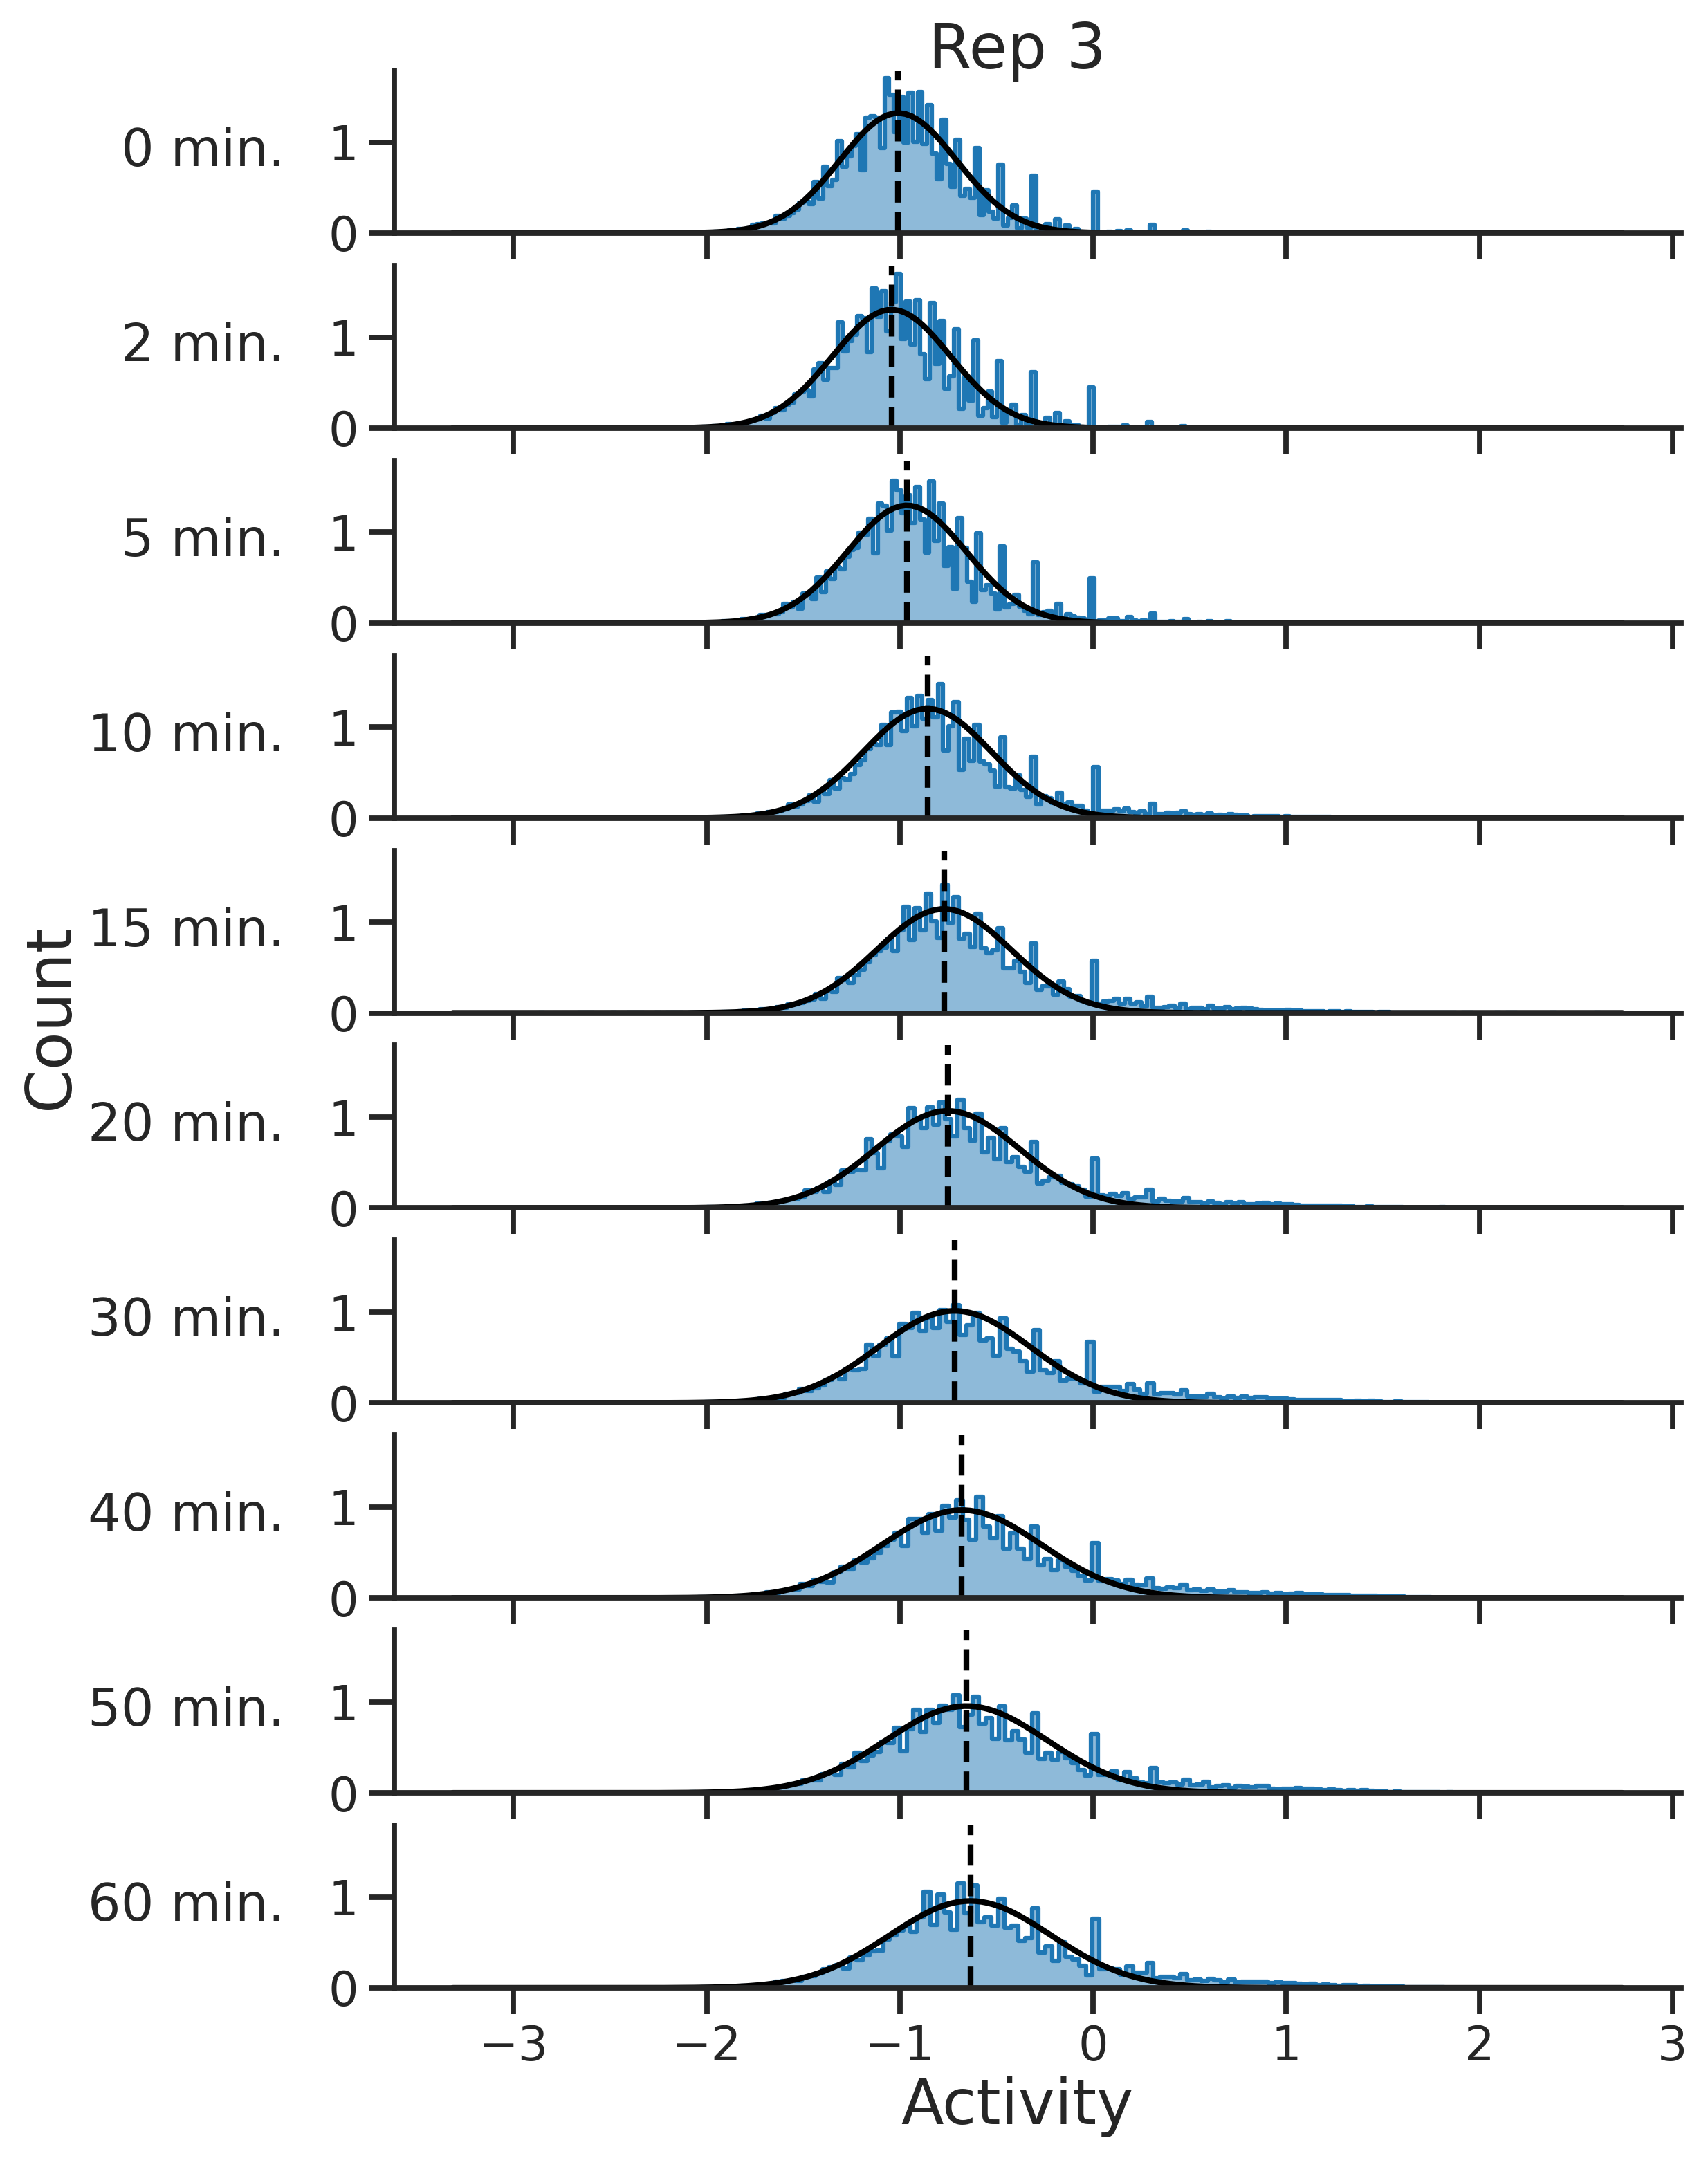

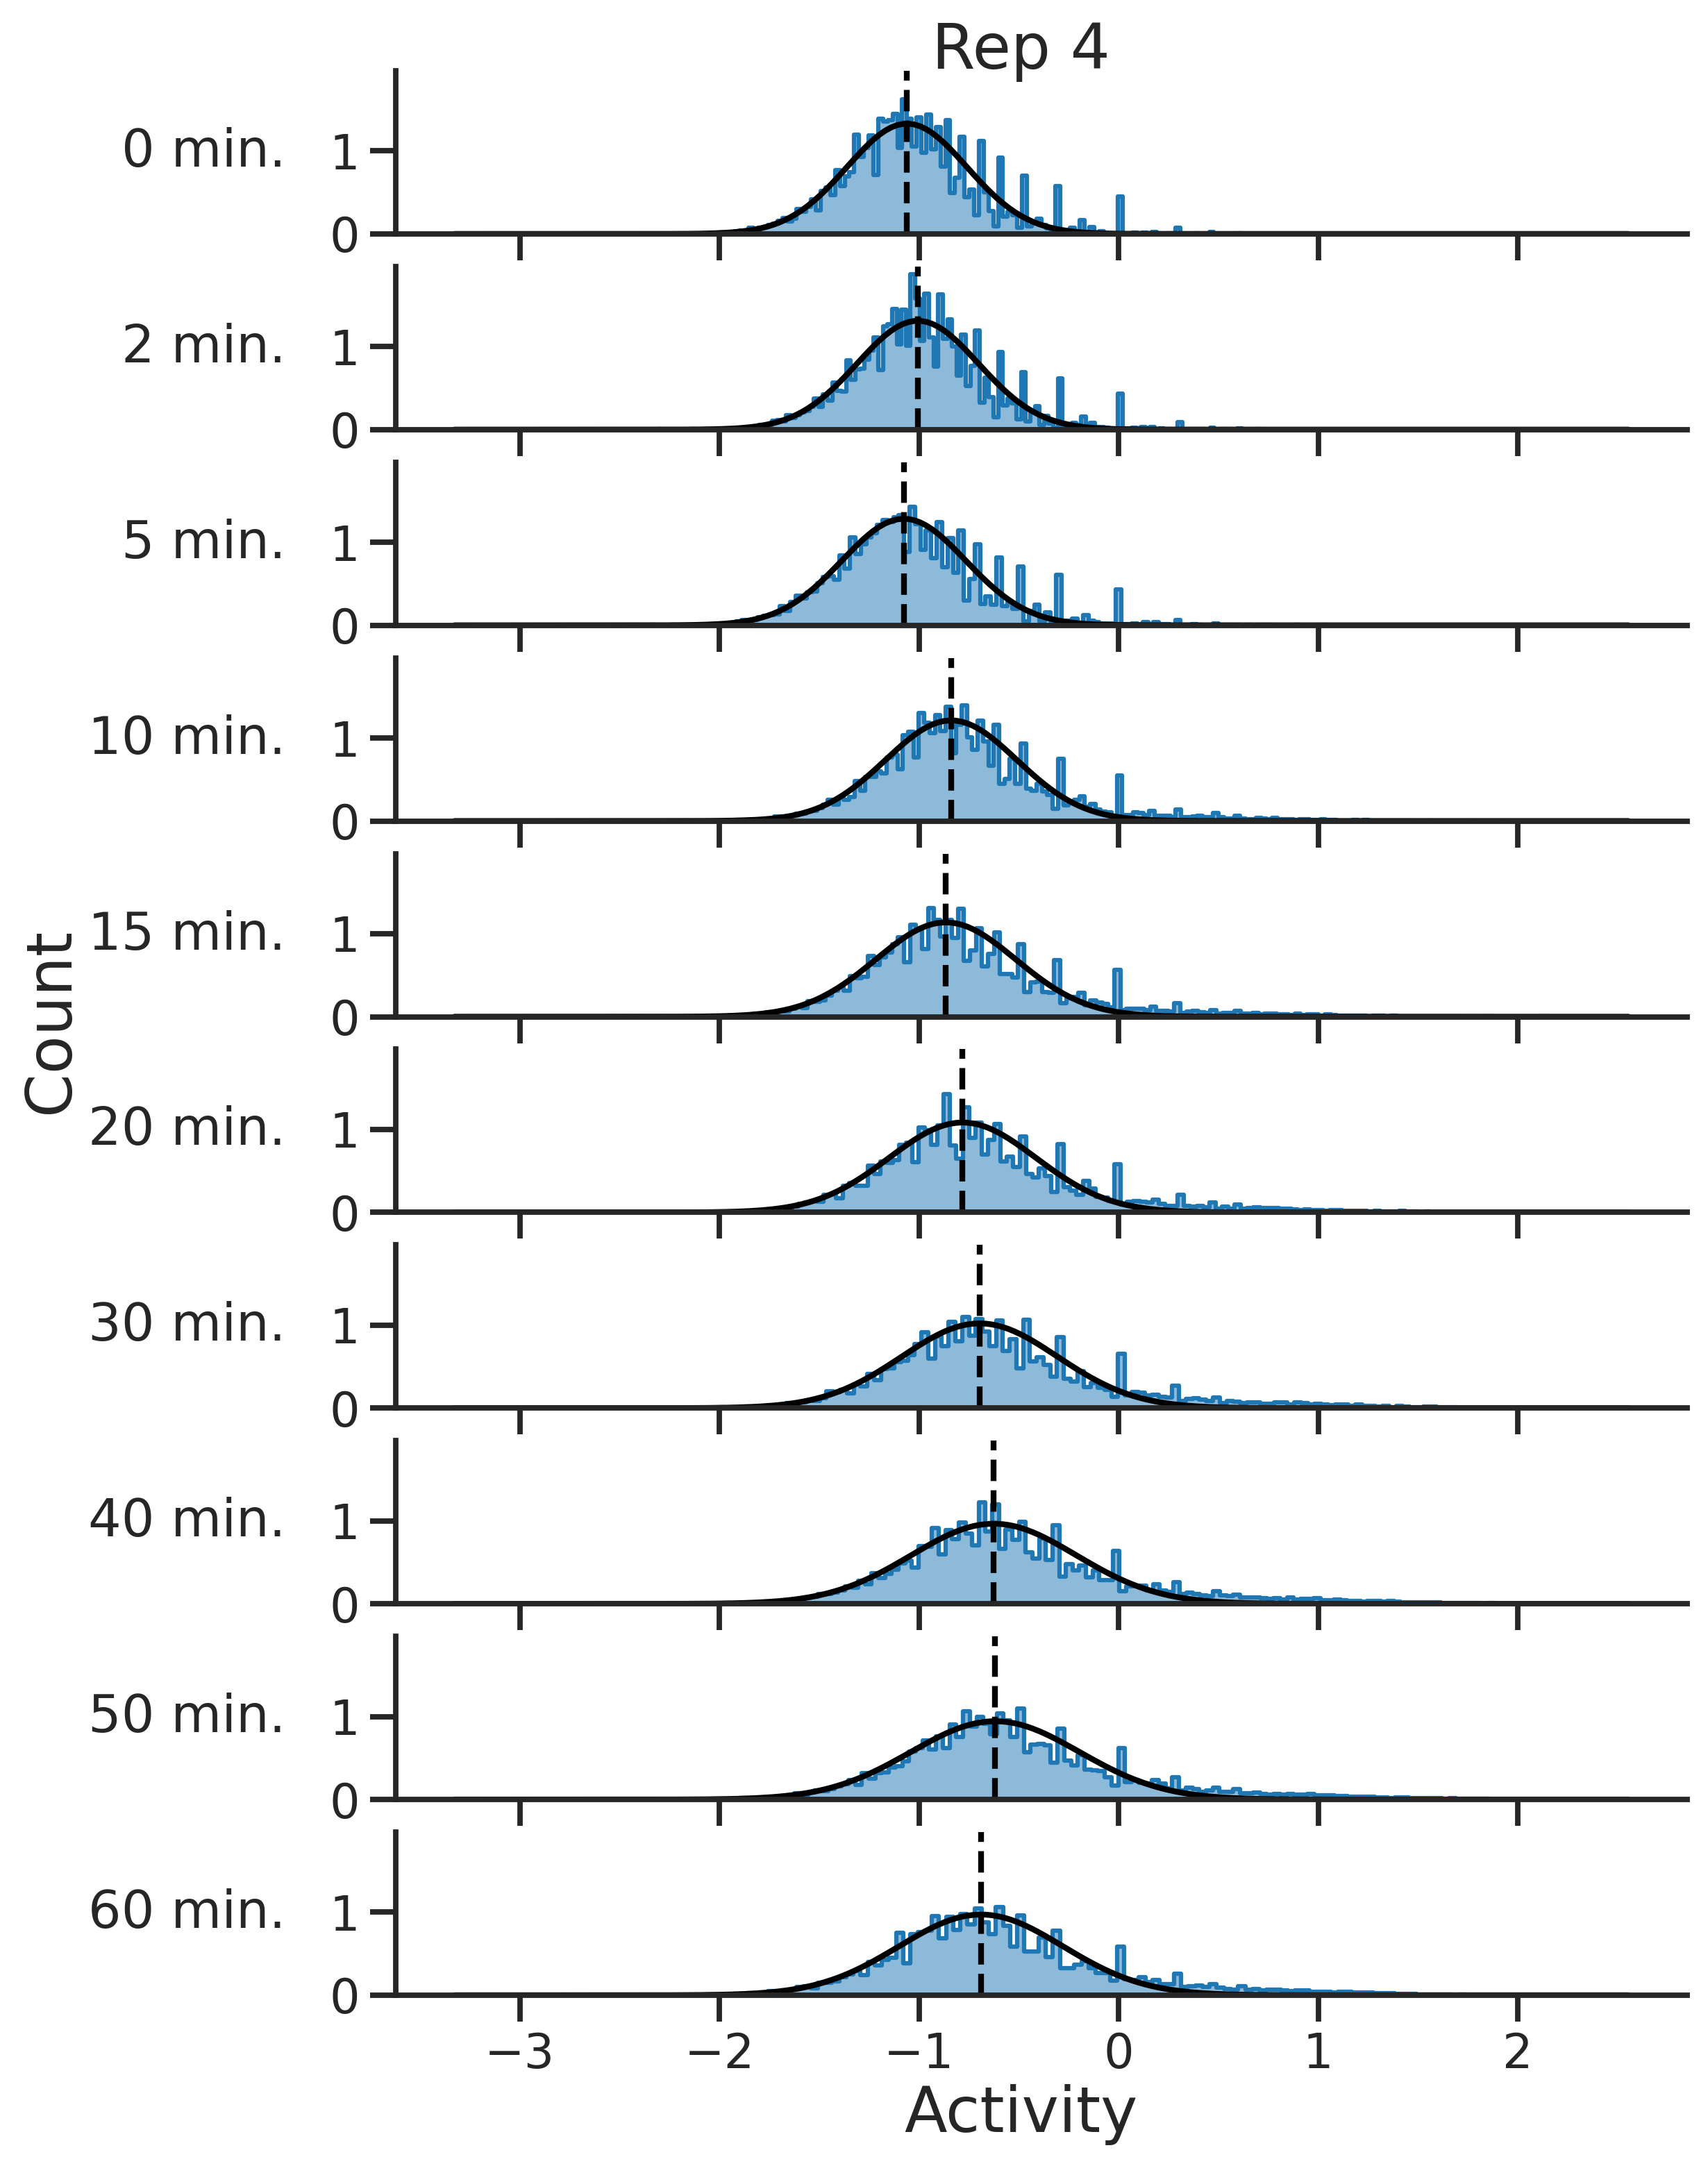

In [58]:
for rep in [2,3,4]:
    fig, axs = time_normalization_helpers.plot_gaussian_fits_over_time(
        activities[activities["rep"] == rep],
        cached_fits,
        column="score",
    )
    fig.suptitle(f"Rep {rep}", y = 0.9)
    if rep == 2:
        plt.savefig("../../../output/lab_meeting_figs_032426/full_data_distribution_with_pdf.png", bbox_inches = 'tight')

In [26]:
all_activities = pd.concat(
    [cached_fits[k][3] for k in cached_fits],
    ignore_index=True
)
all_activities

,seq,AD_BC,score,rep,time,z-scored_activity,shifted_activity,mu,sigma
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.201645,2,0,-0.506097,-0.153786,-1.047859,0.303867
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TATCTTCGCTT,-1.380211,2,0,-1.093743,-0.332352,-1.047859,0.303867
2,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCGTACCGA,-1.447158,2,0,-1.314059,-0.399299,-1.047859,0.303867
3,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTGCATAGCTG,-1.799341,2,0,-2.473062,-0.751481,-1.047859,0.303867
4,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTTATAATACC,-1.124939,2,0,-0.253662,-0.077079,-1.047859,0.303867
...,...,...,...,...,...,...,...,...,...
1361924,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCAAACTTGGA,-1.122216,4,60,-1.054444,-0.432685,-0.689530,0.410345
1361925,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCCACTCTCAG,-0.954243,4,60,-0.645097,-0.264712,-0.689530,0.410345
1361926,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,GGGTCGTAAAT,-0.425969,4,60,0.642294,0.263562,-0.689530,0.410345
1361927,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,GATCCCATGCA,-0.421324,4,60,0.653613,0.268207,-0.689530,0.410345


In [27]:
all_activities.to_csv("../../../output/ChopTFs_pipeline/time_normalization/full_data_time_normalized_activities.csv")

100%|██████████| 10/10 [00:00<00:00, 36.53it/s]


Text(0.5, 0.9, 'Chop TFs Rep 4')

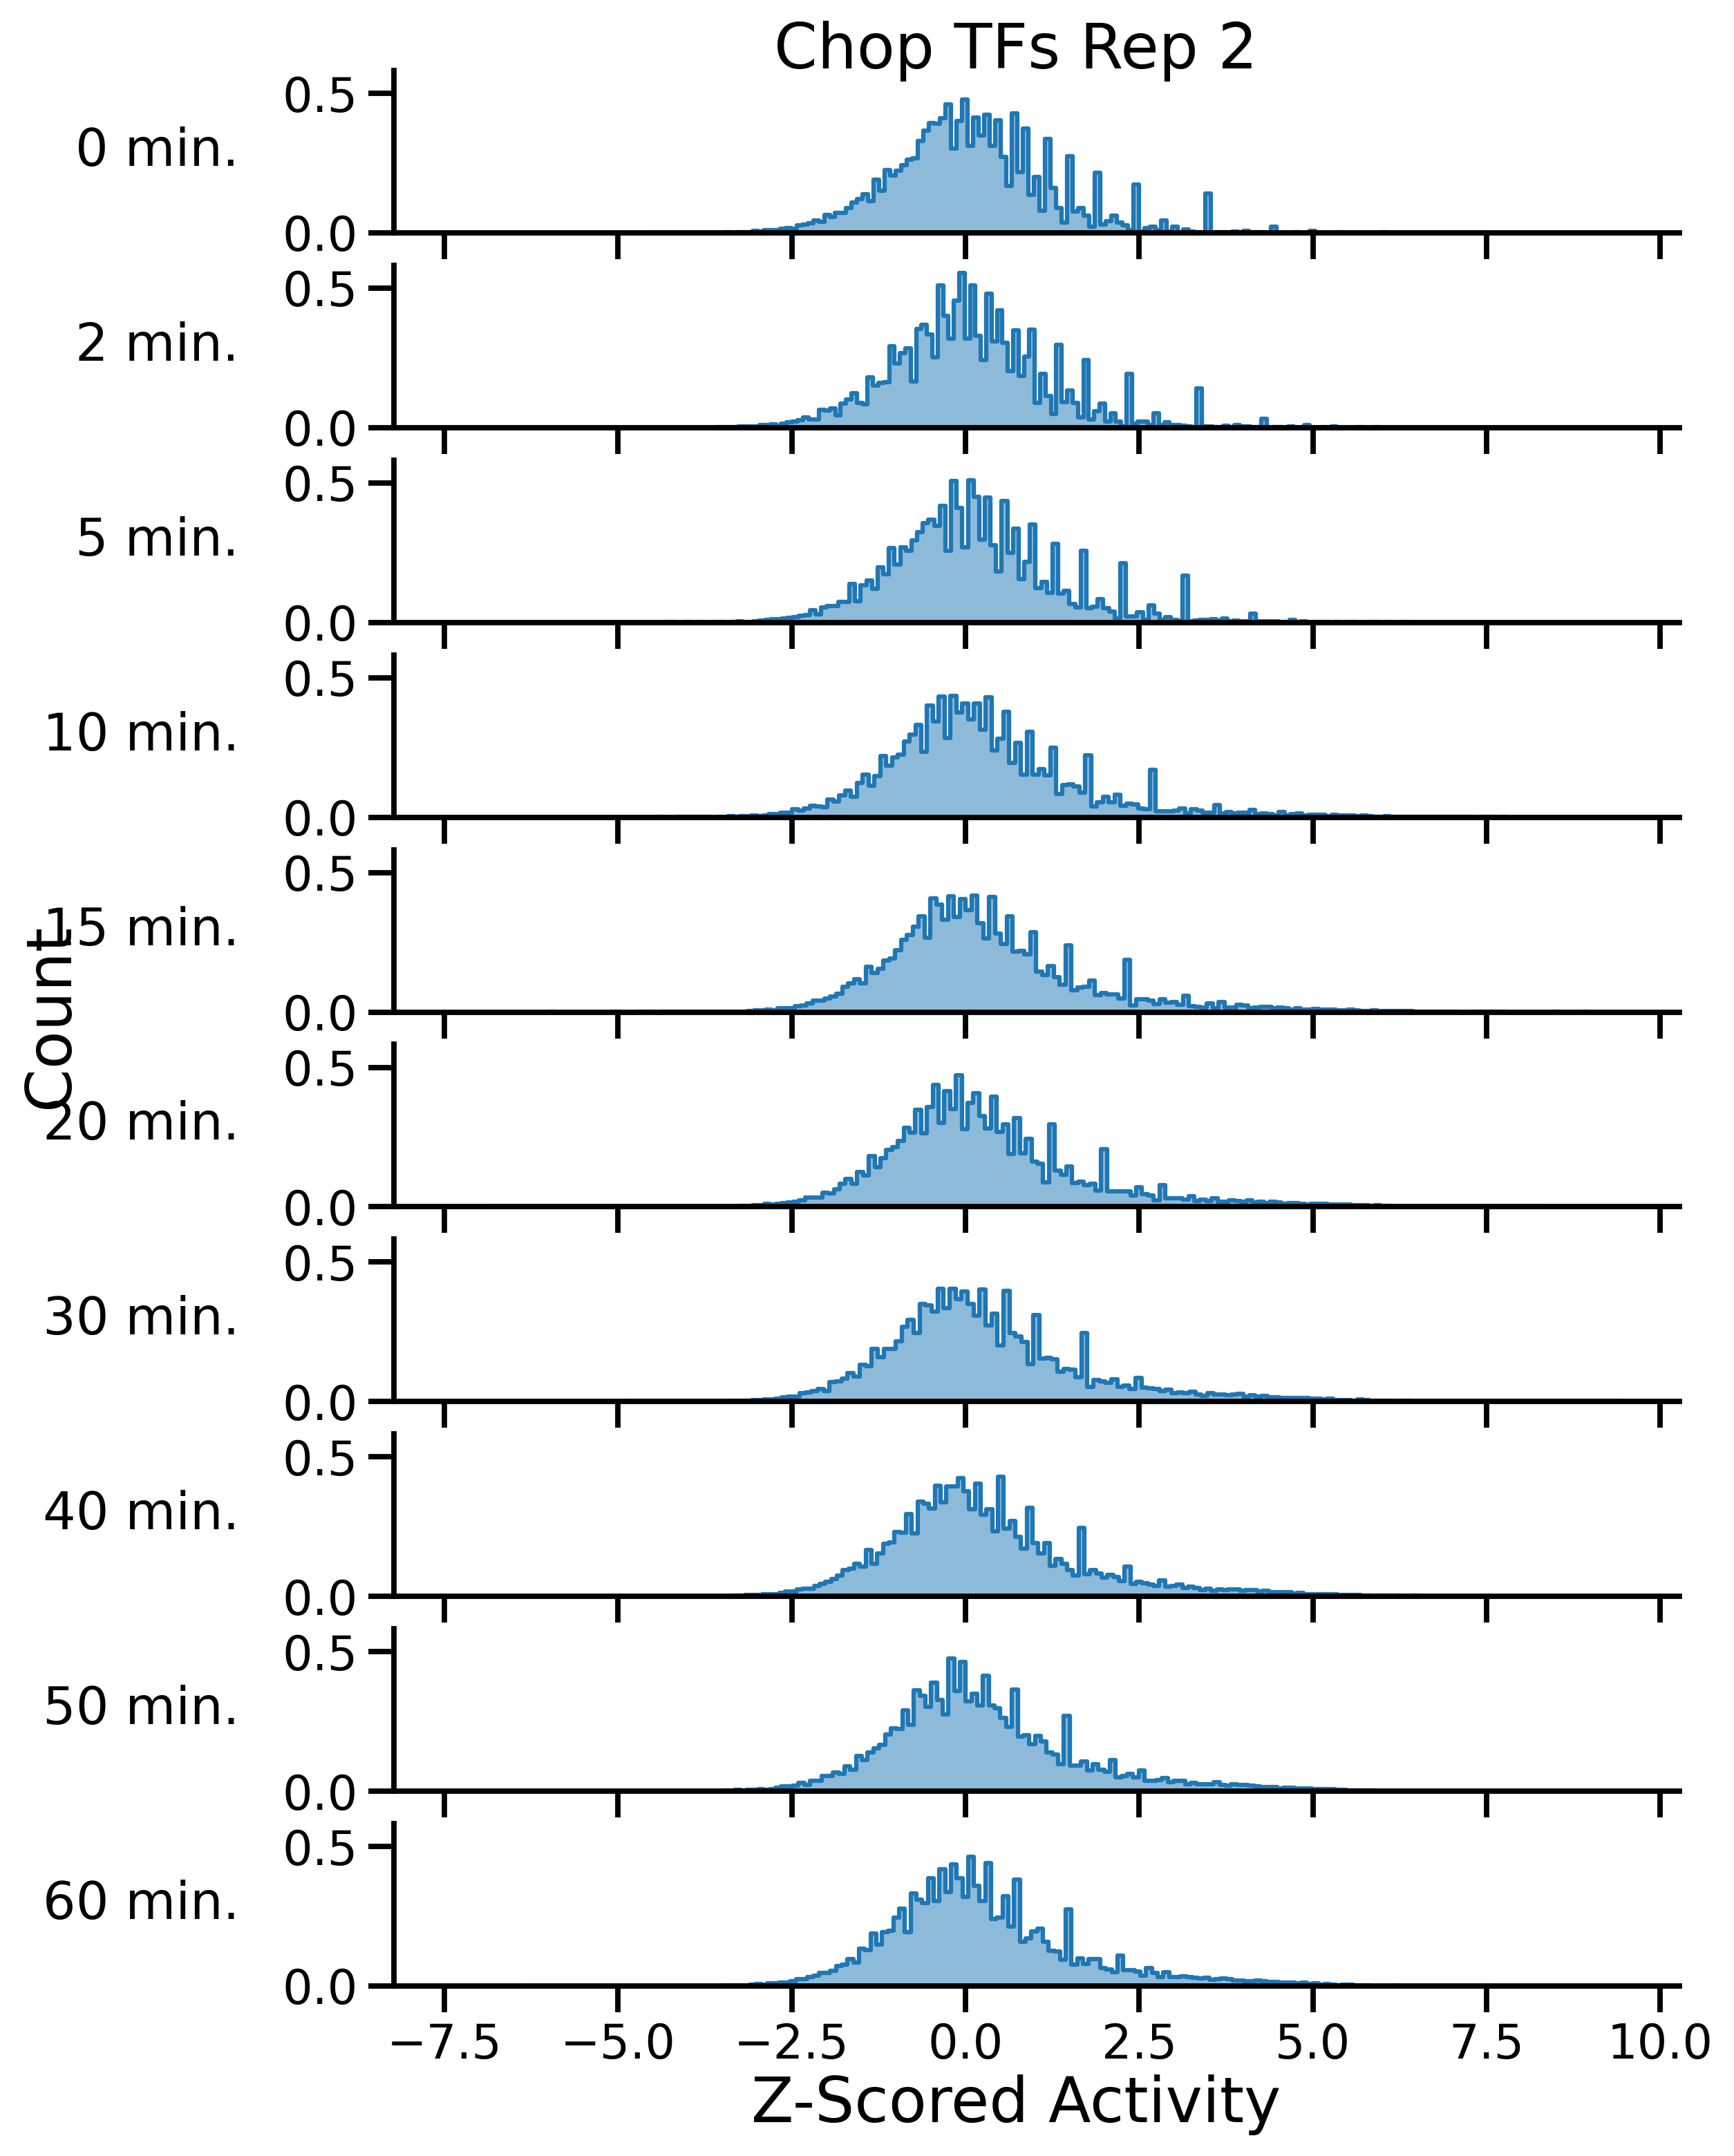

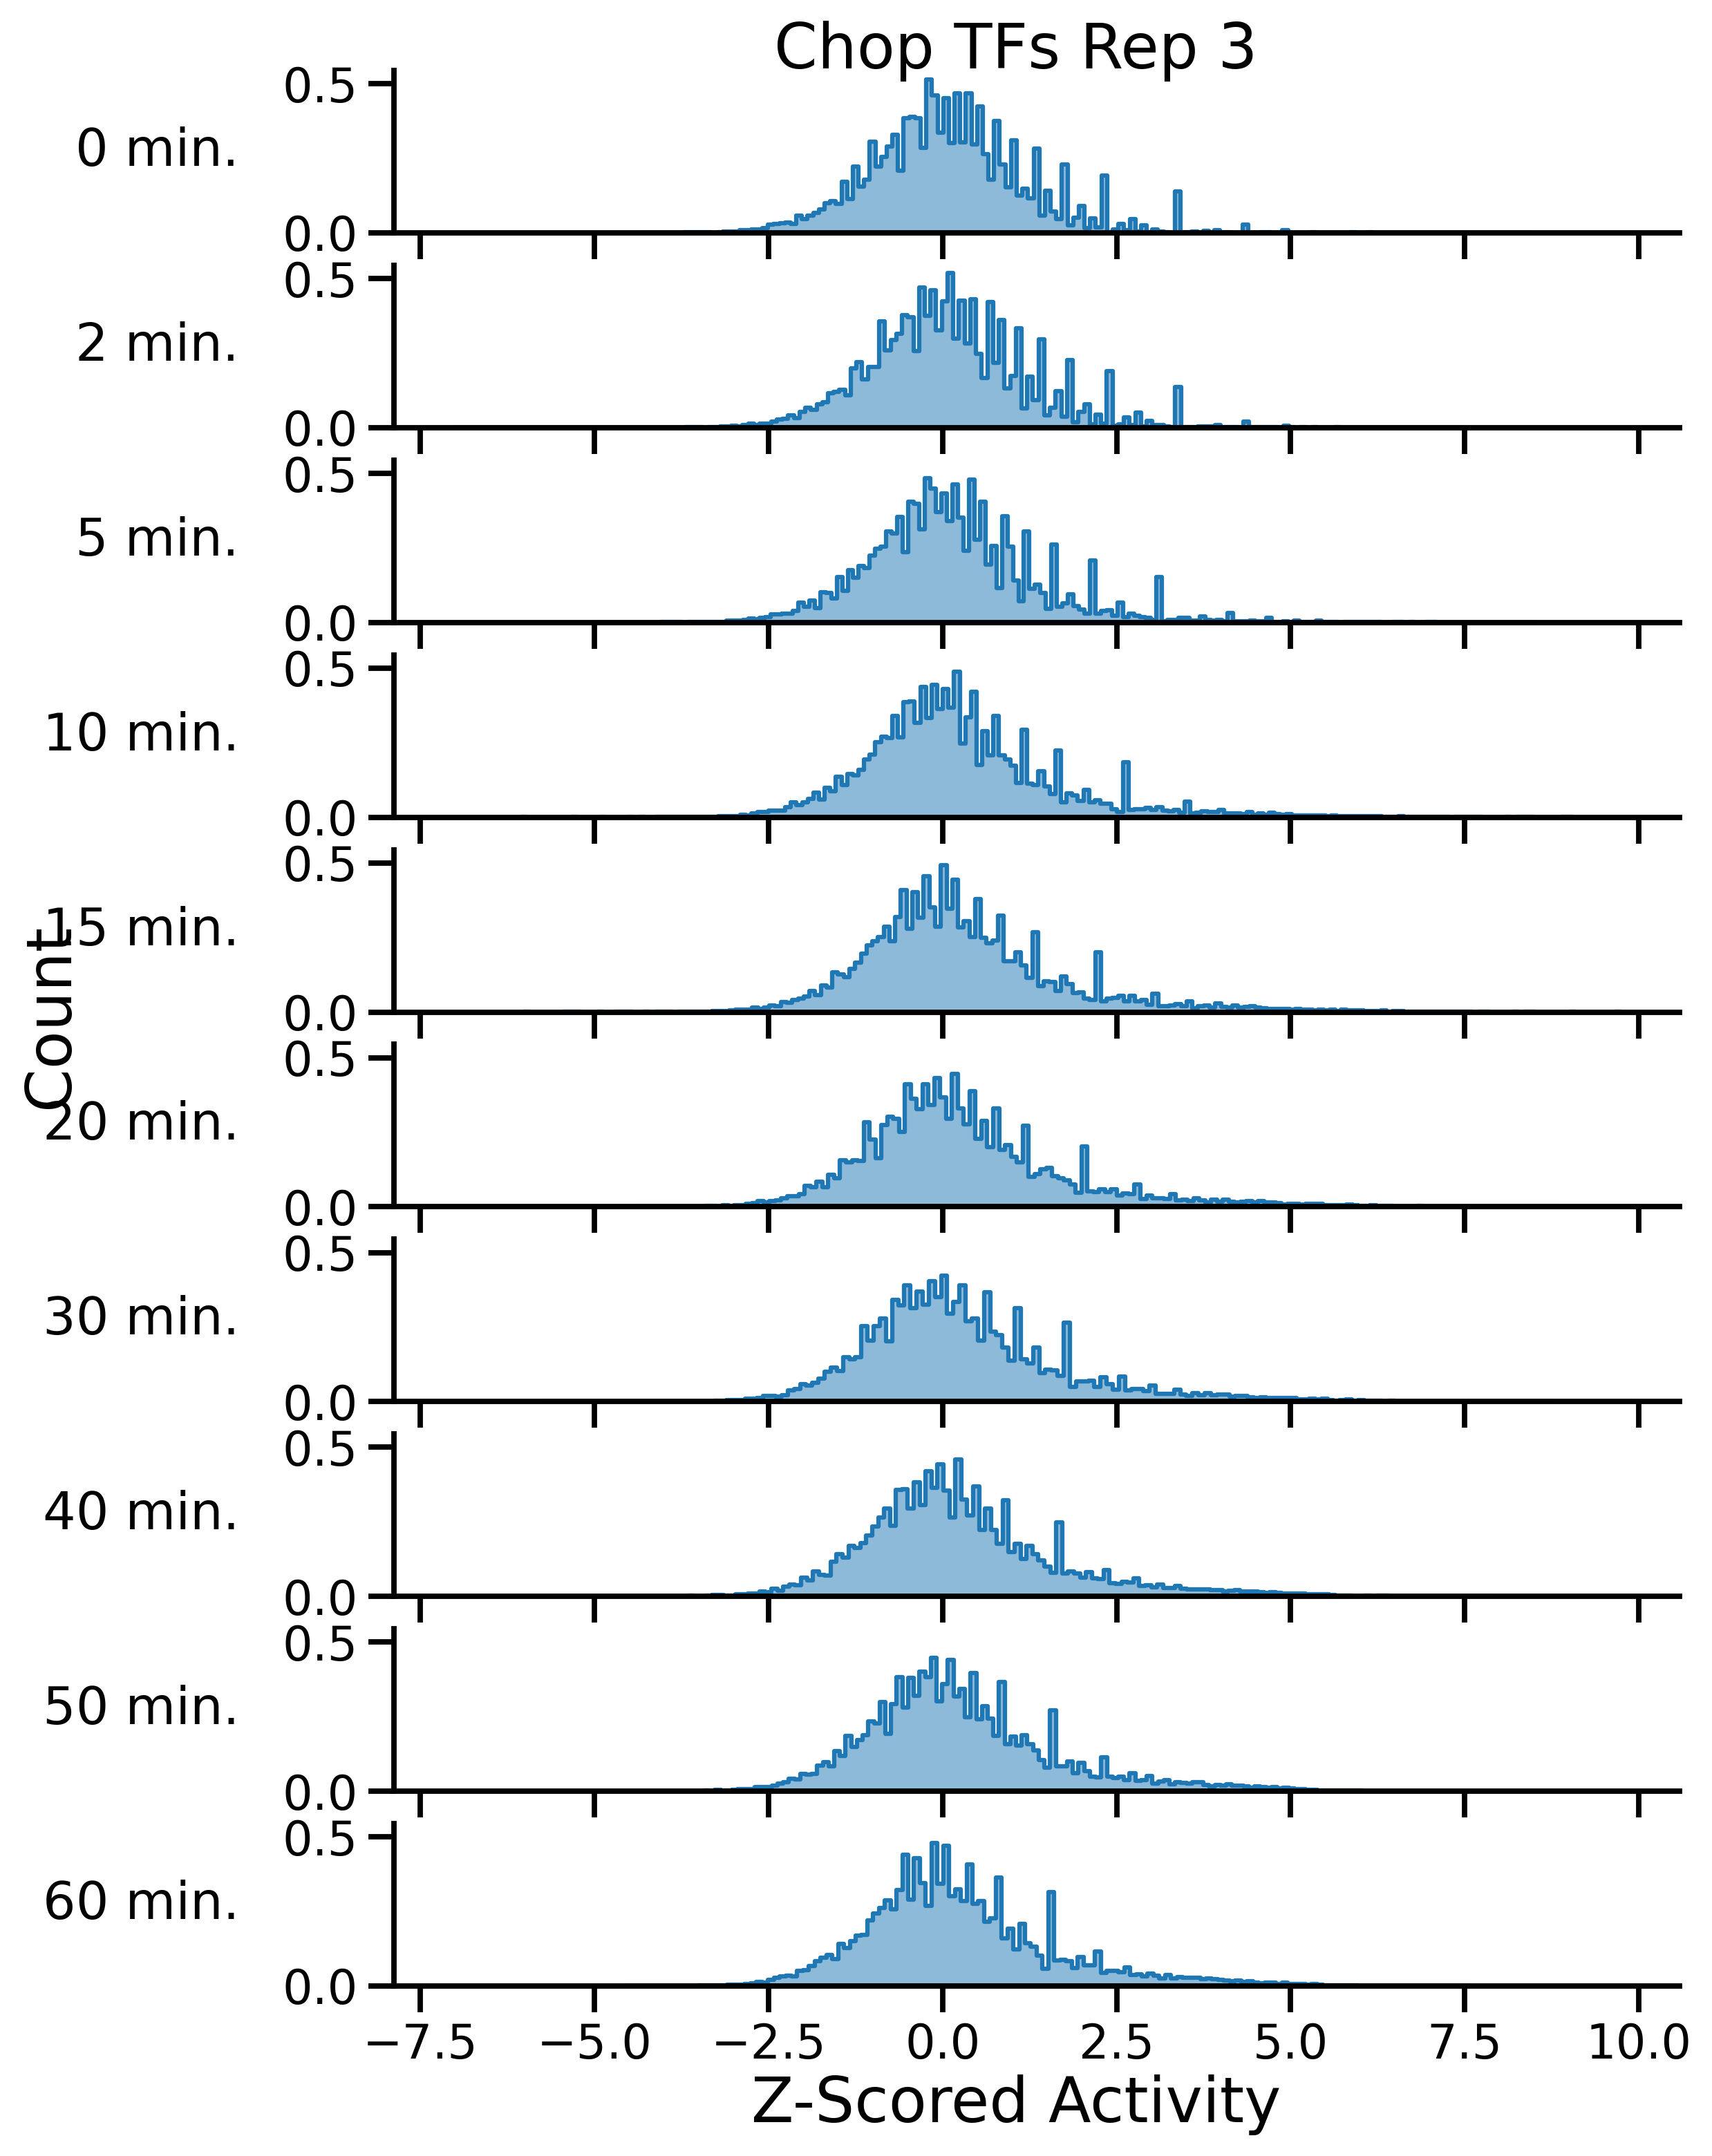

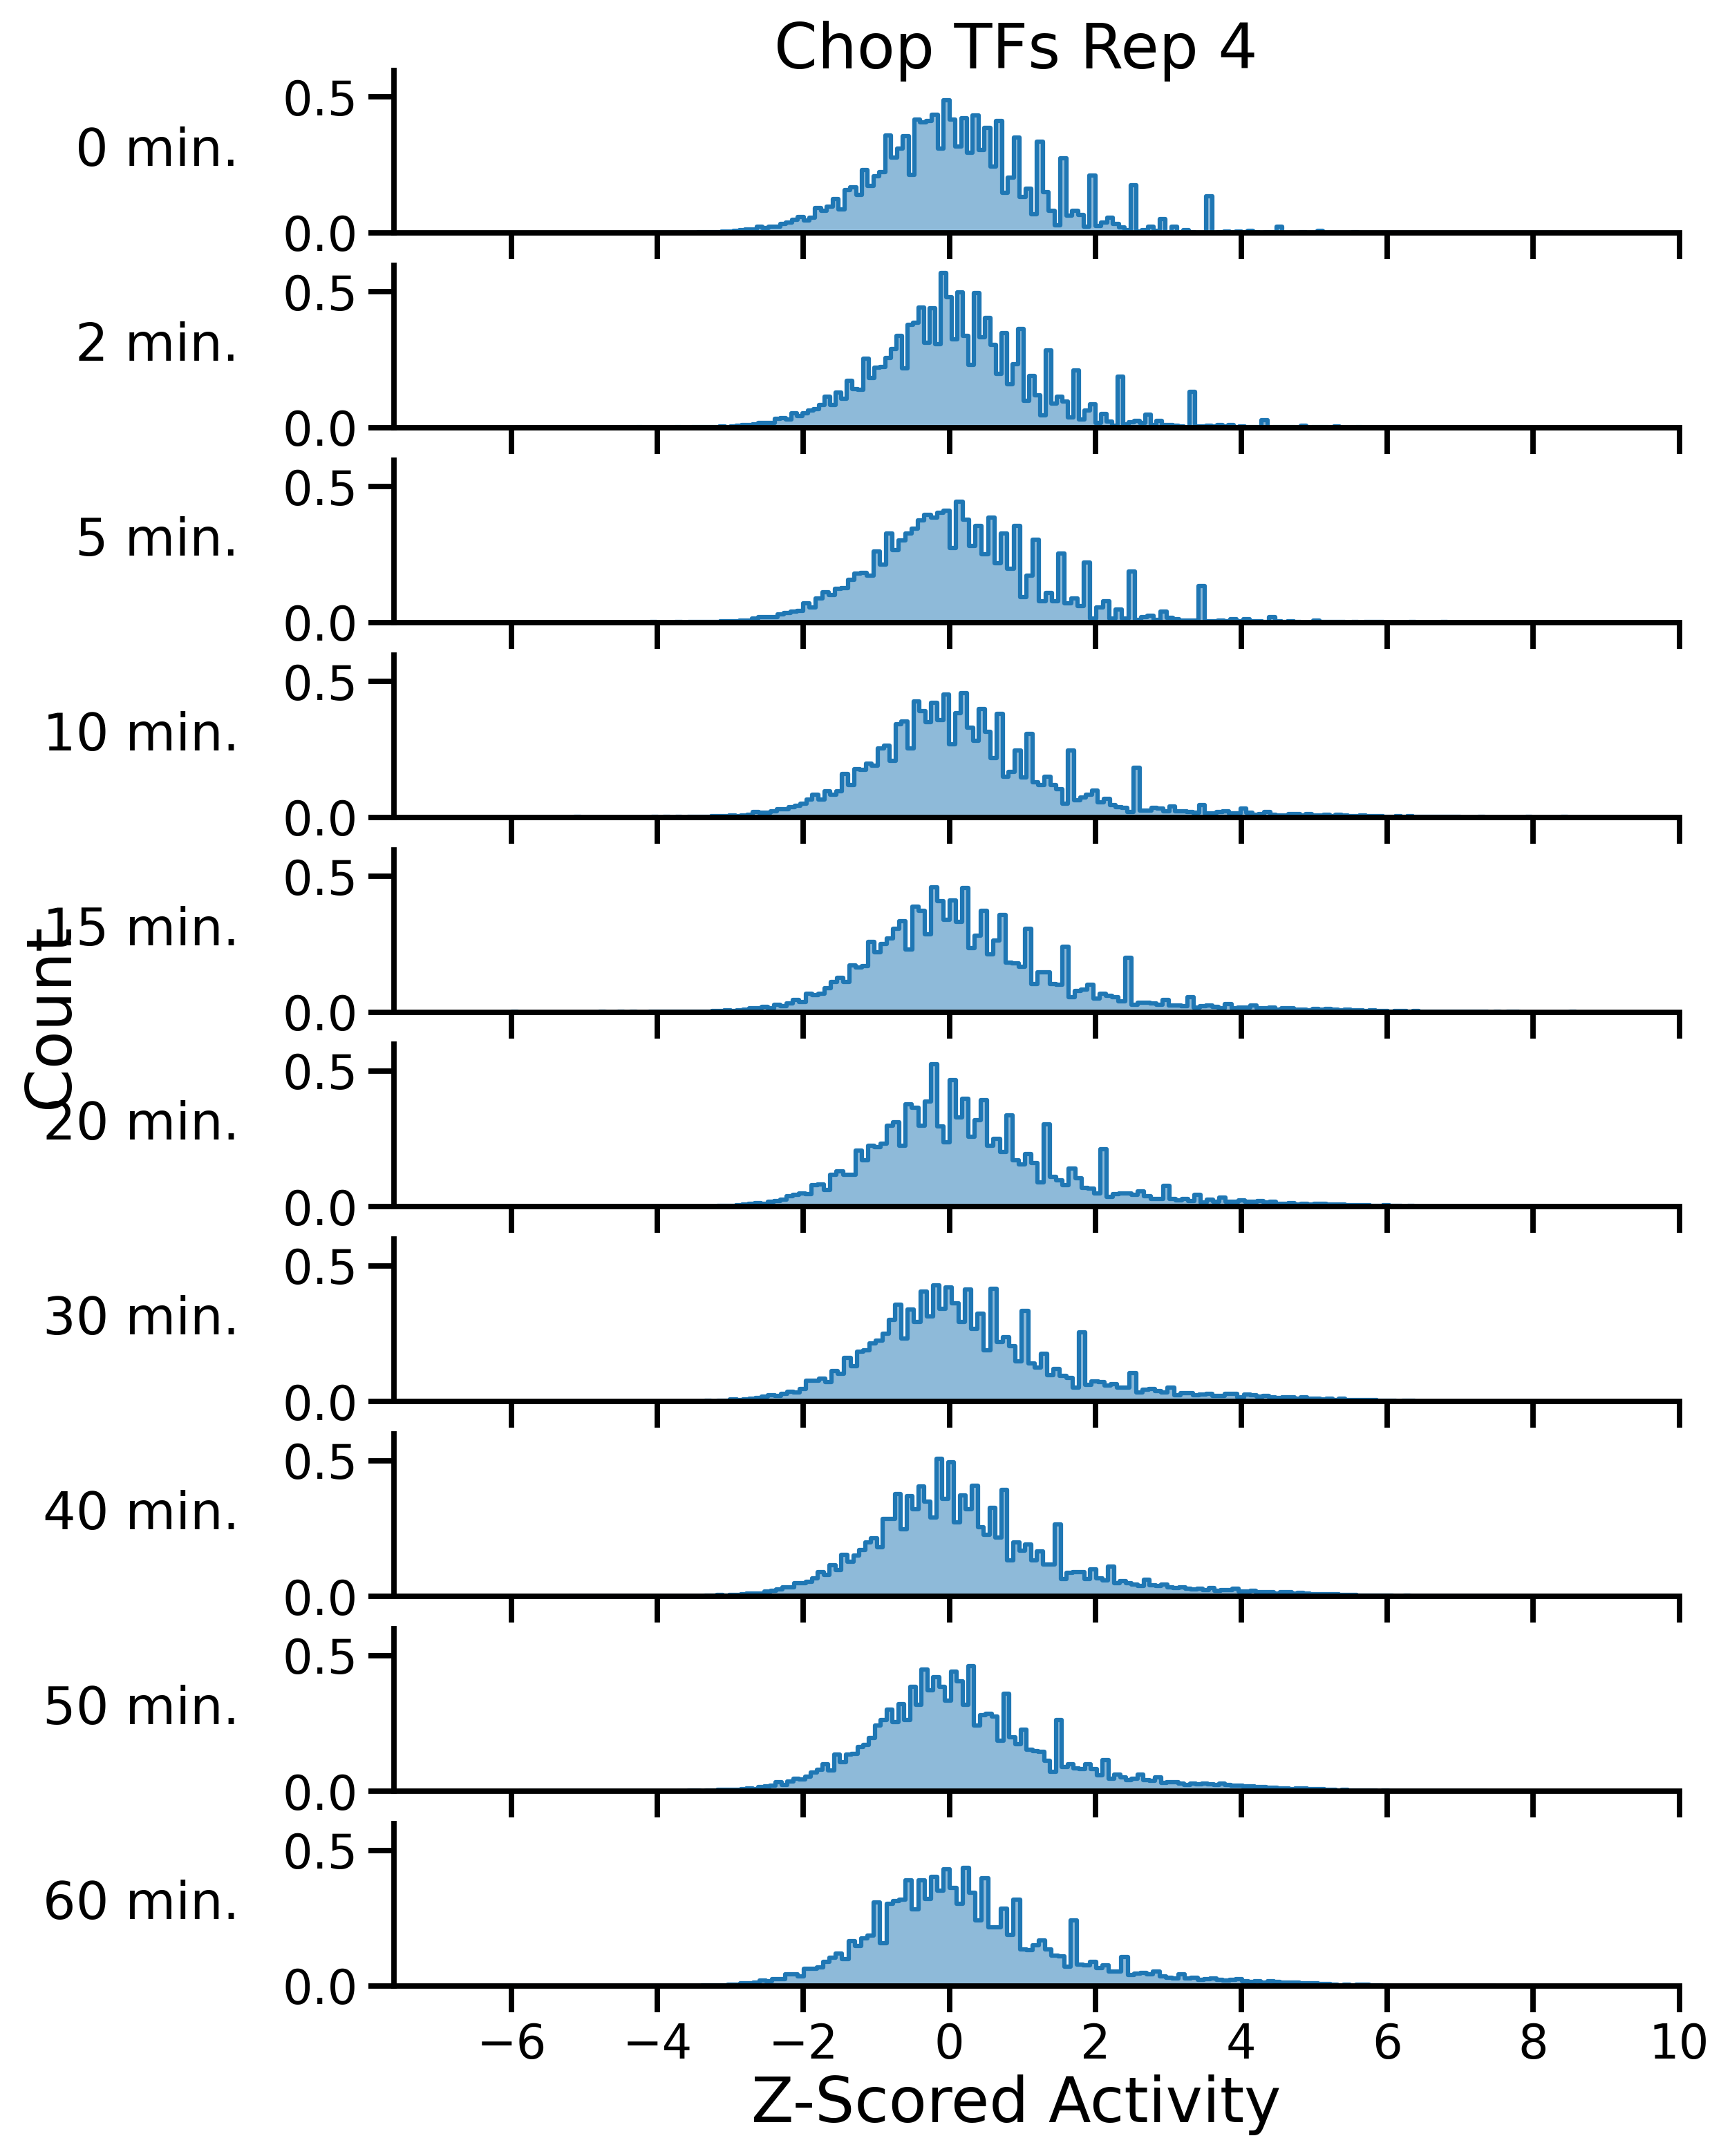

In [28]:
fig, axs = time_normalization_helpers.plot_hists_over_time(all_activities[all_activities["rep"] == 2], "z-scored_activity", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 2", y = 0.9)

fig, axs = time_normalization_helpers.plot_hists_over_time(all_activities[all_activities["rep"] == 3], "z-scored_activity", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 3", y = 0.9)

fig, axs = time_normalization_helpers.plot_hists_over_time(all_activities[all_activities["rep"] == 4], "z-scored_activity", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 4", y = 0.9)

100%|██████████| 10/10 [00:00<00:00, 39.73it/s]


Text(0.5, 0.9, 'Chop TFs Rep 4')

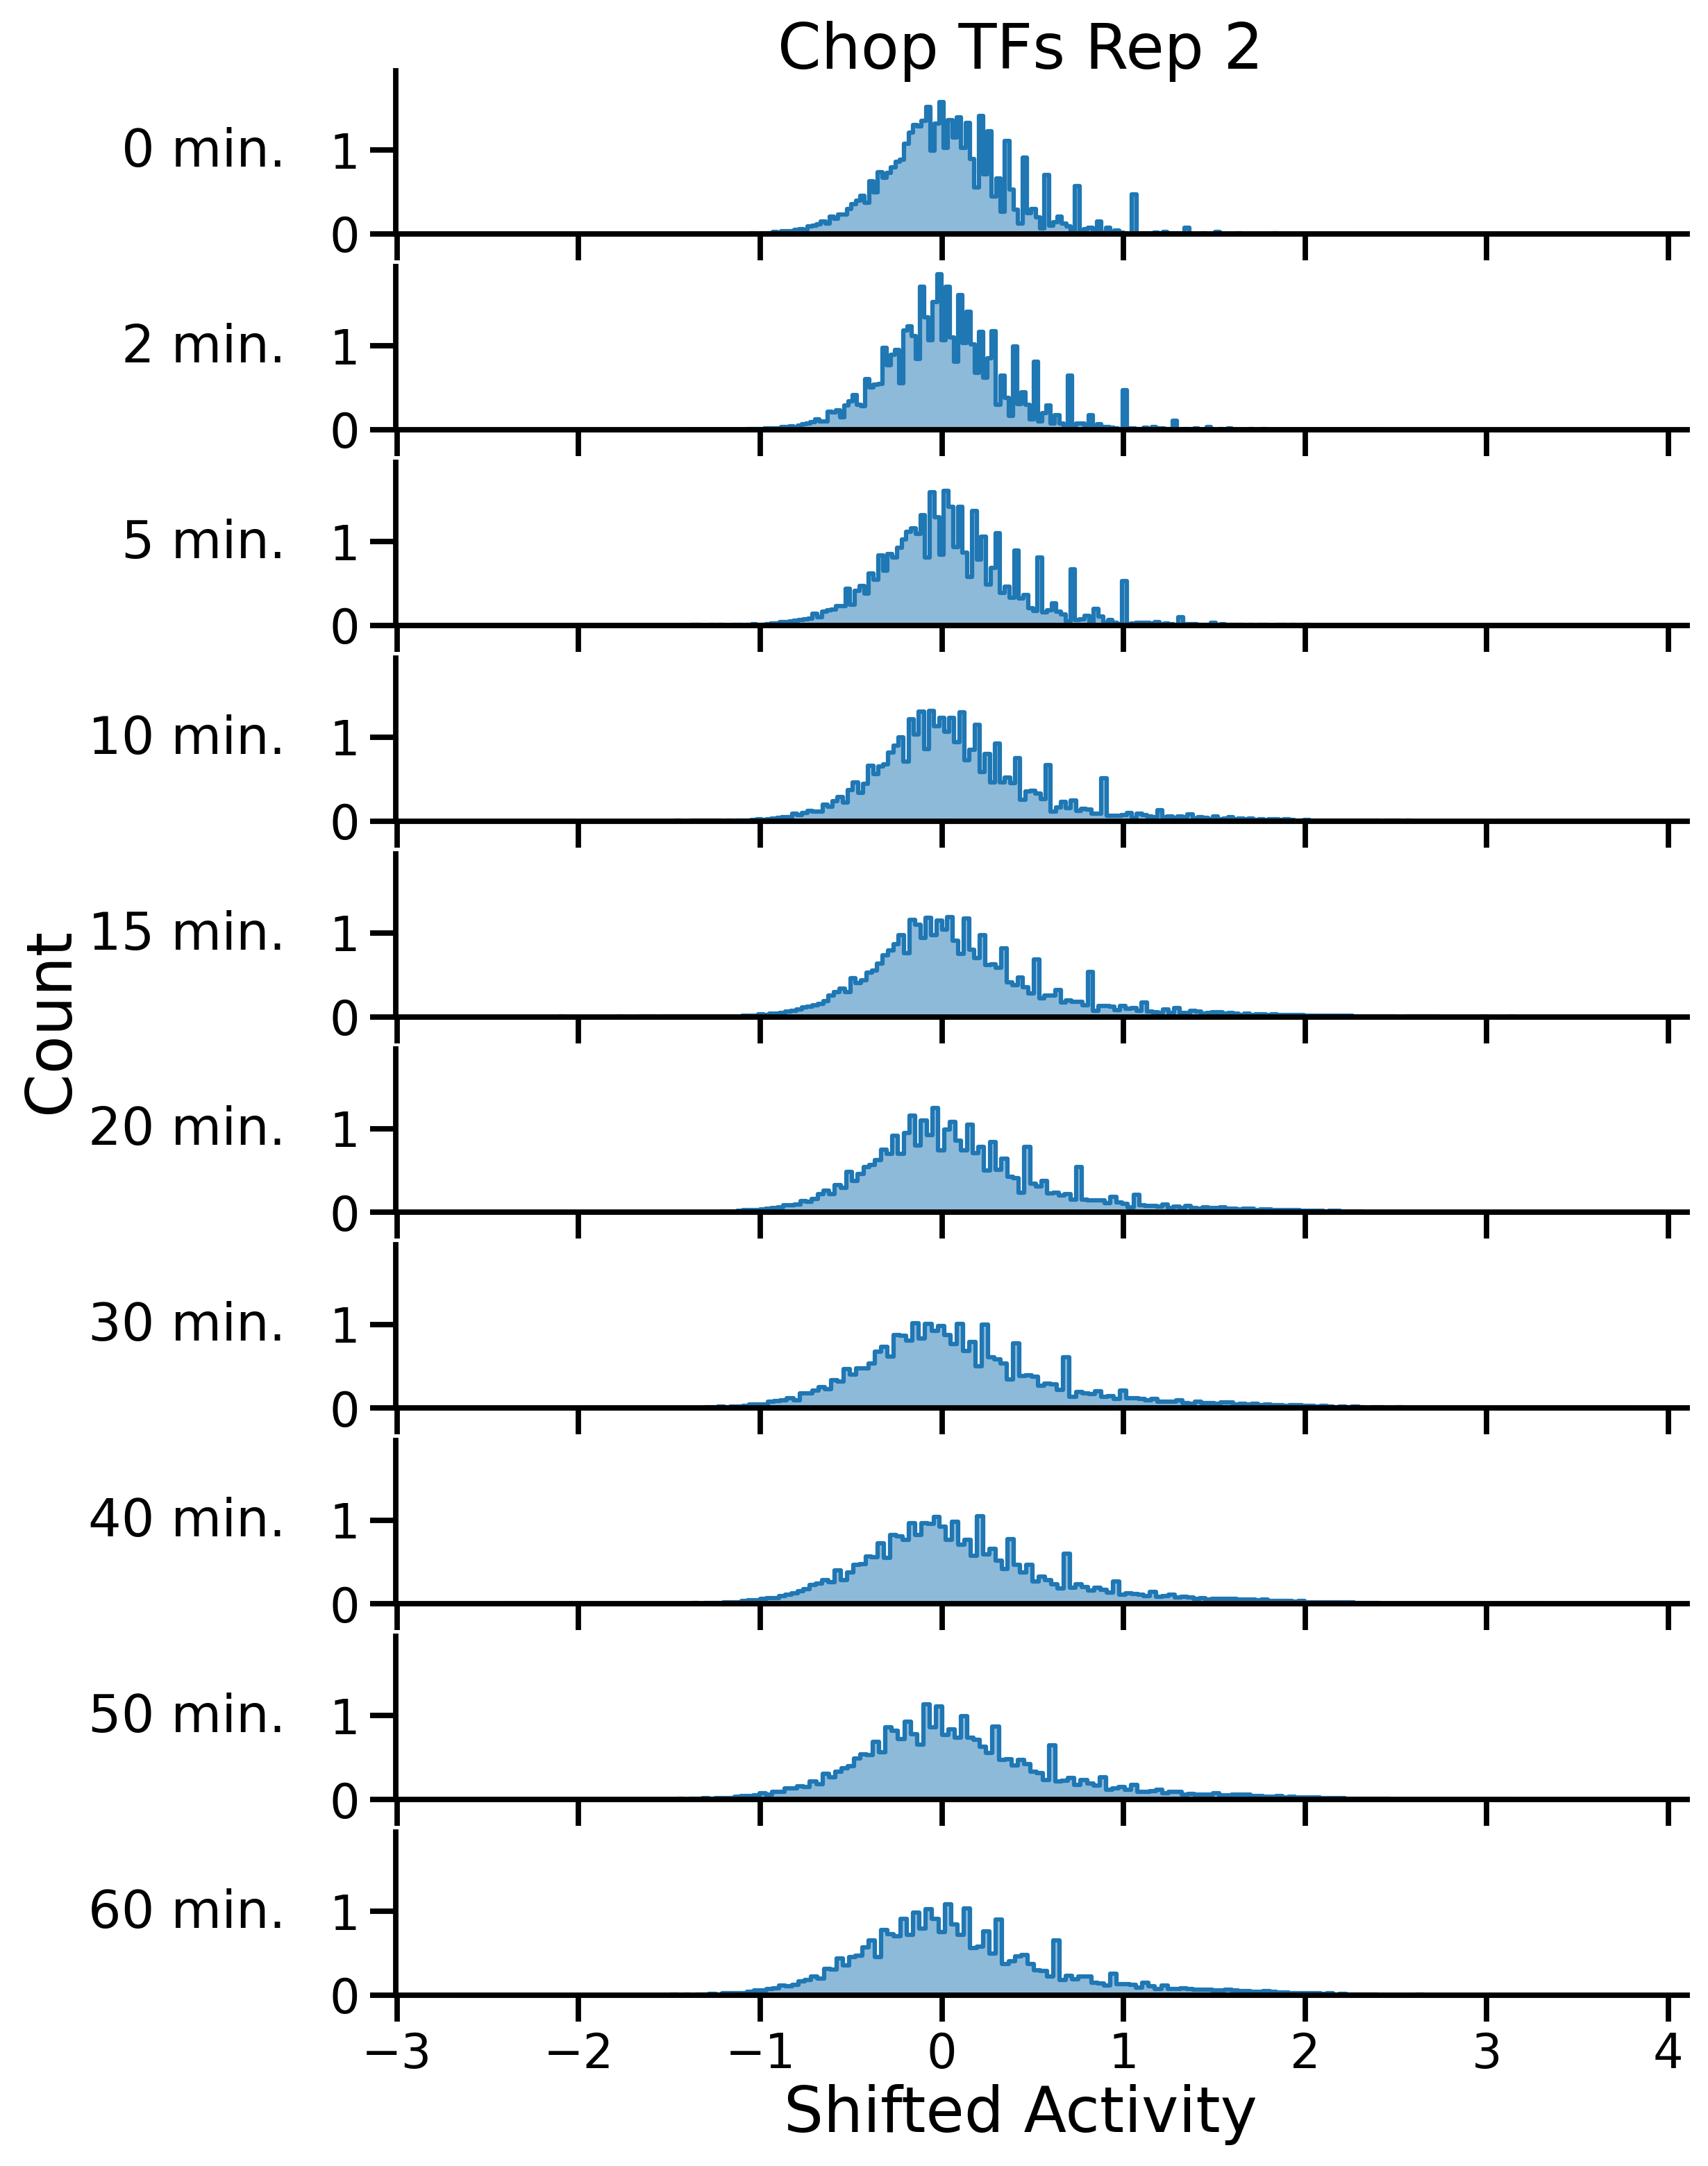

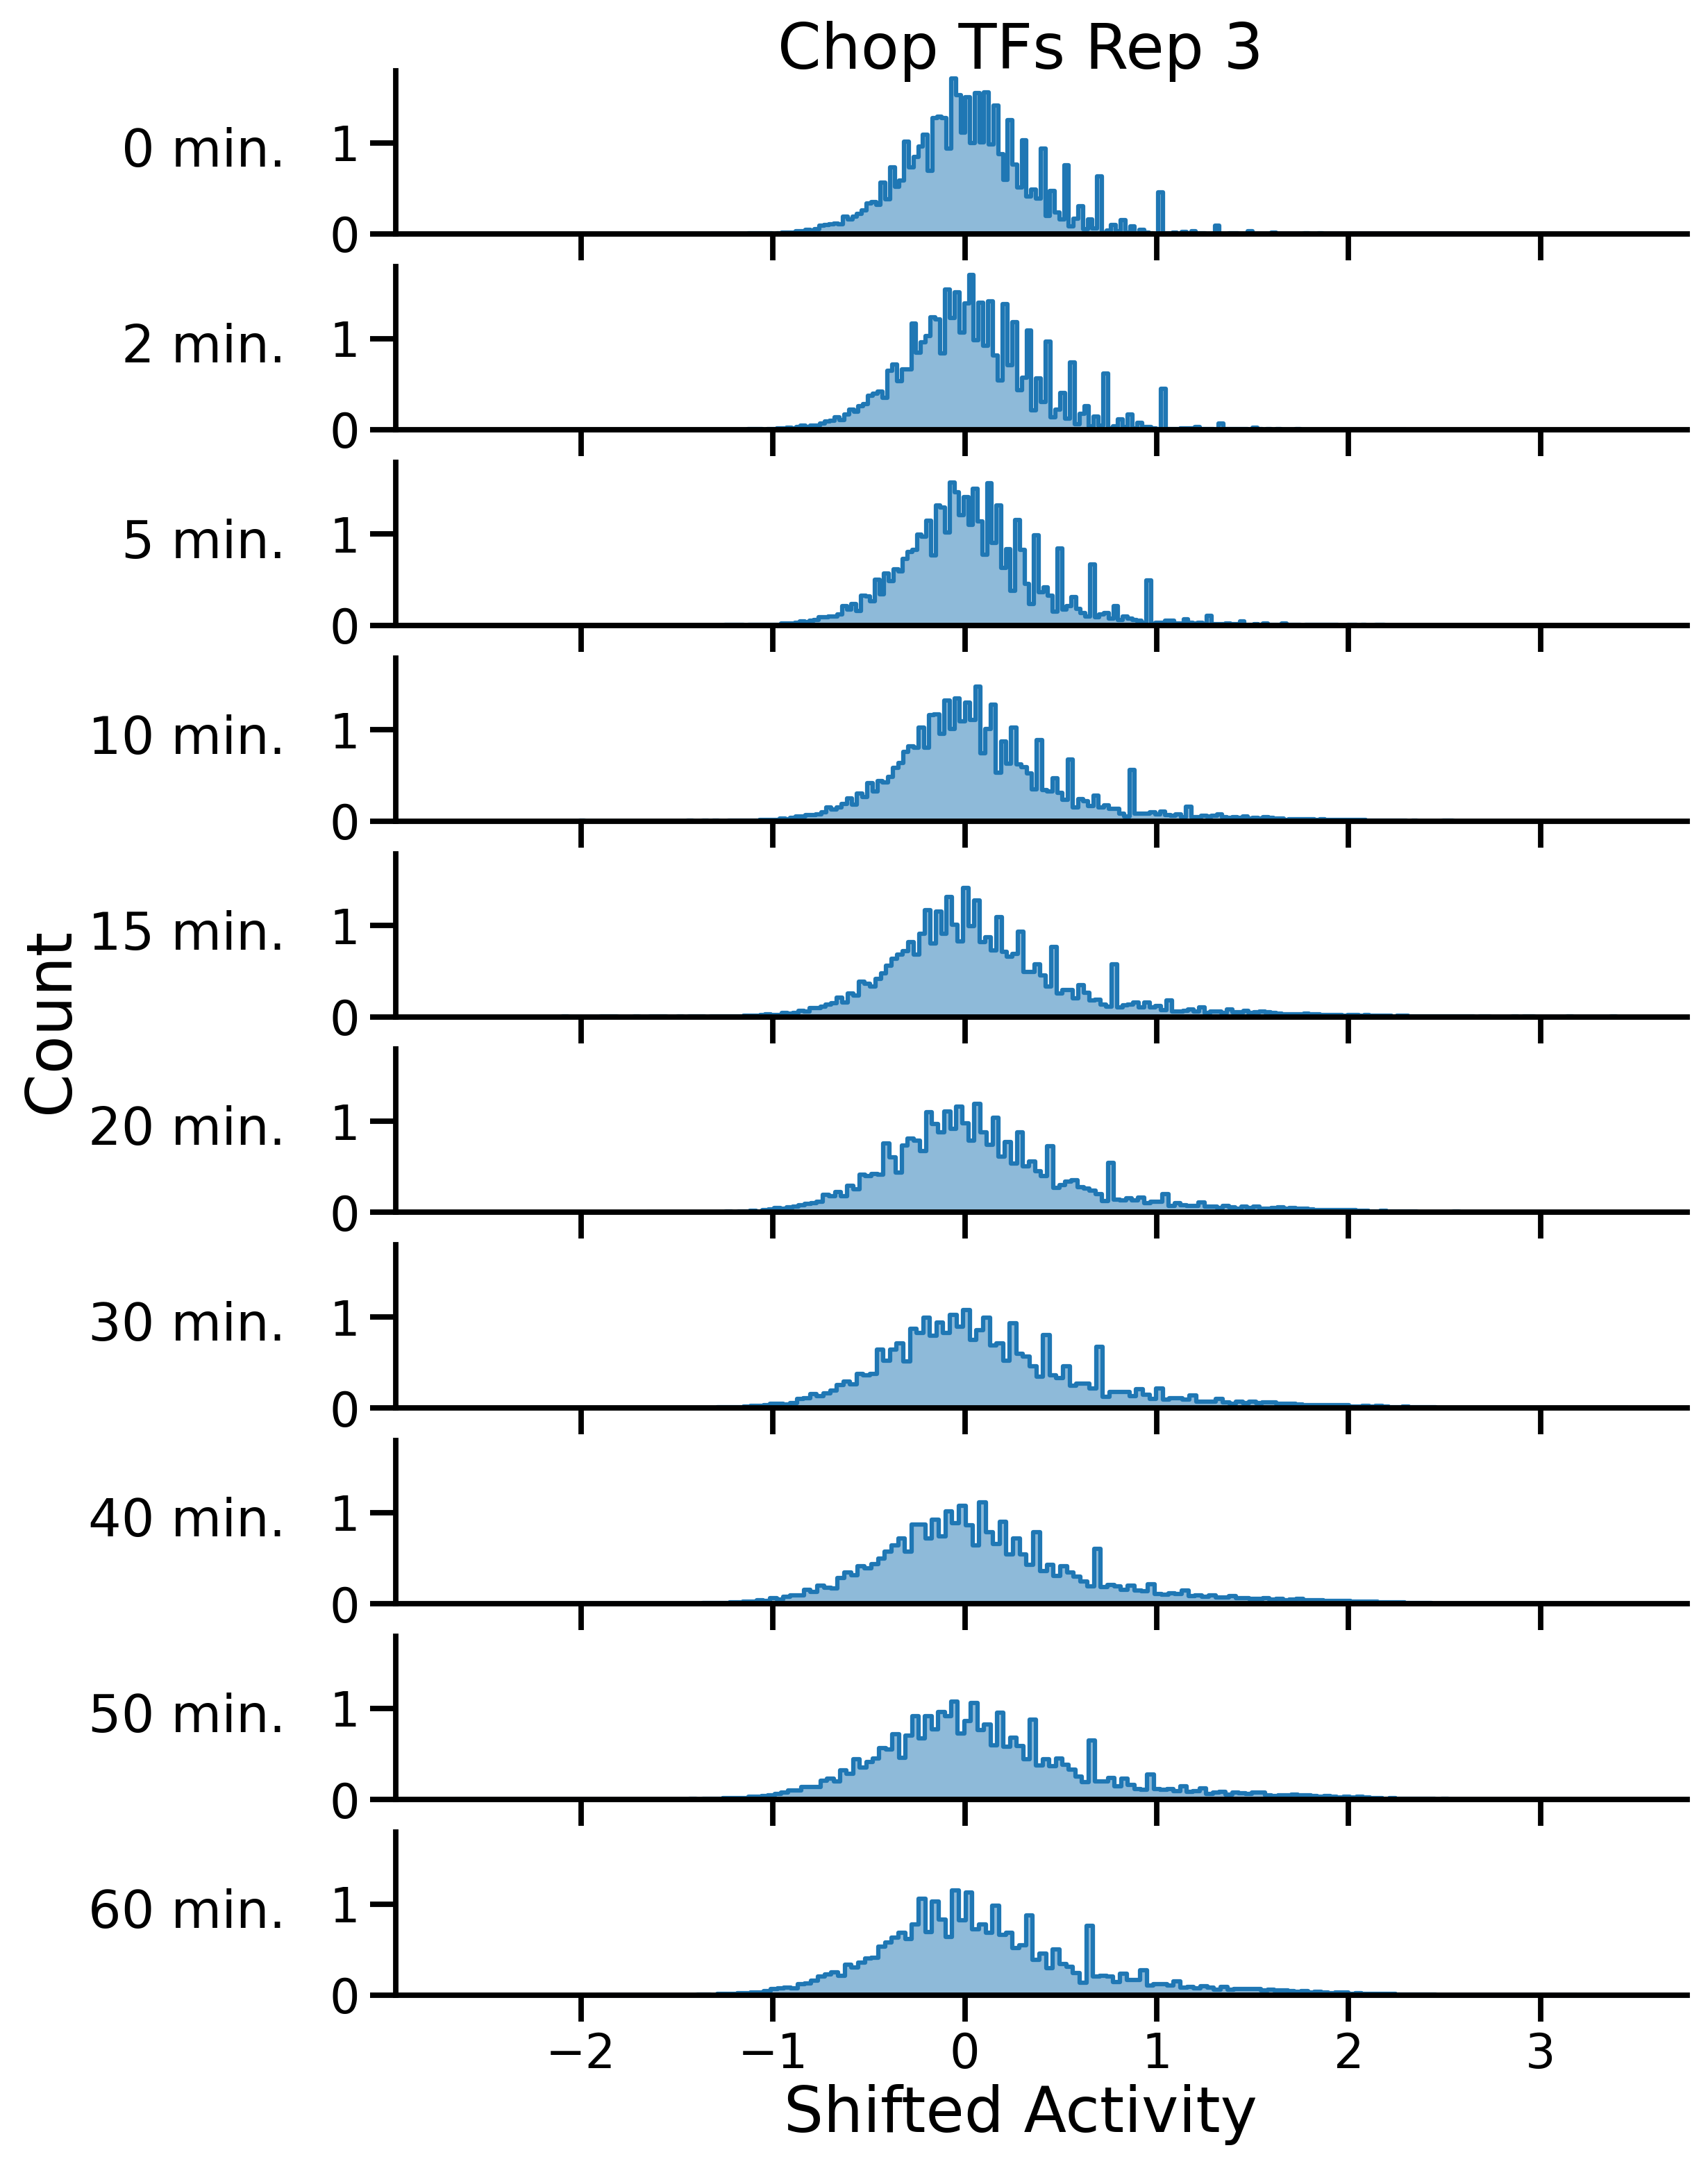

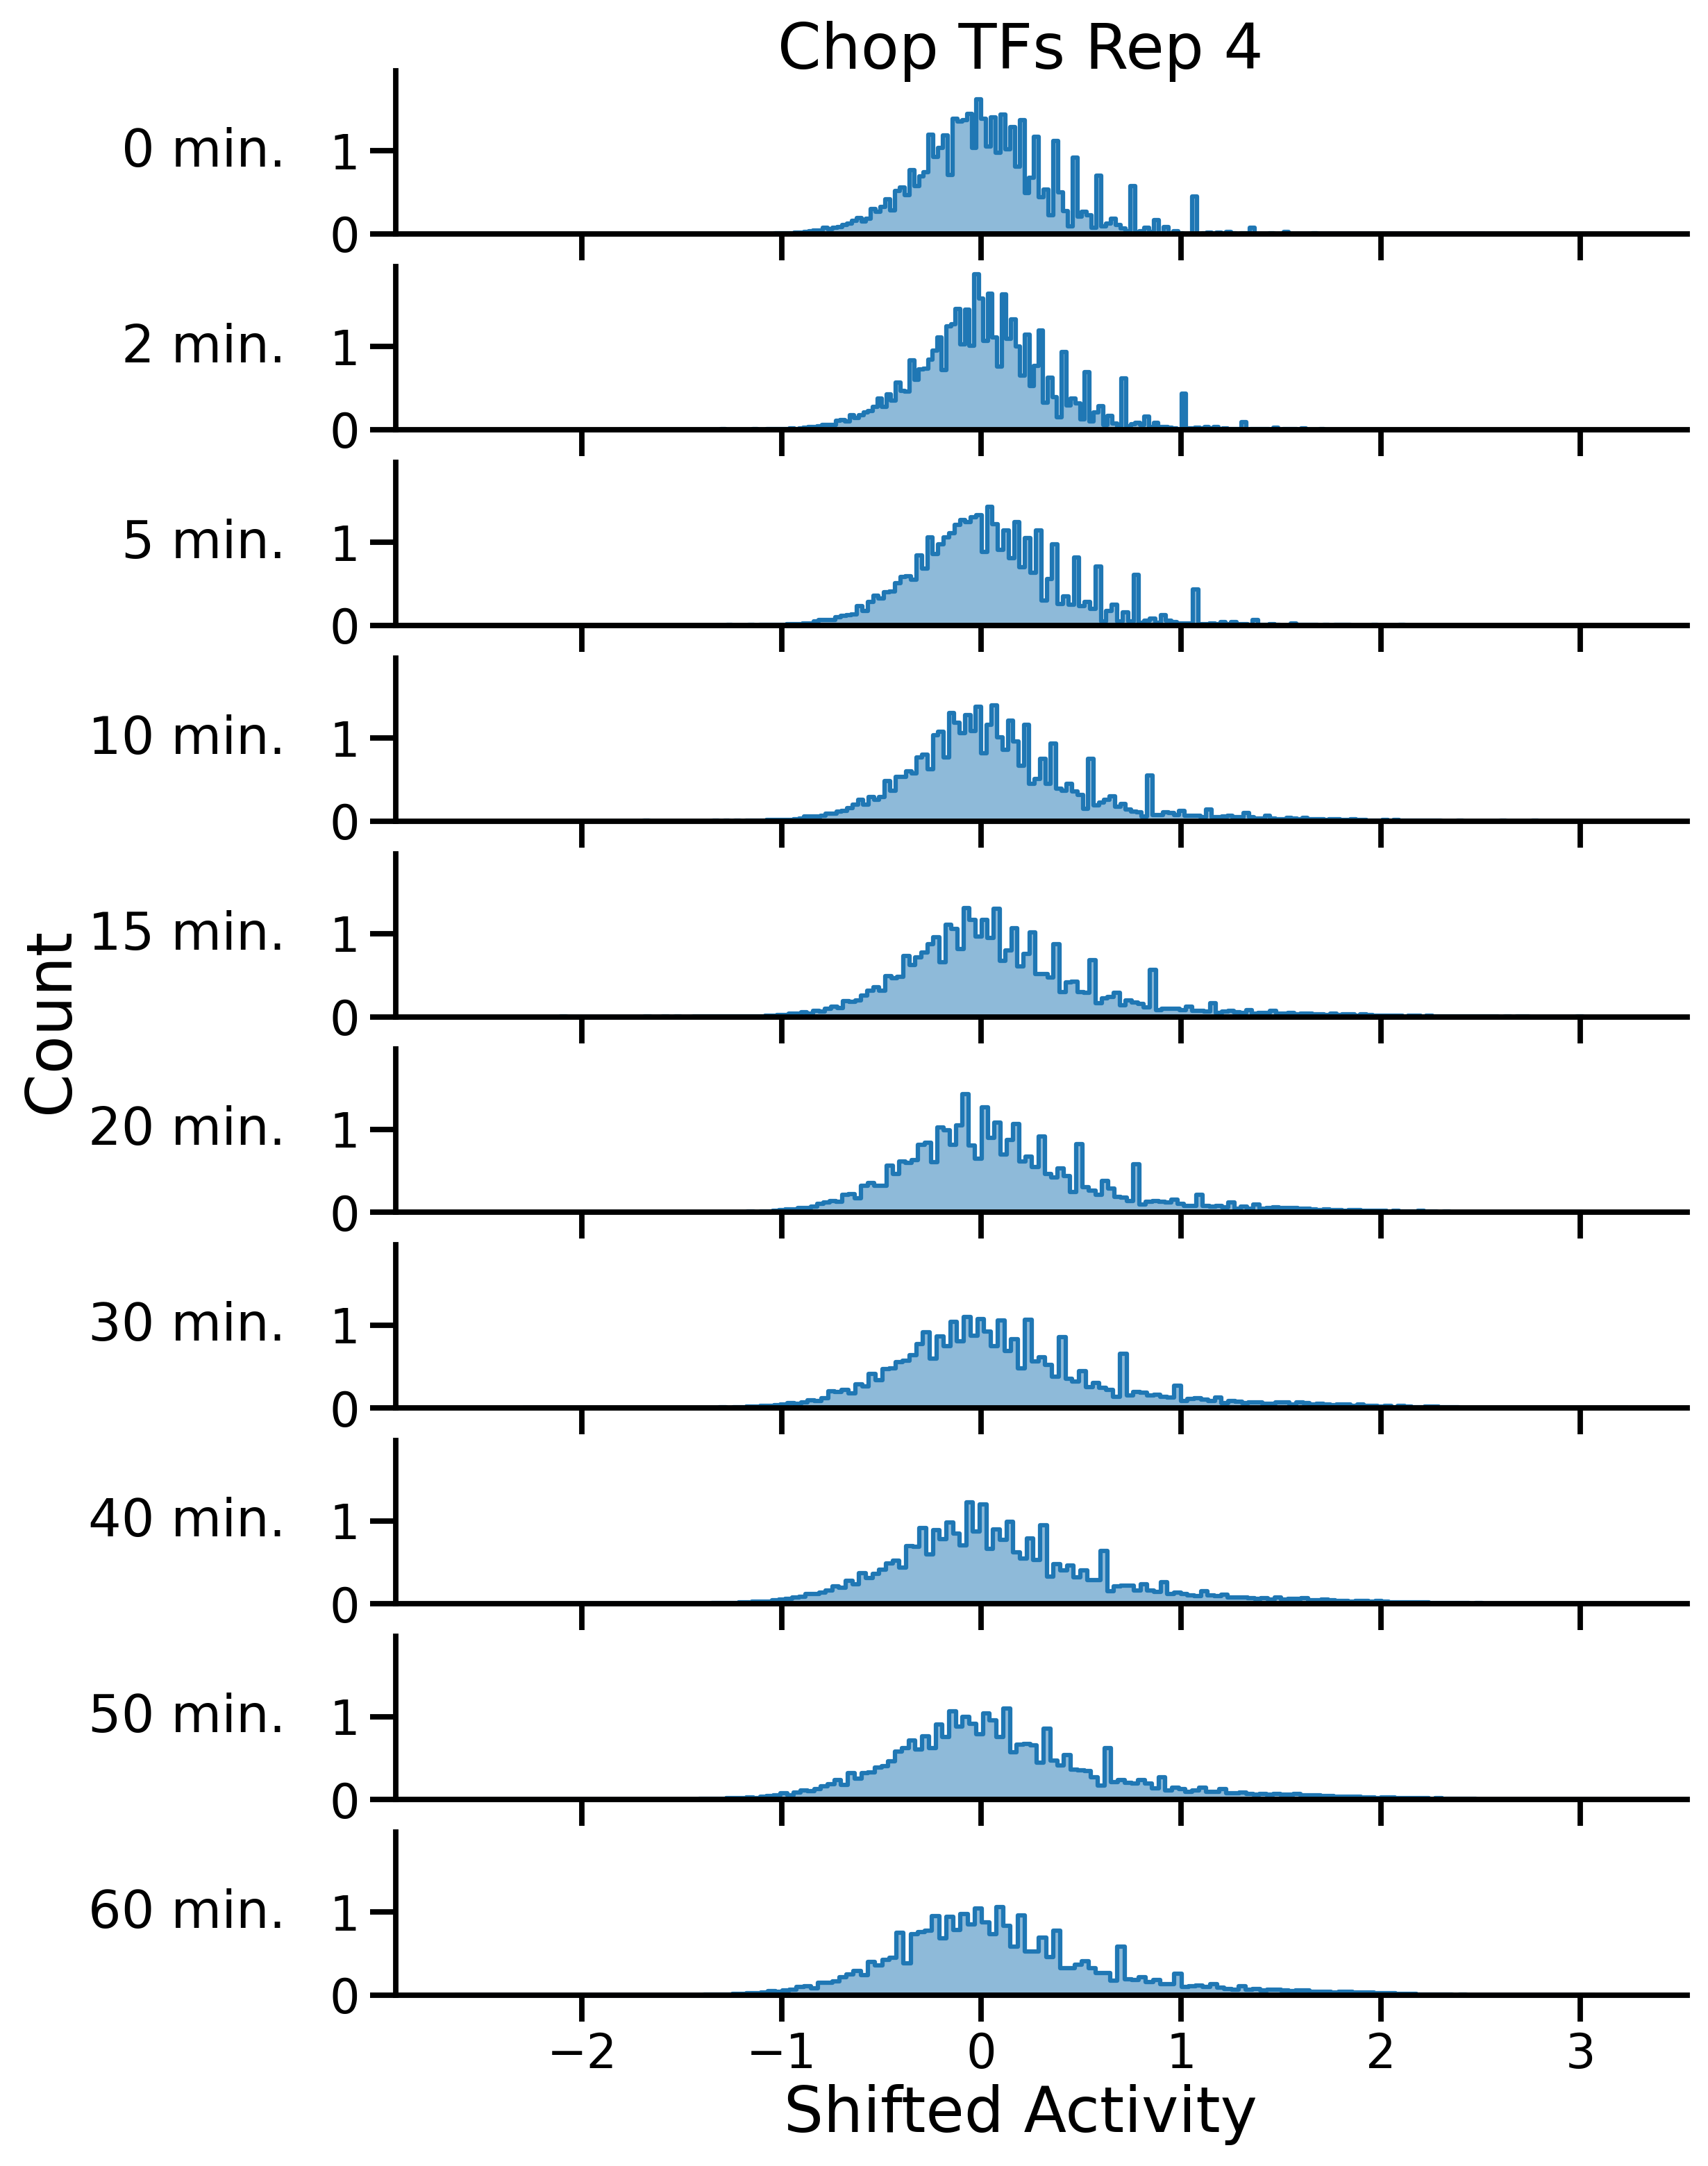

In [29]:
fig, axs = time_normalization_helpers.plot_hists_over_time(all_activities[all_activities["rep"] == 2], "shifted_activity", xlabel = "Shifted Activity")
fig.suptitle("Chop TFs Rep 2", y = 0.9)

fig, axs = time_normalization_helpers.plot_hists_over_time(all_activities[all_activities["rep"] == 3], "shifted_activity", xlabel = "Shifted Activity")
fig.suptitle("Chop TFs Rep 3", y = 0.9)

fig, axs = time_normalization_helpers.plot_hists_over_time(all_activities[all_activities["rep"] == 4], "shifted_activity", xlabel = "Shifted Activity")
fig.suptitle("Chop TFs Rep 4", y = 0.9)

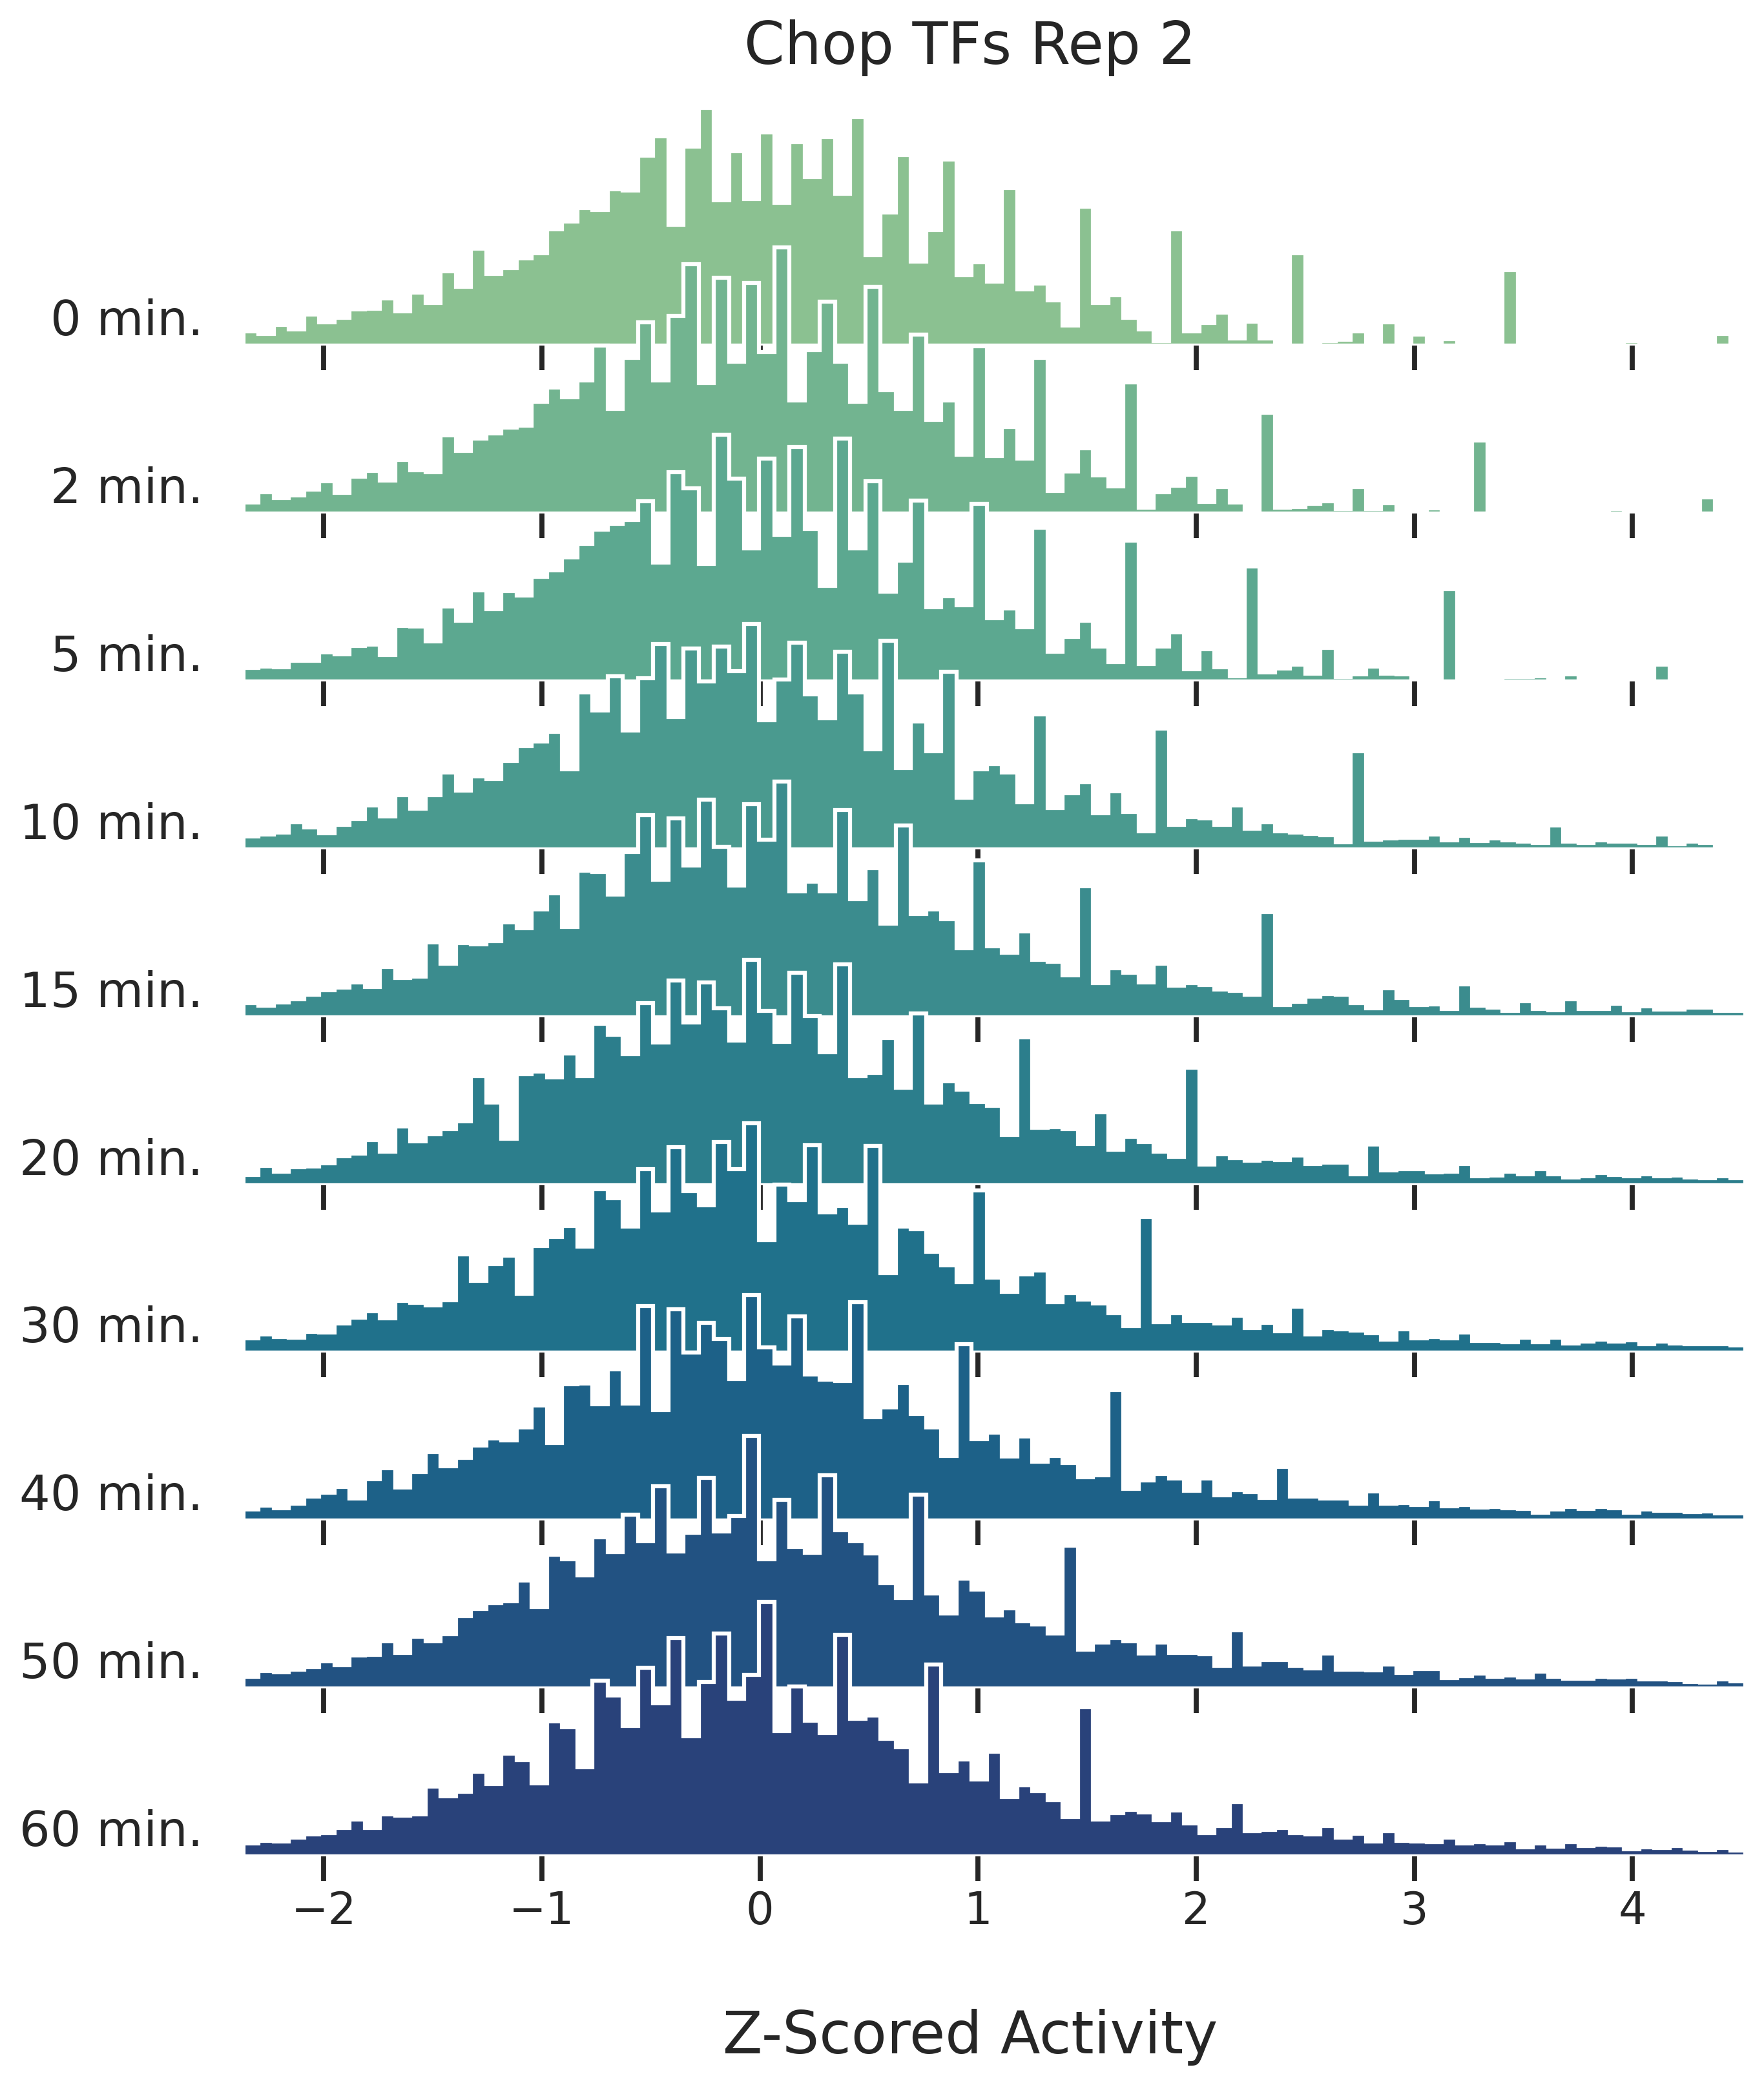

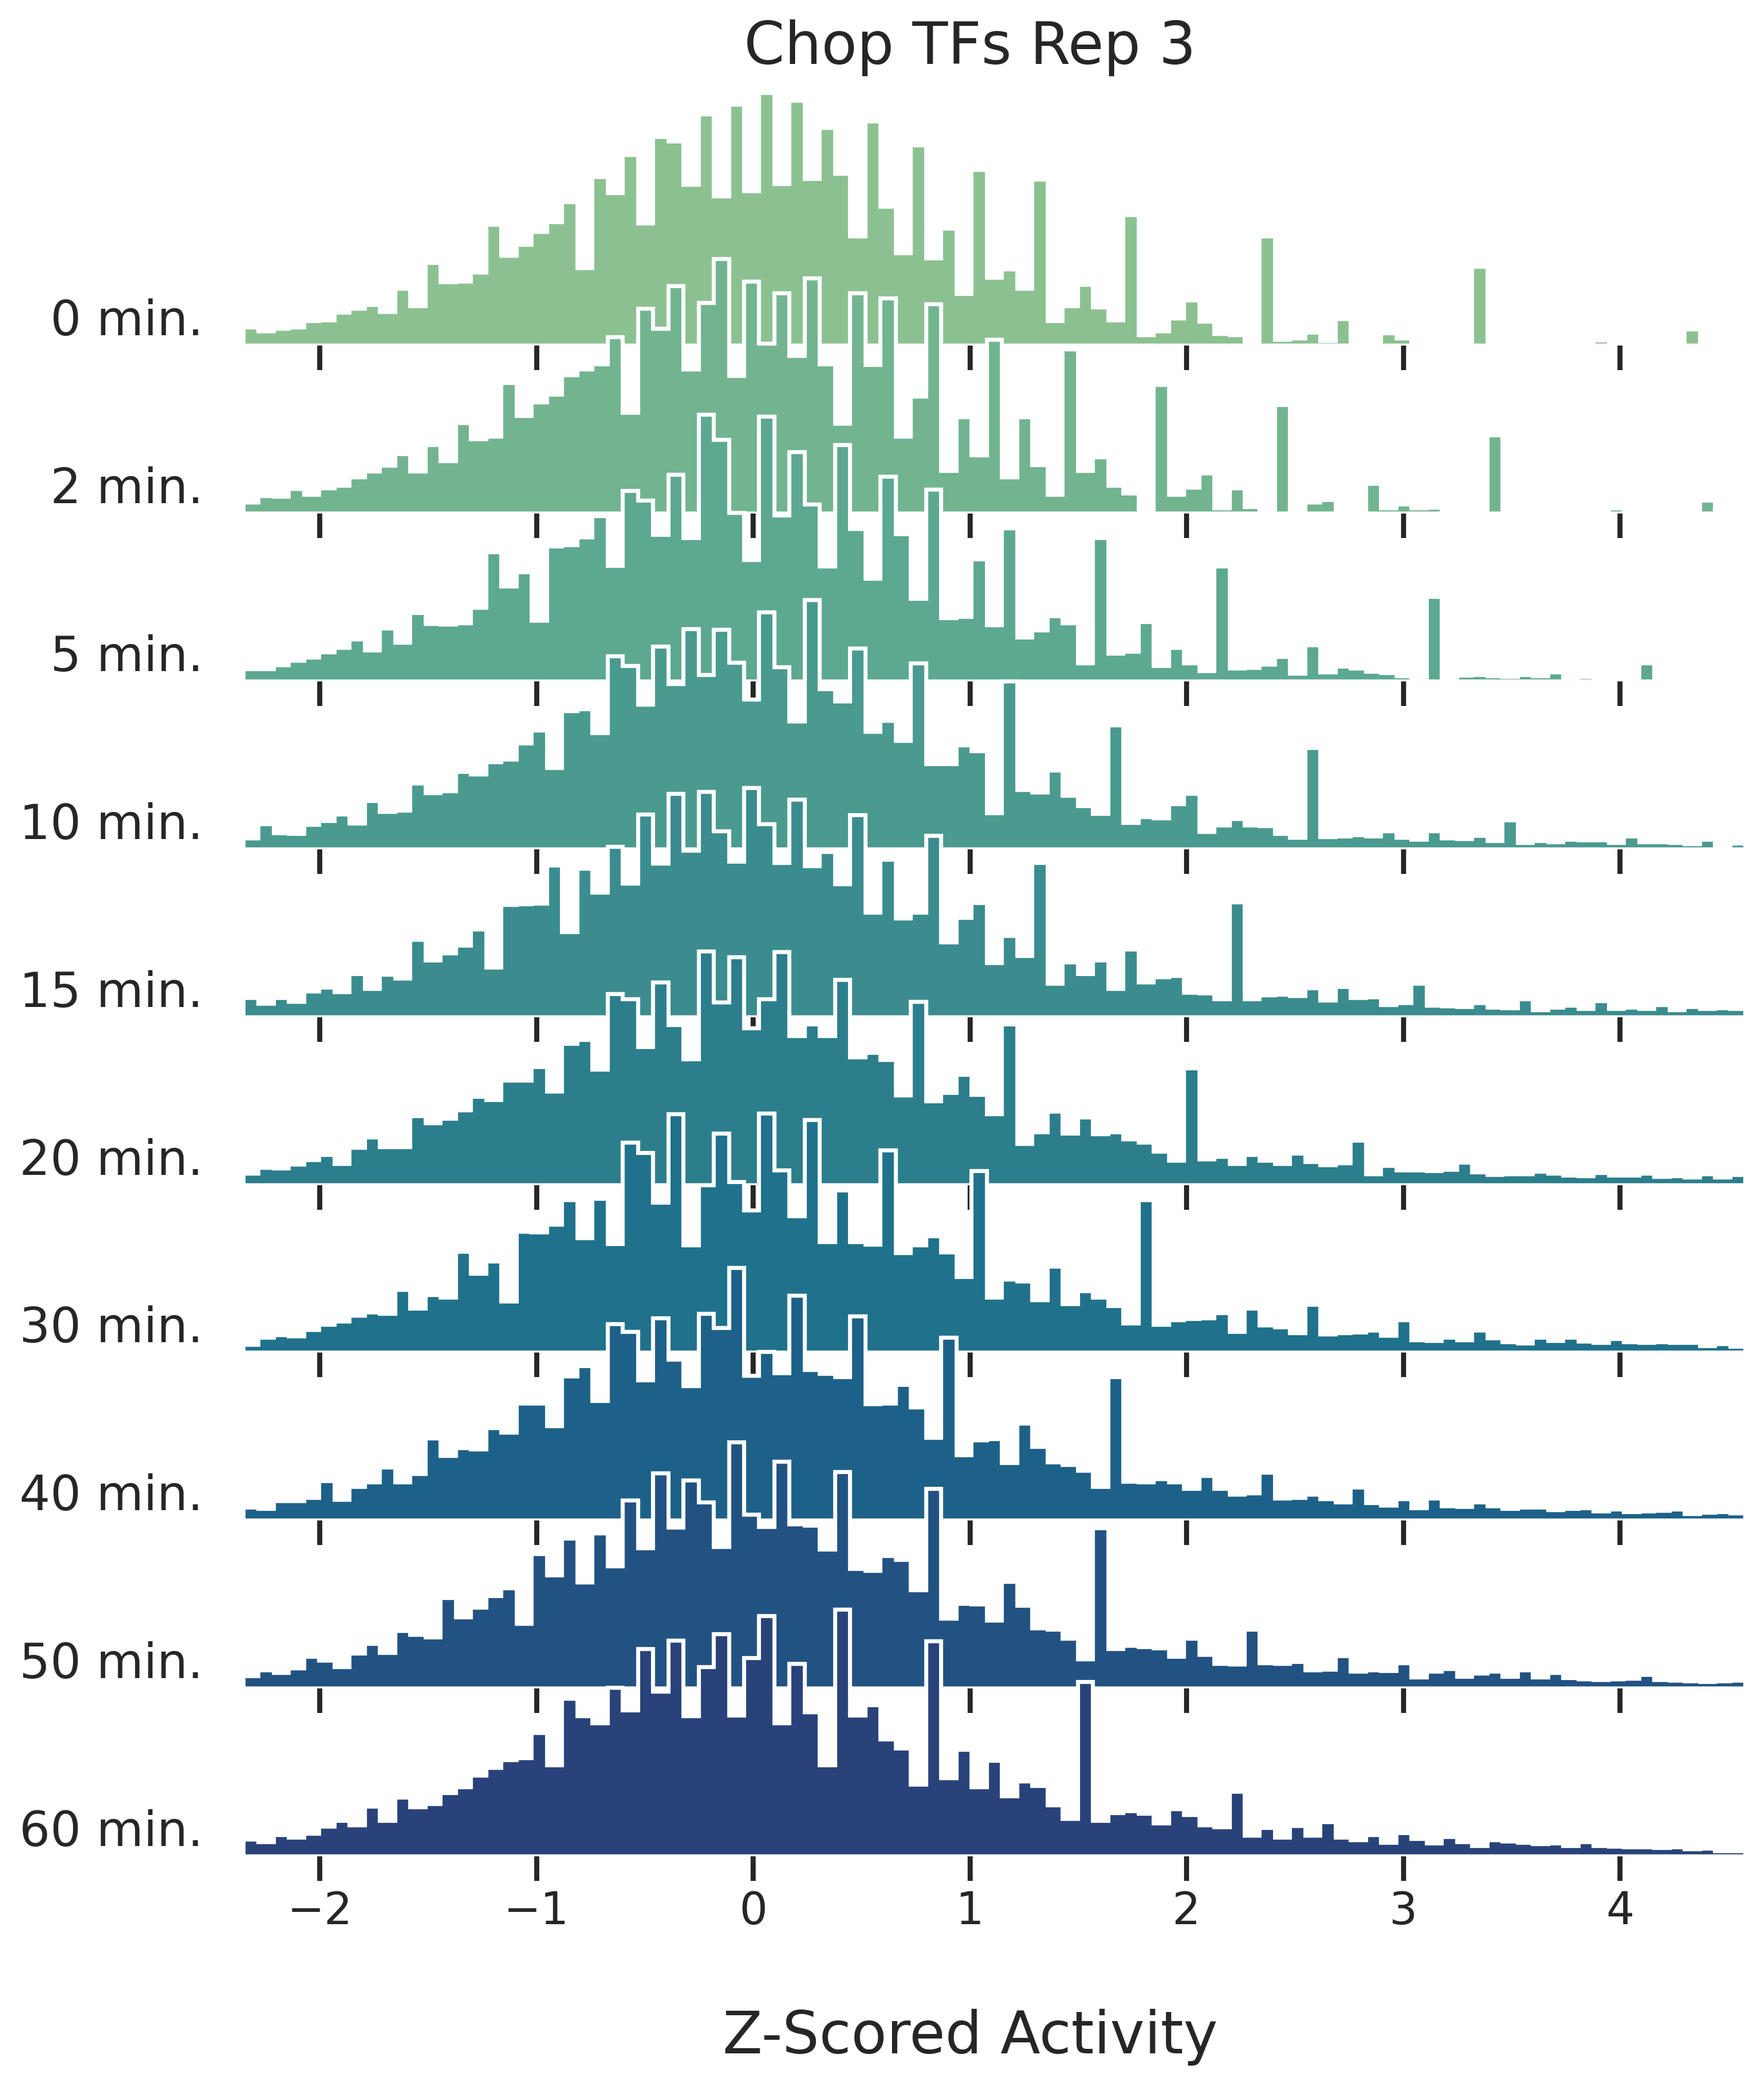

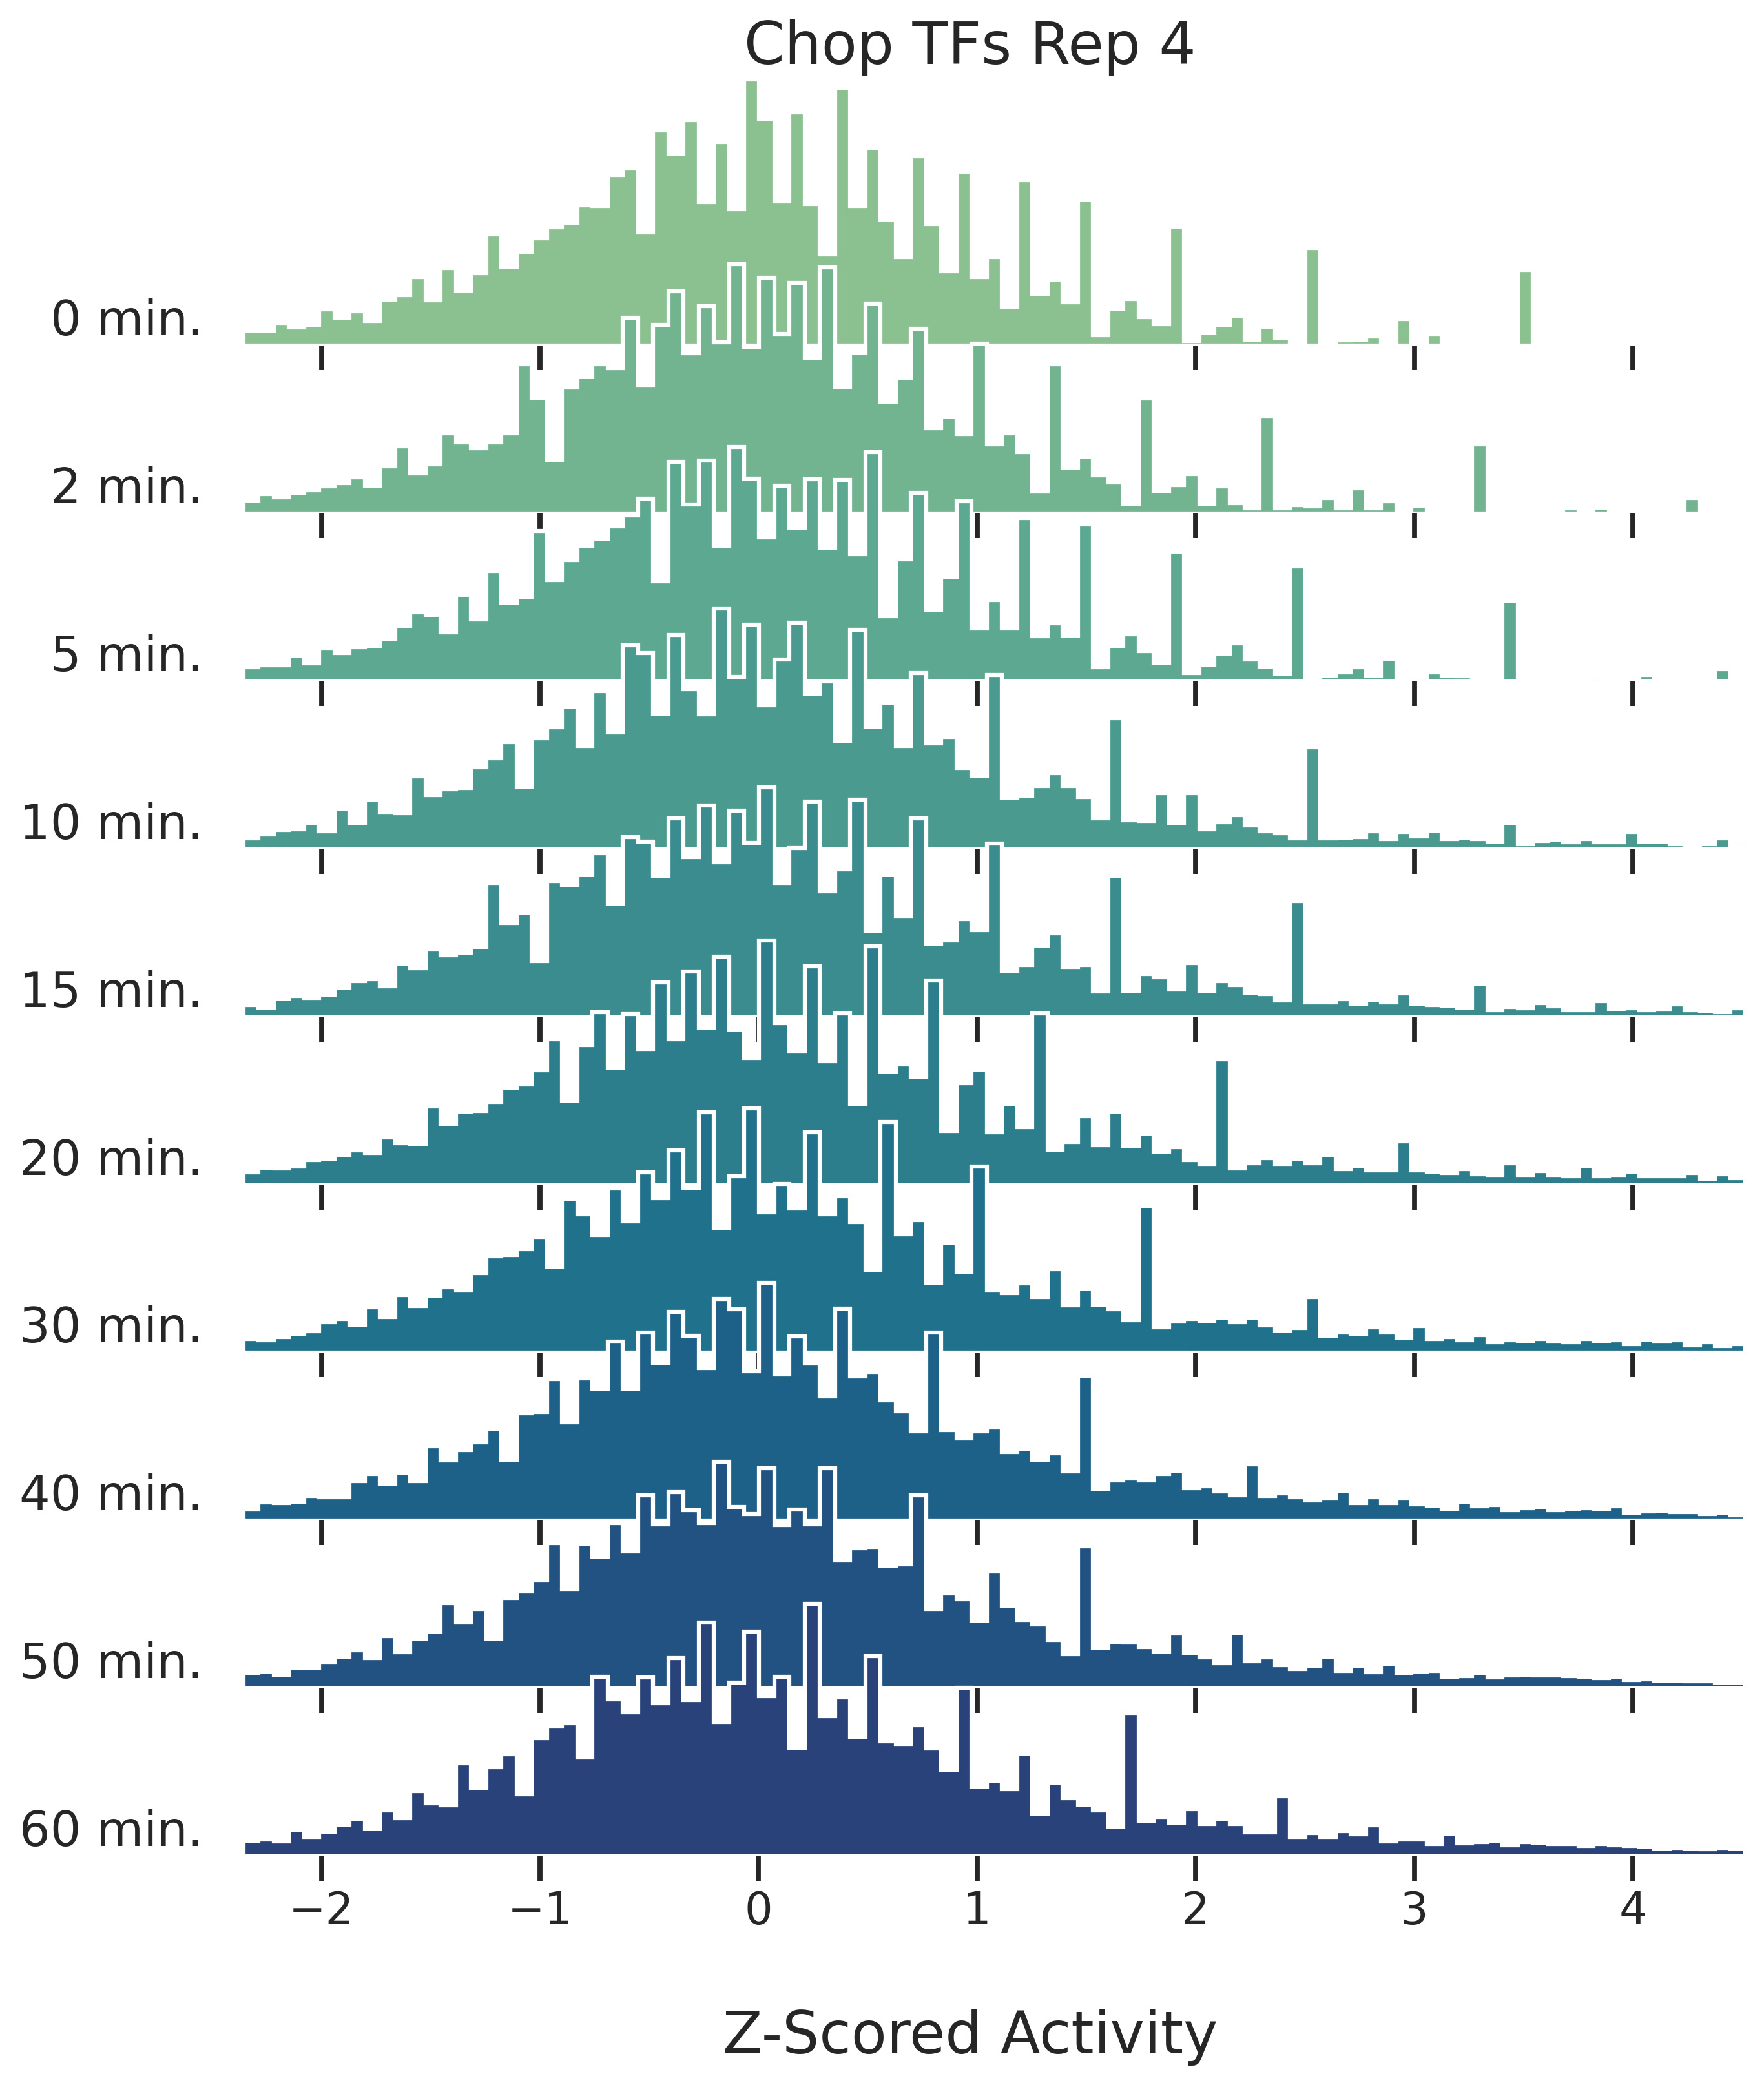

In [30]:
sns.set_style('ticks')
fig, axs = time_normalization_helpers.plot_ridge(all_activities[all_activities["rep"] == 2], "z-scored_activity", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 2", y = 0.9)
sns.despine(bottom = True, left = True)

sns.set_style('ticks')
fig, axs = time_normalization_helpers.plot_ridge(all_activities[all_activities["rep"] == 3], "z-scored_activity", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 3", y = 0.9)
sns.despine(bottom = True, left = True)

sns.set_style('ticks')
fig, axs = time_normalization_helpers.plot_ridge(all_activities[all_activities["rep"] == 4], "z-scored_activity", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 4", y = 0.9)
sns.despine(bottom = True, left = True)

In [31]:
all_activities_per_AD = all_activities.groupby(["seq", "rep", "time"])[["score", "z-scored_activity", "shifted_activity"]].agg([np.mean, np.std]).reset_index()
all_activities_per_AD.columns = ["seq", "rep", "time", "raw_mean", "raw_std", "z-scored_mean", "z-scored_std", "shifted_mean", "shifted_std"]
all_activities_per_AD

,seq,rep,time,raw_mean,raw_std,z-scored_mean,z-scored_std,shifted_mean,shifted_std
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,2,15,0.602060,NaN,4.062220,NaN,1.426822,NaN
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,3,30,0.000000,NaN,1.823176,NaN,0.717498,NaN
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,-0.899670,0.077177,0.487678,0.253982,0.148189,0.077177
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,-0.738533,0.244102,0.856079,0.816607,0.255901,0.244102
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,-0.542113,0.321389,1.482991,1.011641,0.471133,0.321389
...,...,...,...,...,...,...,...,...,...
472407,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,20,-0.954243,NaN,-0.467328,NaN,-0.172105,NaN
472408,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,30,-1.141674,NaN,-1.139532,NaN,-0.445301,NaN
472409,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,40,-1.083682,NaN,-1.108105,NaN,-0.457936,NaN
472410,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,50,-1.063387,NaN,-1.052102,NaN,-0.444827,NaN


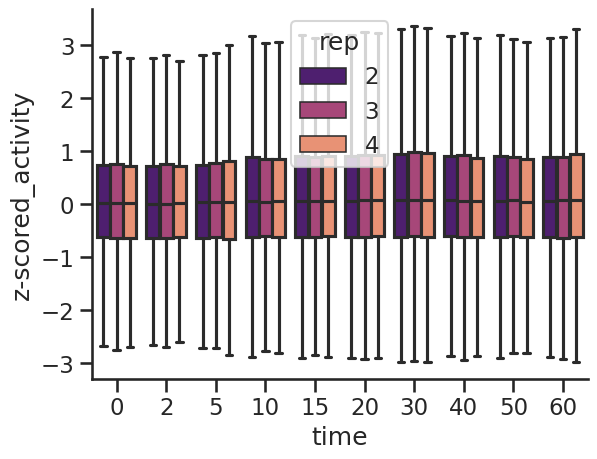

In [32]:
# How does z-score change over time?
sns.boxplot(data=all_activities, x="time", y="z-scored_activity", hue="rep", showfliers = False, palette = 'magma')
sns.despine()

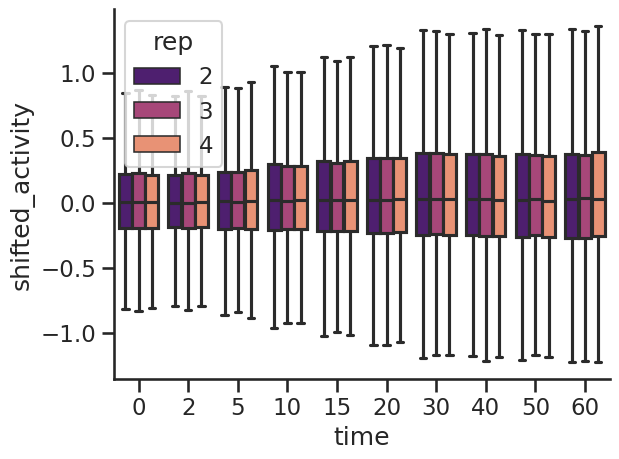

In [33]:
# How does z-score change over time?
sns.boxplot(data=all_activities, x="time", y="shifted_activity", hue="rep", showfliers = False, palette = 'magma')
sns.despine()

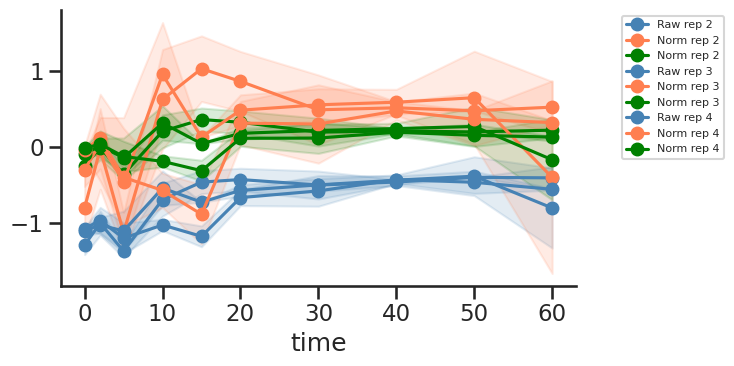

In [34]:
linestyles = ['-', '--', '-.', ':']
raw_color = "steelblue"
norm_color = "coral"

fig, ax = plt.subplots(figsize=(8, 4))

one_AD_normalized = all_activities_per_AD[all_activities_per_AD["seq"] == "KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ"].copy()
one_AD_normalized["time"] = one_AD_normalized["time"].astype(int)

for rep, group in one_AD_normalized.groupby("rep"):
    group = group.sort_values("time")
    ls = linestyles[rep % len(linestyles)]

    ax.plot(group["time"], group["raw_mean"], marker='o', color=raw_color, label=f"Raw rep {rep}")
    ax.fill_between(group["time"],
                    group["raw_mean"] - group["raw_std"],
                    group["raw_mean"] + group["raw_std"],
                    alpha=0.15, color=raw_color)

    ax.plot(group["time"], group["z-scored_mean"], marker='o', color=norm_color, label=f"Norm rep {rep}")
    ax.fill_between(group["time"],
                    group["z-scored_mean"] - group["z-scored_std"],
                    group["z-scored_mean"] + group["z-scored_std"],
                    alpha=0.15, color=norm_color)

    ax.plot(group["time"], group["shifted_mean"], marker='o', color='green', label=f"Norm rep {rep}")
    ax.fill_between(group["time"],
                    group["shifted_mean"] - group["shifted_std"],
                    group["shifted_mean"] + group["shifted_std"],
                    alpha=0.15, color='green')

ax.set_xlabel("time")
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

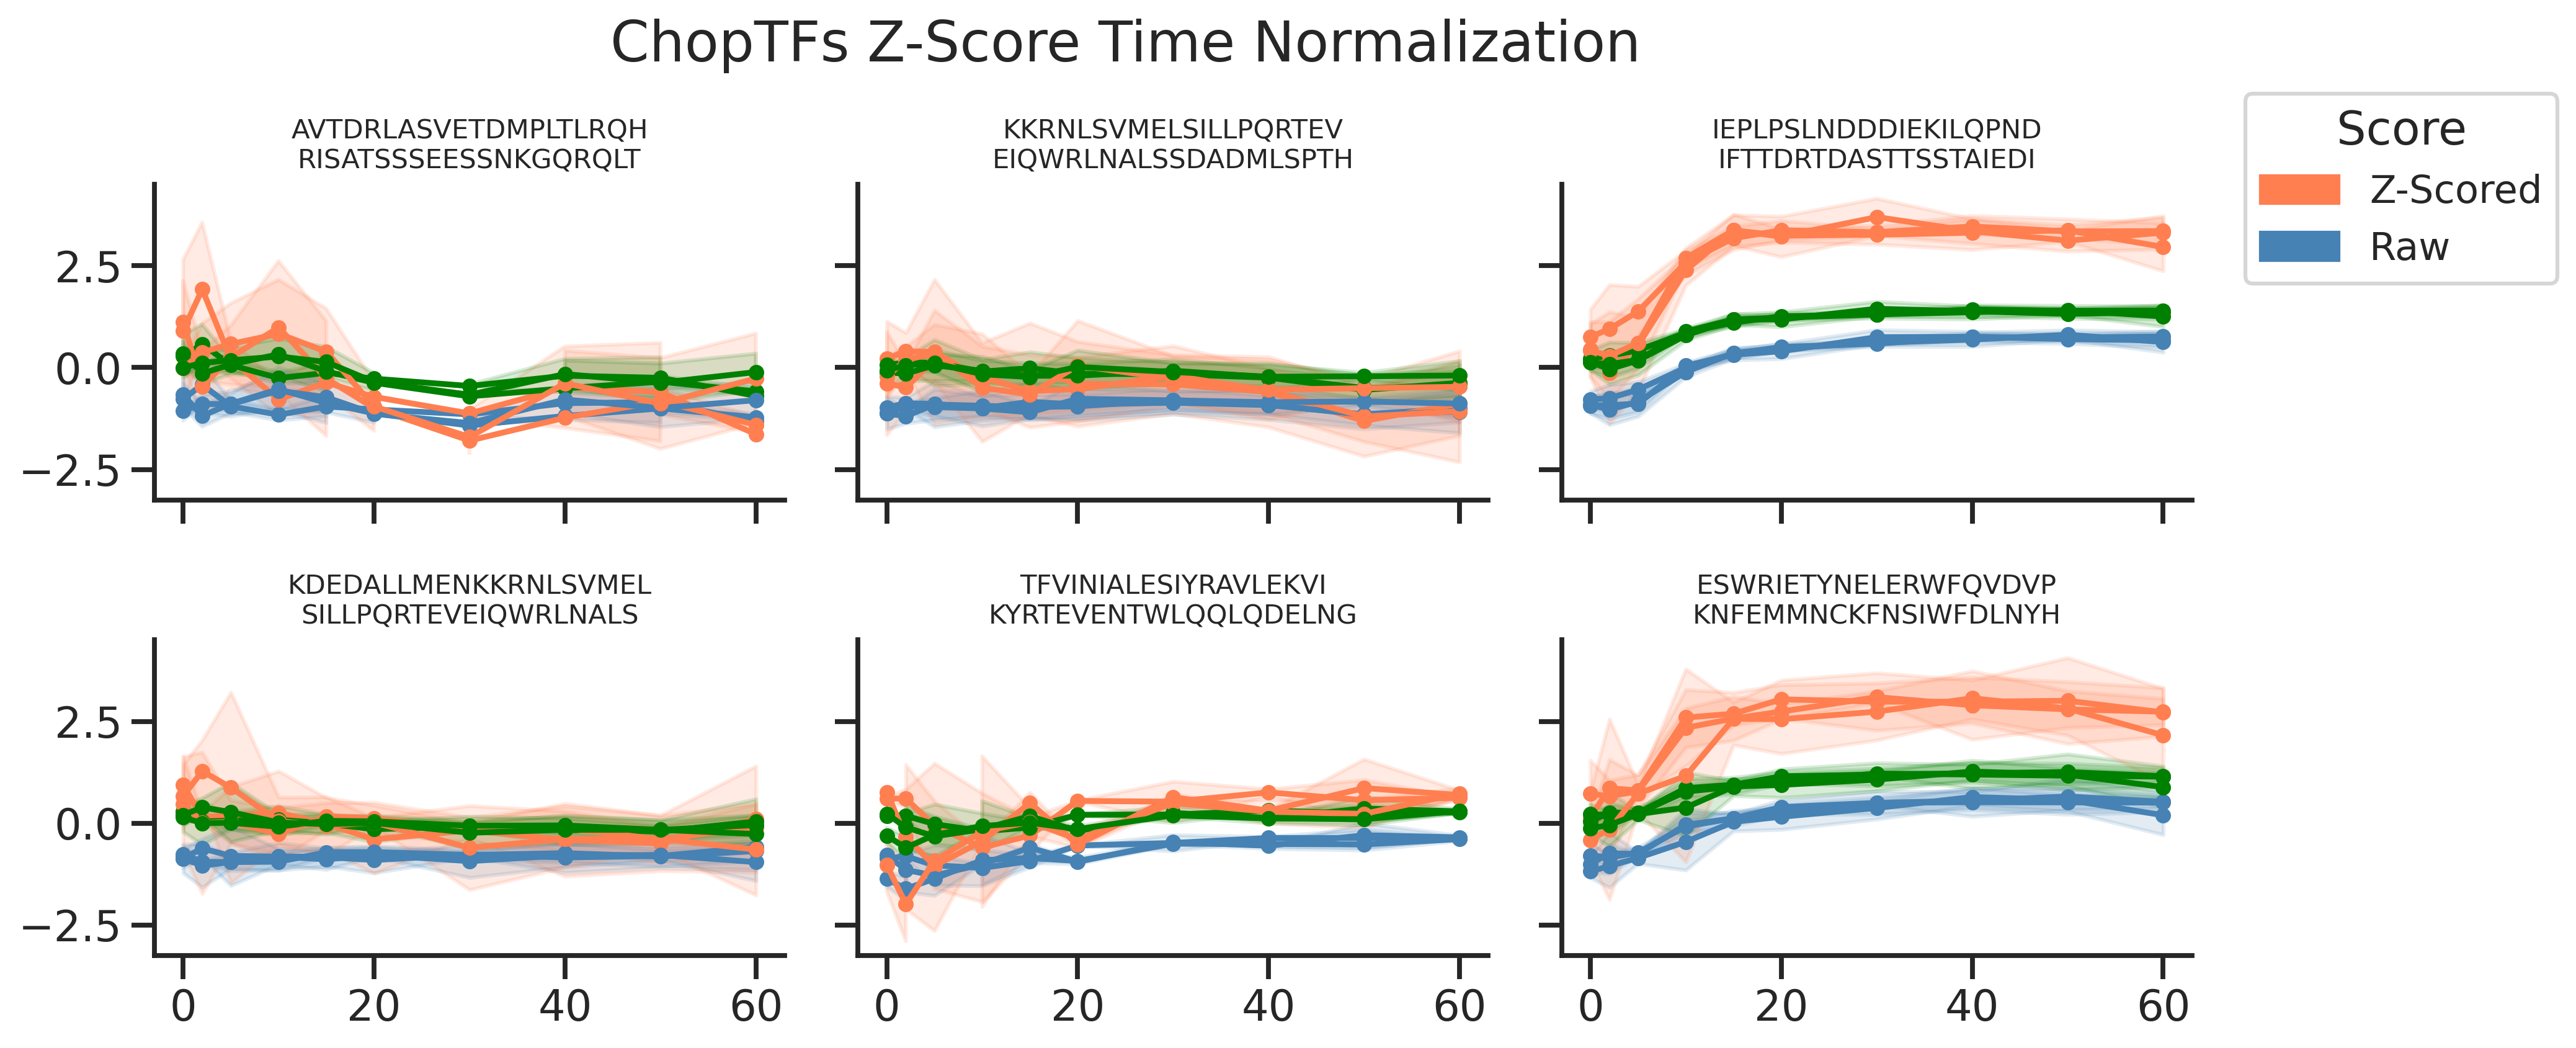

In [35]:
from matplotlib.patches import Patch

pythonlinestyles = ['-', '--', '-.', ':']
raw_color = "steelblue"
norm_color = "coral"

sampled_ADs = pd.Series(all_activities_per_AD.dropna()["seq"].unique()).sample(6, random_state=7)
ncols = 3
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3),sharex = True, sharey = True, dpi = 300)
axes = axes.flatten()

for i, AD in enumerate(sampled_ADs):
    ax = axes[i]
    one_AD_normalized = all_activities_per_AD[all_activities_per_AD["seq"] == AD].copy()
    one_AD_normalized["time"] = one_AD_normalized["time"].astype(int)

    for rep, group in one_AD_normalized.groupby("rep"):
        group = group.sort_values("time")
        ls = linestyles[rep % len(linestyles)]

        ax.plot(group["time"], group["raw_mean"], marker='o', color=raw_color, markersize = 5)
        ax.fill_between(group["time"],
                        group["raw_mean"] - group["raw_std"],
                        group["raw_mean"] + group["raw_std"],
                        alpha=0.15, color=raw_color)

        ax.plot(group["time"], group["z-scored_mean"], marker='o', color=norm_color, markersize = 5)
        ax.fill_between(group["time"],
                        group["z-scored_mean"] - group["z-scored_std"],
                        group["z-scored_mean"] + group["z-scored_std"],
                        alpha=0.15, color=norm_color)

        ax.plot(group["time"], group["shifted_mean"], marker='o', color='green', markersize = 5)
        ax.fill_between(group["time"],
                        group["shifted_mean"] - group["shifted_std"],
                        group["shifted_mean"] + group["shifted_std"],
                        alpha=0.15, color='green')

    ax.set_title(AD[:20] + "\n" + AD[20:], fontsize='xx-small')
    #ax.set_xlabel("time", fontsize=8)
    sns.despine(ax=ax)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

legend_handles = [
    Patch(color=norm_color, label="Z-Scored"),
    Patch(color=raw_color, label="Raw"),
]
fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 0.9), fontsize='small', title = "Score")
fig.suptitle("ChopTFs Z-Score Time Normalization", y = 0.95)

plt.tight_layout()
plt.show()

# How do mu and sigma change over time across reps?

In [36]:
all_activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/full_data_time_normalized_activities.csv", index_col = 0)
all_activities

,seq,AD_BC,score,rep,time,z-scored_activity,shifted_activity,mu,sigma
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.201645,2,0,-0.506097,-0.153786,-1.047859,0.303867
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TATCTTCGCTT,-1.380211,2,0,-1.093743,-0.332352,-1.047859,0.303867
2,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCGTACCGA,-1.447158,2,0,-1.314059,-0.399299,-1.047859,0.303867
3,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTGCATAGCTG,-1.799341,2,0,-2.473062,-0.751481,-1.047859,0.303867
4,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTTATAATACC,-1.124939,2,0,-0.253662,-0.077079,-1.047859,0.303867
...,...,...,...,...,...,...,...,...,...
1361924,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCAAACTTGGA,-1.122216,4,60,-1.054444,-0.432685,-0.689530,0.410345
1361925,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCCACTCTCAG,-0.954243,4,60,-0.645097,-0.264712,-0.689530,0.410345
1361926,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,GGGTCGTAAAT,-0.425969,4,60,0.642294,0.263562,-0.689530,0.410345
1361927,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,GATCCCATGCA,-0.421324,4,60,0.653613,0.268207,-0.689530,0.410345


In [37]:
# Compute 95th percentile at time=0 for each replicate
percentiles = all_activities[all_activities['time'] == 0].groupby('rep')['shifted_activity'].quantile(0.95)

# Map percentiles to the dataframe and assign shifted_active
all_activities['shifted_active'] = all_activities.apply(lambda row: row['shifted_activity'] > percentiles[row['rep']], axis=1)
all_activities

,seq,AD_BC,score,rep,time,z-scored_activity,shifted_activity,mu,sigma,shifted_active
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.201645,2,0,-0.506097,-0.153786,-1.047859,0.303867,False
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TATCTTCGCTT,-1.380211,2,0,-1.093743,-0.332352,-1.047859,0.303867,False
2,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCGTACCGA,-1.447158,2,0,-1.314059,-0.399299,-1.047859,0.303867,False
3,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTGCATAGCTG,-1.799341,2,0,-2.473062,-0.751481,-1.047859,0.303867,False
4,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTTATAATACC,-1.124939,2,0,-0.253662,-0.077079,-1.047859,0.303867,False
...,...,...,...,...,...,...,...,...,...,...
1361924,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCAAACTTGGA,-1.122216,4,60,-1.054444,-0.432685,-0.689530,0.410345,False
1361925,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCCACTCTCAG,-0.954243,4,60,-0.645097,-0.264712,-0.689530,0.410345,False
1361926,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,GGGTCGTAAAT,-0.425969,4,60,0.642294,0.263562,-0.689530,0.410345,False
1361927,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,GATCCCATGCA,-0.421324,4,60,0.653613,0.268207,-0.689530,0.410345,False


In [38]:
all_activities["z-score_active"] = all_activities["z-scored_activity"] > 2
all_activities

,seq,AD_BC,score,rep,time,z-scored_activity,shifted_activity,mu,sigma,shifted_active,z-score_active
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.201645,2,0,-0.506097,-0.153786,-1.047859,0.303867,False,False
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TATCTTCGCTT,-1.380211,2,0,-1.093743,-0.332352,-1.047859,0.303867,False,False
2,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCGTACCGA,-1.447158,2,0,-1.314059,-0.399299,-1.047859,0.303867,False,False
3,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTGCATAGCTG,-1.799341,2,0,-2.473062,-0.751481,-1.047859,0.303867,False,False
4,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTTATAATACC,-1.124939,2,0,-0.253662,-0.077079,-1.047859,0.303867,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1361924,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCAAACTTGGA,-1.122216,4,60,-1.054444,-0.432685,-0.689530,0.410345,False,False
1361925,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCCACTCTCAG,-0.954243,4,60,-0.645097,-0.264712,-0.689530,0.410345,False,False
1361926,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,GGGTCGTAAAT,-0.425969,4,60,0.642294,0.263562,-0.689530,0.410345,False,False
1361927,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,GATCCCATGCA,-0.421324,4,60,0.653613,0.268207,-0.689530,0.410345,False,False


In [39]:
all_activities.columns

Index(['seq', 'AD_BC', 'score', 'rep', 'time', 'z-scored_activity',
       'shifted_activity', 'mu', 'sigma', 'shifted_active', 'z-score_active'],
      dtype='object')

In [40]:
percent_active = all_activities.groupby(["rep", "time"])[["z-score_active", "shifted_active"]].agg(np.mean).reset_index()
percent_active

,rep,time,z-score_active,shifted_active
0,2,0,0.057406,0.048167
1,2,2,0.055646,0.049837
2,2,5,0.070259,0.067260
3,2,10,0.094004,0.096667
4,2,15,0.104681,0.114529
5,2,20,0.097831,0.131044
6,2,30,0.106274,0.147993
7,2,40,0.106640,0.153794
8,2,50,0.102548,0.142309
9,2,60,0.099959,0.139855


In [41]:
summary = pd.DataFrame([
    {"rep": rep, "time": time, "mu": v[0], "sigma": v[1]}
    for (rep, time), v in cached_fits.items()
])

summary = summary.sort_values(["rep", "time"])
summary

,rep,time,mu,sigma
0,2,0,-1.047859,0.303867
1,2,2,-0.994434,0.298922
2,2,5,-1.013246,0.317691
3,2,10,-0.899264,0.331085
4,2,15,-0.824762,0.351242
5,2,20,-0.755321,0.378193
6,2,30,-0.696935,0.400796
7,2,40,-0.673576,0.411135
8,2,50,-0.598628,0.417588
9,2,60,-0.628850,0.424331


In [42]:
summary = pd.merge(summary, percent_active)
summary

,rep,time,mu,sigma,z-score_active,shifted_active
0,2,0,-1.047859,0.303867,0.057406,0.048167
1,2,2,-0.994434,0.298922,0.055646,0.049837
2,2,5,-1.013246,0.317691,0.070259,0.067260
3,2,10,-0.899264,0.331085,0.094004,0.096667
4,2,15,-0.824762,0.351242,0.104681,0.114529
5,2,20,-0.755321,0.378193,0.097831,0.131044
6,2,30,-0.696935,0.400796,0.106274,0.147993
7,2,40,-0.673576,0.411135,0.106640,0.153794
8,2,50,-0.598628,0.417588,0.102548,0.142309
9,2,60,-0.628850,0.424331,0.099959,0.139855


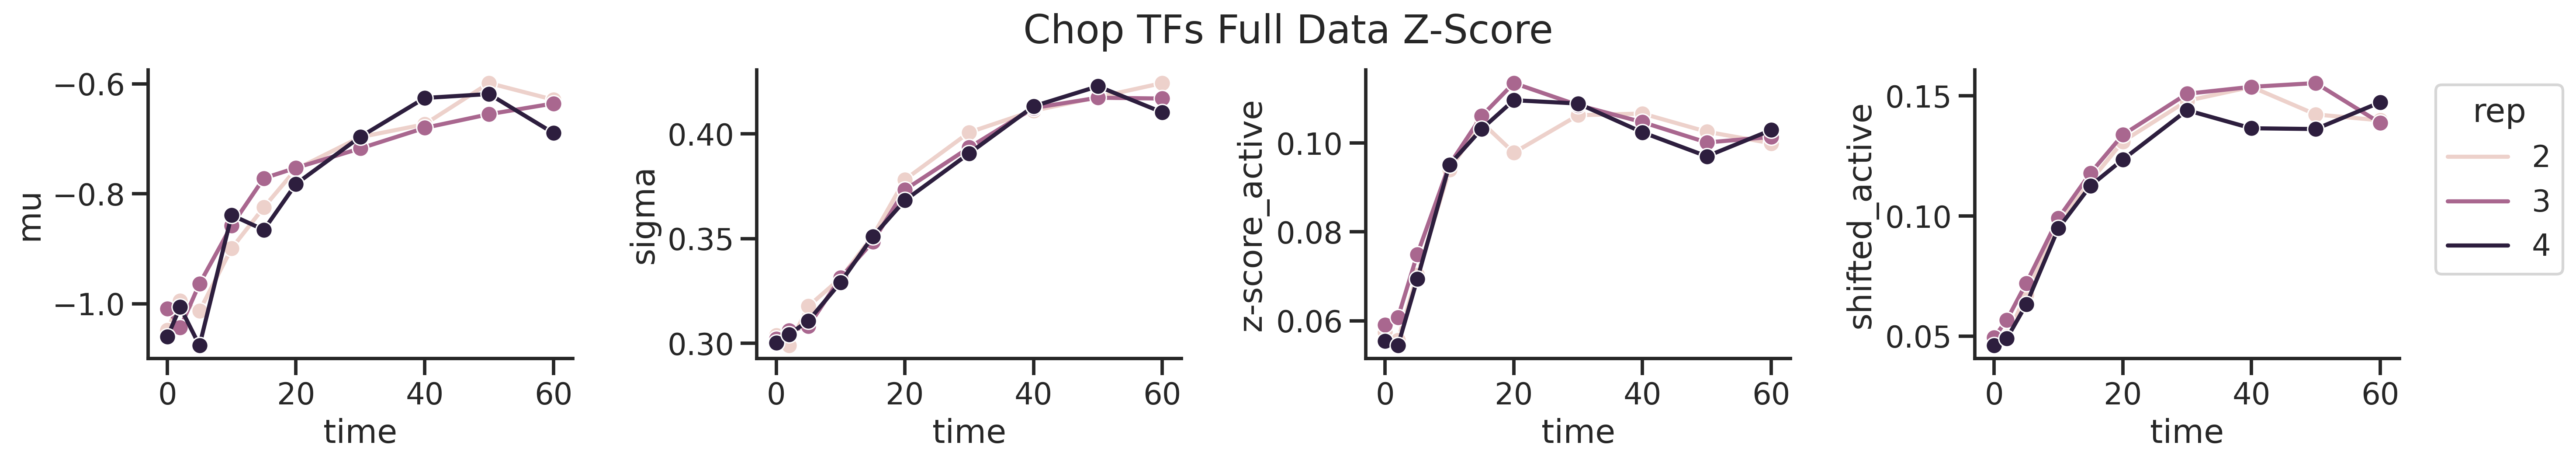

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(20,4), sharex=True, dpi = 300)

# Plot both
sns.lineplot(data=summary, x="time", y="mu", hue="rep", marker="o", ax=axes[0])
sns.lineplot(data=summary, x="time", y="sigma", hue="rep", marker="o", ax=axes[1])
sns.lineplot(data=summary, x="time", y="z-score_active", hue="rep", marker="o", ax=axes[2])
sns.lineplot(data=summary, x="time", y="shifted_active", hue="rep", marker="o", ax=axes[3])

axes[0].legend_.remove()
axes[1].legend_.remove()
axes[2].legend_.remove()
axes[3].legend(title="rep", bbox_to_anchor=(1.05, 1), loc="upper left")

fig.suptitle("Chop TFs Full Data Z-Score", y = 0.9)

sns.despine()
plt.tight_layout()
plt.show()

In [44]:
summary.to_csv("../../../output/ChopTFs_pipeline/time_normalization/full_data_time_normalized_fit_summaries.csv")

# what do controls look like?

In [45]:
! pip install biopython

Defaulting to user installation because normal site-packages is not writeable


In [46]:
from Bio.Seq import Seq

def translate_dna(seq):
    try:
        return str(Seq(seq).translate(to_stop=True))
    except:
        return None

In [47]:
design_file = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Marissa/DesignFiles/ChopTFDesign.csv")
controls = design_file.iloc[-53:]

controls["ADseq"] = controls["ArrayDNA"].apply(translate_dna)
controls

,ArrayDNA,ADseq
18790,AATACTGATTCTACTCATATGTTTGAATATTGGGCTTTGGAAGATA...,NTDSTHMFEYWALEDNSKEWTSLFDNDIWVTTDDVSLADK
18791,TCTACTATTCCATTGGACTTTATGCCAAGAGATGCTTTGCATGGAT...,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF
18792,TCTACTATTCCATTGGATGCTATGCCAAGAGATGCTTTGCATGGTG...,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA
18793,TCTACTATTCCAGCTGACTTTATGCCAAGAGATGCTGCTCATGGAT...,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF
18794,TCTACTGATTCTACTCCAATGTTTGAATATGAGAATTTGGAAGATA...,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK
18795,TCTACTGATTCTACTCCAATGTTTGAATATGAGAATTTGGAAGATA...,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK
18796,TCTACTGATTCTACTCCAGCTGCTGAAGCTGAGAATGCTGAAGATA...,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK
18797,TCTACTGATTCTACTCCAGCTGCTGAAGCTGAGAATGCTGAAGATA...,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK
18798,CCATCTCCATCTTCTTCTGTTGATAATTTGAATGATTATTTGACTG...,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI
18799,GATGATGCTGTTGTTGAATCATTCTTCTCTTCTTCTACTGATTCTA...,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP


In [48]:
gcn4_design = pd.read_csv("../../../data/Gcn4Array_Design.csv")
#gcn4_design_vars = gcn4_design[(gcn4_design["Name"].str.contains("GCN4alt"))].drop_duplicates(subset = "ADseq")
gcn4_design

,Unnamed: 0,ADseq,Name,ArrayDNA
0,0,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQA,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_1,ATGGCTTTGAGAATTGAAGTTTATAATAGAATTGAATCTTCTACTG...
1,1,EVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQ,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_6,GAAGTTTATAATAGAATTGAATCTTCTACTGCTTCTACTGCTTTGC...
2,2,IESSTASTALQRQDLRYTFRSNARAASGQANANYQAFTAG,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_11,ATTGAATCTTCTACTGCTTCTACTGCTTTGCAAAGACAAGATTTGA...
3,3,ASTALQRQDLRYTFRSNARAASGQANANYQAFTAGSALNG,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_16,GCTTCTACTGCTTTGCAAAGACAAGATTTGAGATATACATTTAGAT...
4,4,QRQDLRYTFRSNARAASGQANANYQAFTAGSALNGPSLPA,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_21,CAAAGACAAGATTTGAGATATACATTTAGATCTAATGCTAGAGCTG...
...,...,...,...,...
20778,47,AKVDTEEEDKTMVDSTSLSWEDLFDFESYSTDLIASINPD,Gnc4Lib_Kappa_HIGH_0,GCTAAAGTTGATACTGAAGAAGAAGATAAGACTATGGTTGATTCTA...
20779,48,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,Gnc4Lib_Disorder_HIGH_0,TCTACTGATTATACTCCAATGTTTGAATATGAAACTTATGAAGATA...
20780,49,MTDSTPMFEYELTENNSKEWTSLFDTDIPVTTDDESLADK,Gnc4Lib_Disorder_HIGH_0,ATGACTGATTCTACTCCAATGTTTGAATATGAATTGACTGAGAATA...
20781,50,STDSTPMFEYQNLENNSKEWTSLFDNDIPVTTDNVSLADK,Gnc4Lib_Charge_HIGH_0,TCTACTGATTCTACTCCAATGTTTGAATATCAGAATTTGGAGAATA...


In [49]:
chopTF_controls = pd.merge(controls[["ADseq"]], gcn4_design[["ADseq", "Name"]]).drop_duplicates()
chopTF_controls

,ADseq,Name
0,NTDSTHMFEYWALEDNSKEWTSLFDNDIWVTTDDVSLADK,Gnc4Lib_Disorder_HIGH_0
4,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,GAL4_AD1_0
6,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,GAL4_AD1_Aro2A_0
8,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,GAL4_AD1_L2A_0
10,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,Saccharomycotina_sp|P03069|GCN4_YEAST_101
11,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_0
13,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_WLF_A_0
15,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_MFYL_A_0
17,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_7As_0
19,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0


In [50]:
chopTF_controls["GCN4_CAAD"] = chopTF_controls["Name"].str.contains("CAAD")
chopTF_controls["GCN4_altCAAD"] = chopTF_controls["Name"].str.contains("GCN4alt")
chopTF_controls["Gal4"] = chopTF_controls["Name"].str.upper().str.contains("GAL4")
chopTF_controls["Rap1"] = chopTF_controls["Name"].str.contains("Rap1")
chopTF_controls["War1"] = chopTF_controls["Name"].str.contains("War1")
chopTF_controls["VP16N"] = chopTF_controls["Name"].str.upper().str.contains("VP16N")
chopTF_controls["VP16C"] = (
    chopTF_controls["Name"].str.upper().str.contains("VP16C") |
    chopTF_controls["Name"].str.upper().str.contains("HUMANLIB")
)
chopTF_controls["CITED2"] = chopTF_controls["Name"].str.contains("CITED2")
chopTF_controls["Gcn4Lib_Disorder"] = chopTF_controls["Name"].str.contains("Gnc4Lib_Disorder")
chopTF_controls["Gcn4Lib_Charge"] = chopTF_controls["Name"].str.contains("Gnc4Lib_Charge")
chopTF_controls["Gcn4Lib_Kappa"] = chopTF_controls["Name"].str.contains("Gnc4Lib_Kappa")
chopTF_controls["Gcn4Lib_Chop"] = chopTF_controls["Name"].str.contains("Gnc4Lib_Chop")
chopTF_controls["Gcn4Lib_other"] = (chopTF_controls["Name"] == "Gnc4Lib_HoldChargeDisorder_LOW_0") | (chopTF_controls["Name"] == "Gnc4Lib_MovePrimaryMotif_LOW_0")
# Select the Boolean columns (all except 'ADseq' and 'Name')
bool_cols = chopTF_controls.columns.difference(['ADseq', 'Name'])
chopTF_controls["yeast_orthologs"] = ~chopTF_controls[bool_cols].any(axis=1)
chopTF_controls = chopTF_controls.rename(columns = {"Gnc4Lib" : "Gcn4Lib"})
chopTF_controls

,ADseq,Name,GCN4_CAAD,GCN4_altCAAD,Gal4,Rap1,War1,VP16N,VP16C,CITED2,Gcn4Lib_Disorder,Gcn4Lib_Charge,Gcn4Lib_Kappa,Gcn4Lib_Chop,Gcn4Lib_other,yeast_orthologs
0,NTDSTHMFEYWALEDNSKEWTSLFDNDIWVTTDDVSLADK,Gnc4Lib_Disorder_HIGH_0,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,GAL4_AD1_0,False,False,True,False,False,False,False,False,False,False,False,False,False,False
6,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,GAL4_AD1_Aro2A_0,False,False,True,False,False,False,False,False,False,False,False,False,False,False
8,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,GAL4_AD1_L2A_0,False,False,True,False,False,False,False,False,False,False,False,False,False,False
10,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,Saccharomycotina_sp|P03069|GCN4_YEAST_101,False,False,False,False,False,False,False,False,False,False,False,False,False,True
11,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_0,True,False,False,False,False,False,False,False,False,False,False,False,False,False
13,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_WLF_A_0,True,False,False,False,False,False,False,False,False,False,False,False,False,False
15,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_MFYL_A_0,True,False,False,False,False,False,False,False,False,False,False,False,False,False
17,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_7As_0,True,False,False,False,False,False,False,False,False,False,False,False,False,False
19,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [51]:
chopTF_controls[chopTF_controls["yeast_orthologs"]]

,ADseq,Name,GCN4_CAAD,GCN4_altCAAD,Gal4,Rap1,War1,VP16N,VP16C,CITED2,Gcn4Lib_Disorder,Gcn4Lib_Charge,Gcn4Lib_Kappa,Gcn4Lib_Chop,Gcn4Lib_other,yeast_orthologs
10,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,Saccharomycotina_sp|P03069|GCN4_YEAST_101,False,False,False,False,False,False,False,False,False,False,False,False,False,True
75,DVTPASPMIRTTSSRATSPSARSVTKPSHVAGVNARQRKP,Afla_EED46972.1_AspergillusFlavusNRRL3357_111,False,False,False,False,False,False,False,False,False,False,False,False,False,True
96,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,Sordariomycetes_jgi|Neucr4830_1|444994|fgenesh...,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [52]:
tf_cols = chopTF_controls.columns.difference(['ADseq', 'Name'])

# Function to assign group
def assign_group(row):
    for col in tf_cols:
        if row[col]:  # check the boolean column directly
            return col
    return "yeast_orthologs"

# Apply row-wise
chopTF_controls["group"] = chopTF_controls.apply(assign_group, axis=1)

# Keep only relevant columns
chopTF_controls_grouped = chopTF_controls[["ADseq", "Name", "group"]]
chopTF_controls_grouped

,ADseq,Name,group
0,NTDSTHMFEYWALEDNSKEWTSLFDNDIWVTTDDVSLADK,Gnc4Lib_Disorder_HIGH_0,Gcn4Lib_Disorder
4,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,GAL4_AD1_0,Gal4
6,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,GAL4_AD1_Aro2A_0,Gal4
8,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,GAL4_AD1_L2A_0,Gal4
10,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,Saccharomycotina_sp|P03069|GCN4_YEAST_101,yeast_orthologs
11,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_0,GCN4_CAAD
13,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_WLF_A_0,GCN4_CAAD
15,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_MFYL_A_0,GCN4_CAAD
17,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_7As_0,GCN4_CAAD
19,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,War1


In [53]:
chopTF_controls_grouped = chopTF_controls_grouped.sort_values(by = ['group', 'Name'])
chopTF_controls_grouped

,ADseq,Name,group
59,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2
65,TDAIDEEVLMSLVIEMGLDRIKELPELALGQNEADAMTDA,CITED2_ARO2A_0,CITED2
63,TDFIDEEVAMSAVIEMGADRIKEAPEAWAGQNEFDFMTDF,CITED2_L2A_0,CITED2
61,TDFIDEEVIMSIVIEMGIDRIKEIPEIWIGQNEFDFMTDF,CITED2_L2I_0,CITED2
67,TDAIDEEVAMSAVIEMGADRIKEAPEAAAGQNEADAMTDA,CITED2_LWF2A_0,CITED2
11,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_0,GCN4_CAAD
17,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_7As_0,GCN4_CAAD
15,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_MFYL_A_0,GCN4_CAAD
13,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_WLF_A_0,GCN4_CAAD
21,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,GCN4alt_0,GCN4_altCAAD


In [54]:
chopTF_controls_grouped.to_csv("../../../data/chopTFs_controls.csv")

In [55]:
chopTF_controls_grouped["group"].value_counts()

group
GCN4_altCAAD        7
Gcn4Lib_Charge      6
CITED2              5
VP16C               5
Gcn4Lib_Kappa       5
Gcn4Lib_Disorder    5
GCN4_CAAD           4
VP16N               4
yeast_orthologs     3
Gal4                3
Rap1                3
Gcn4Lib_Chop        2
Gcn4Lib_other       2
War1                1
Name: count, dtype: int64

In [56]:
all_activities = pd.read_csv("../../../output/ChopTFs_pipeline/full_data_time_normalized_activities.csv", index_col = 0)
all_activities = all_activities.rename(columns = {"seq" : "ADseq"})
all_activities

FileNotFoundError: [Errno 2] No such file or directory: '../../../output/ChopTFs_pipeline/full_data_time_normalized_activities.csv'

In [ ]:
seq_list = chopTF_controls[chopTF_controls["group"] == "GCN4_altCAAD"]
seq_list

In [ ]:
control_activities = pd.merge(all_activities, chopTF_controls[["ADseq", "Name", "group"]], on = "ADseq")
control_activities

In [ ]:
control_activities_grouped = control_activities.groupby(["ADseq", "rep", "time", "Name", "group"])[["z-scored_activity", "shifted_activity"]].agg(["mean", "std"]).reset_index()
control_activities_grouped.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in control_activities_grouped.columns]
control_activities_grouped

In [ ]:
one_group_activities = control_activities_grouped[control_activities_grouped["group_"] == "CITED2"]
one_group_activities

In [ ]:
time_normalization_helpers.plot_all_control_groups(all_activities)